# 📊 Análise End-to-End: Predição de Risco de Defasagem Escolar

**Projeto:** Datathon FIAP — Associação Passos Mágicos  
**Objetivo:** Pipeline completo desde a análise exploratória do dataset até o treinamento, avaliação e análise gráfica extensiva de performance dos modelos.

---

## Índice

1. [Setup e Imports](#1-setup)
2. [Carregamento e Visão Geral do Dataset](#2-dados)
3. [Análise Exploratória (EDA)](#3-eda)
4. [Análise de Correlações e Relações](#4-correlacoes)
5. [Pré-processamento e Feature Engineering](#5-preprocessing)
6. [Treinamento de Modelos](#6-treinamento)
7. [Métricas e Avaliação](#7-metricas)
8. [Análise Gráfica de Performance](#8-graficos)
9. [Análise de Feature Importance](#9-features)
10. [Análise de Erros e Calibração](#10-erros)
11. [Conclusões e Recomendações](#11-conclusao)

---

| Versão | Data | Descrição |
|--------|------|-----------|
| v1.0 | Fev/2026 | Notebook end-to-end completo |

## 1. Setup e Imports <a id="1-setup"></a>

In [1]:
import warnings
warnings.filterwarnings('ignore')

# Bibliotecas básicas
import json
import sys
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

# Sklearn - Preprocessing
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    cross_validate,
    learning_curve
)
from sklearn.preprocessing import (
    StandardScaler,
    RobustScaler,
    LabelEncoder,
    label_binarize
)
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Sklearn - Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    AdaBoostClassifier,
    VotingClassifier,
    StackingClassifier
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier

# Sklearn - Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    roc_curve,
    brier_score_loss,
    det_curve,
    log_loss
)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.inspection import permutation_importance

# Boosting libraries
try:
    import xgboost as xgb
    HAS_XGBOOST = True
    print("✅ XGBoost disponível")
except ImportError:
    HAS_XGBOOST = False
    print("⚠️ XGBoost não instalado")

try:
    import lightgbm as lgb
    HAS_LIGHTGBM = True
    print("✅ LightGBM disponível")
except ImportError:
    HAS_LIGHTGBM = False
    print("⚠️ LightGBM não instalado")

try:
    from catboost import CatBoostClassifier
    HAS_CATBOOST = True
    print("✅ CatBoost disponível")
except ImportError:
    HAS_CATBOOST = False
    print("⚠️ CatBoost não instalado")

try:
    import optuna
    from optuna.samplers import TPESampler
    HAS_OPTUNA = True
    print("✅ Optuna disponível")
except ImportError:
    HAS_OPTUNA = False
    print("⚠️ Optuna não instalado")

try:
    from imblearn.over_sampling import SMOTE, BorderlineSMOTE
    from imblearn.combine import SMOTETomek
    HAS_IMBLEARN = True
    print("✅ Imbalanced-learn disponível")
except ImportError:
    HAS_IMBLEARN = False
    print("⚠️ Imbalanced-learn não instalado")

try:
    import shap
    HAS_SHAP = True
    print("✅ SHAP disponível")
except ImportError:
    HAS_SHAP = False
    print("⚠️ SHAP não instalado")

# Configurações
SEED = 42
np.random.seed(SEED)

# Paths
PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "processed"
ARTIFACTS_PATH = PROJECT_ROOT / "artifacts"
sys.path.insert(0, str(PROJECT_ROOT))

# Cores do projeto
COLORS = {
    'primary': '#2C3E50',
    'secondary': '#3498DB',
    'success': '#2ECC71',
    'danger': '#E74C3C',
    'warning': '#F39C12',
    'info': '#1ABC9C',
    'purple': '#9B59B6',
    'orange': '#E67E22',
}
PALETTE = list(COLORS.values())

# Plot style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.dpi': 100,
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
})

print(f"\n📁 Project root: {PROJECT_ROOT}")
print(f"📁 Data path: {DATA_PATH}")
print("✅ Setup concluído!")

✅ XGBoost disponível
✅ LightGBM disponível
✅ CatBoost disponível
✅ Optuna disponível
✅ Imbalanced-learn disponível
✅ SHAP disponível

📁 Project root: c:\Users\argus\workspace\datathonfiap
📁 Data path: c:\Users\argus\workspace\datathonfiap\data\processed
✅ Setup concluído!


## 2. Carregamento e Visão Geral do Dataset <a id="2-dados"></a>

In [2]:
# Carregar dataset de modelagem
dataset_path = DATA_PATH / "modeling_dataset.parquet"

if dataset_path.exists():
    df = pd.read_parquet(dataset_path)
    print(f"✅ Dataset carregado: {df.shape[0]} linhas × {df.shape[1]} colunas")
else:
    csv_path = DATA_PATH / "modeling_dataset.csv"
    if csv_path.exists():
        df = pd.read_csv(csv_path)
        print(f"✅ Dataset carregado (CSV): {df.shape}")
    else:
        raise FileNotFoundError(f"Dataset não encontrado em {DATA_PATH}")

# Identificar target e features
TARGET_COL = [c for c in df.columns if c.startswith('em_risco')][0]
ID_COLS = ['ra'] if 'ra' in df.columns else []

print(f"\n🎯 Target: {TARGET_COL}")
print(f"🔑 ID columns: {ID_COLS}")
print(f"📊 Total de colunas: {df.shape[1]}")

✅ Dataset carregado: 765 linhas × 21 colunas

🎯 Target: em_risco_2024
🔑 ID columns: ['ra']
📊 Total de colunas: 21


In [3]:
# Visão geral do dataset
print("=" * 70)
print("📋 VISÃO GERAL DO DATASET")
print("=" * 70)

print(f"\n📐 Shape: {df.shape}")
print(f"📊 Memória: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\n📊 Tipos de dados:")
print(df.dtypes.value_counts())

print("\n📊 Primeiras linhas:")
display(df.head())

print("\n📊 Estatísticas descritivas:")
display(df.describe().round(3))

📋 VISÃO GERAL DO DATASET

📐 Shape: (765, 21)
📊 Memória: 0.26 MB

📊 Tipos de dados:
float64    13
object      4
int64       4
Name: count, dtype: int64

📊 Primeiras linhas:


,ra,instituicao_2023,idade_2023,genero_2023,fase_2023,ano_ingresso_2023,ian_2023,ida_2023,ieg_2023,iaa_2023,...,ipp_2023,ipv_2023,em_risco_2024,delta_ian_2022_2023,delta_ida_2022_2023,delta_ieg_2022_2023,delta_iaa_2022_2023,delta_ips_2022_2023,delta_ipv_2022_2023,has_prev_year_data
0,RA-861,Publica,8,Feminino,ALFA,2023,10.0,9.6,10.0,9.5,...,8.4375,8.920,1,NaN,NaN,NaN,NaN,NaN,NaN,0
1,RA-862,Publica,9,Masculino,ALFA,2023,5.0,8.9,9.1,8.5,...,7.5000,8.585,1,NaN,NaN,NaN,NaN,NaN,NaN,0
2,RA-863,Publica,7,Masculino,ALFA,2023,10.0,6.3,7.6,0.0,...,5.9375,6.260,1,NaN,NaN,NaN,NaN,NaN,NaN,0
3,RA-867,Publica,8,Masculino,ALFA,2023,10.0,8.9,8.6,9.0,...,7.5000,8.415,1,NaN,NaN,NaN,NaN,NaN,NaN,0
4,RA-868,Publica,7,Masculino,ALFA,2023,10.0,7.1,9.5,10.0,...,7.1875,8.670,1,NaN,NaN,NaN,NaN,NaN,NaN,0



📊 Estatísticas descritivas:


,idade_2023,ano_ingresso_2023,ian_2023,ida_2023,ieg_2023,iaa_2023,ips_2023,ipp_2023,ipv_2023,em_risco_2024,delta_ian_2022_2023,delta_ida_2022_2023,delta_ieg_2022_2023,delta_iaa_2022_2023,delta_ips_2022_2023,delta_ipv_2022_2023,has_prev_year_data
count,765.000,765.000,765.000,693.000,693.000,706.000,703.000,693.000,693.000,765.000,468.000,444.000,444.000,451.000,450.000,444.000,765.000
mean,12.285,2021.290,7.405,6.826,8.865,6.995,5.156,7.615,8.116,0.403,0.486,0.080,0.216,-1.776,-1.922,0.546,0.612
std,3.369,1.889,2.519,1.482,0.970,3.567,2.091,0.981,0.919,0.491,2.697,1.562,0.989,3.837,2.039,0.926,0.488
min,7.000,2016.000,2.500,2.200,3.700,0.000,2.520,4.375,3.320,0.000,-5.000,-5.700,-2.800,-10.000,-6.880,-2.077,0.000
25%,10.000,2021.000,5.000,5.900,8.300,6.925,2.520,7.188,7.542,0.000,0.000,-0.900,-0.300,-2.100,-3.730,-0.131,0.000
50%,12.000,2022.000,5.000,6.900,9.100,8.500,5.000,7.708,8.117,0.000,0.000,-0.100,0.200,-0.500,-1.870,0.542,1.000
75%,14.000,2023.000,10.000,7.900,9.600,9.200,7.520,8.281,8.712,1.000,0.000,1.000,0.725,0.500,0.020,1.172,1.000
max,26.000,2023.000,10.000,10.000,10.000,10.000,9.380,9.792,10.010,1.000,7.500,5.300,4.700,9.600,3.120,2.782,1.000


🔍 ANÁLISE DE MISSING VALUES

⚠️ 12 colunas com missing values:


,Missing,Percent (%),Dtype
delta_ida_2022_2023,321,41.96,float64
delta_ipv_2022_2023,321,41.96,float64
delta_ieg_2022_2023,321,41.96,float64
delta_ips_2022_2023,315,41.18,float64
delta_iaa_2022_2023,314,41.05,float64
delta_ian_2022_2023,297,38.82,float64
ipv_2023,72,9.41,float64
ieg_2023,72,9.41,float64
ida_2023,72,9.41,float64
ipp_2023,72,9.41,float64


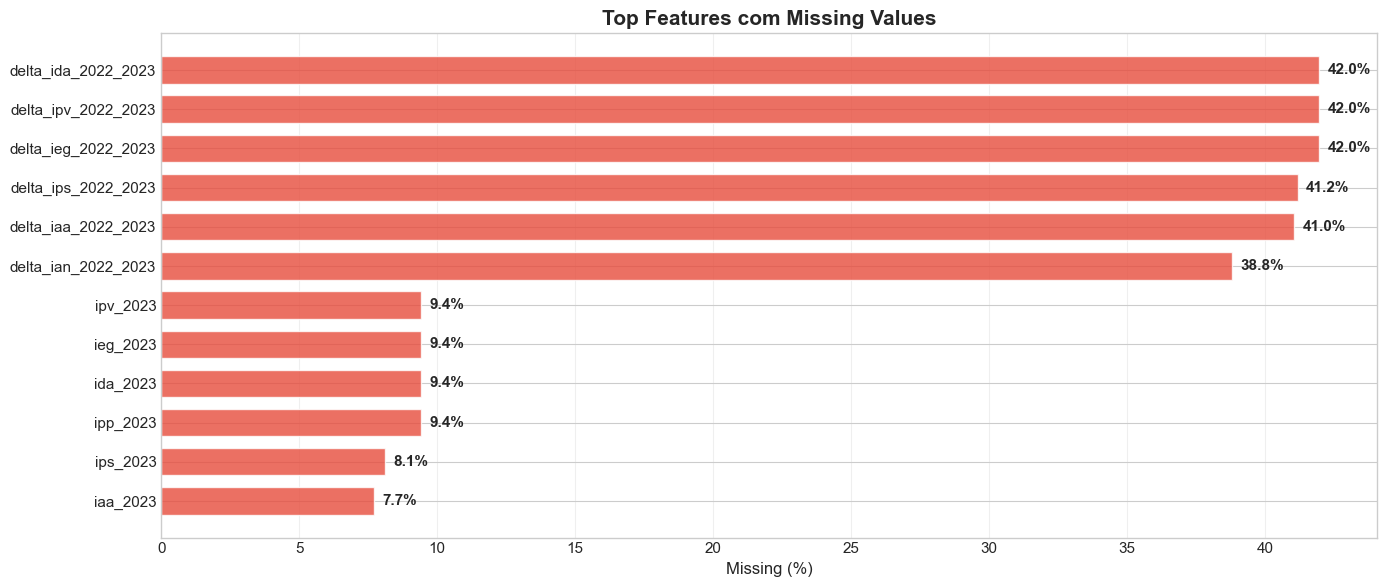

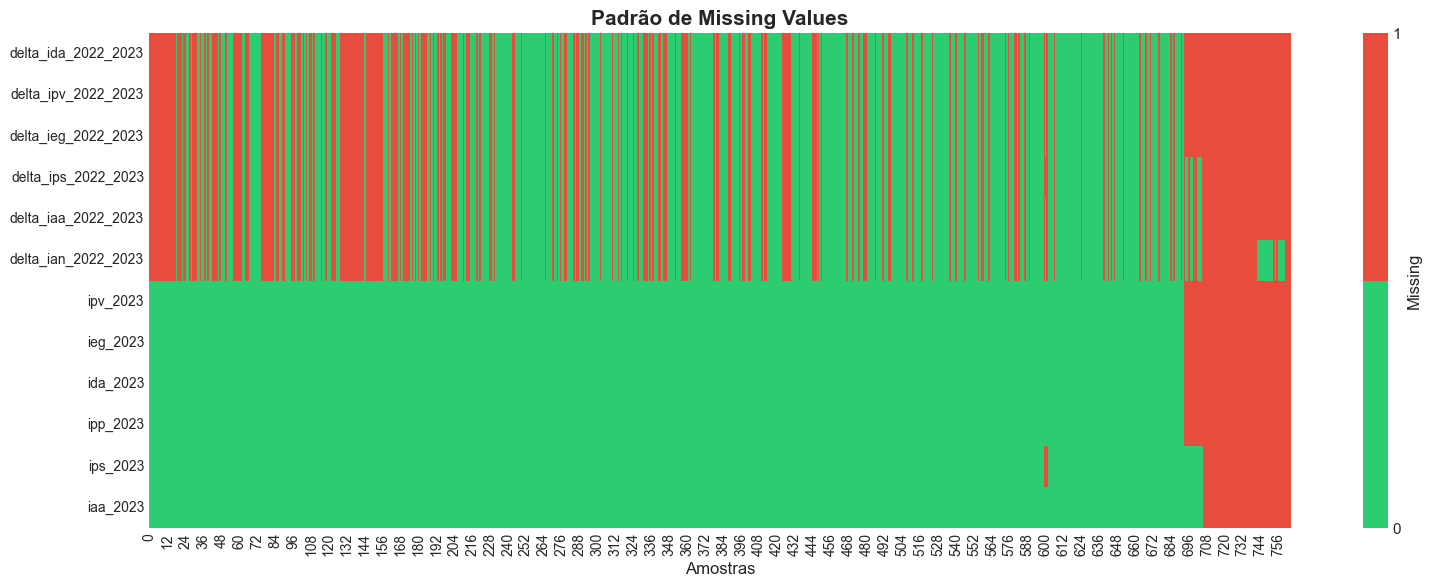

In [4]:
# Análise de missing values
print("=" * 70)
print("🔍 ANÁLISE DE MISSING VALUES")
print("=" * 70)

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing': missing,
    'Percent (%)': missing_pct,
    'Dtype': df.dtypes
}).sort_values('Missing', ascending=False)

missing_with_values = missing_df[missing_df['Missing'] > 0]

if len(missing_with_values) > 0:
    print(f"\n⚠️ {len(missing_with_values)} colunas com missing values:")
    display(missing_with_values)
    
    # Gráfico 1: Barplot de missing values
    top_missing = missing_with_values.head(15)
    fig, ax = plt.subplots(figsize=(14, max(6, len(top_missing) * 0.5)))
    bars = ax.barh(range(len(top_missing)), top_missing['Percent (%)'], 
                    color=COLORS['danger'], alpha=0.8, edgecolor='white', height=0.7)
    ax.set_yticks(range(len(top_missing)))
    ax.set_yticklabels(top_missing.index, fontsize=11)
    ax.set_xlabel('Missing (%)', fontsize=12)
    ax.set_title('Top Features com Missing Values', fontsize=15, fontweight='bold')
    for i, v in enumerate(top_missing['Percent (%)']):
        ax.text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=11, fontweight='bold')
    ax.invert_yaxis()
    ax.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()
    
    # Gráfico 2: Heatmap de missingness pattern
    fig, ax = plt.subplots(figsize=(16, max(6, len(top_missing) * 0.45)))
    missing_matrix = df[missing_with_values.index[:15]].isnull().astype(int)
    sns.heatmap(missing_matrix.T, cbar=True, yticklabels=True, 
                cmap=['#2ECC71', '#E74C3C'], ax=ax, 
                cbar_kws={'label': 'Missing', 'ticks': [0, 1]})
    ax.set_title('Padrão de Missing Values', fontsize=15, fontweight='bold')
    ax.set_xlabel('Amostras', fontsize=12)
    ax.tick_params(labelsize=10)
    plt.tight_layout()
    plt.show()
else:
    print("\n✅ Nenhum missing value encontrado!")

## 3. Análise Exploratória (EDA) <a id="3-eda"></a>

🎯 DISTRIBUIÇÃO DO TARGET


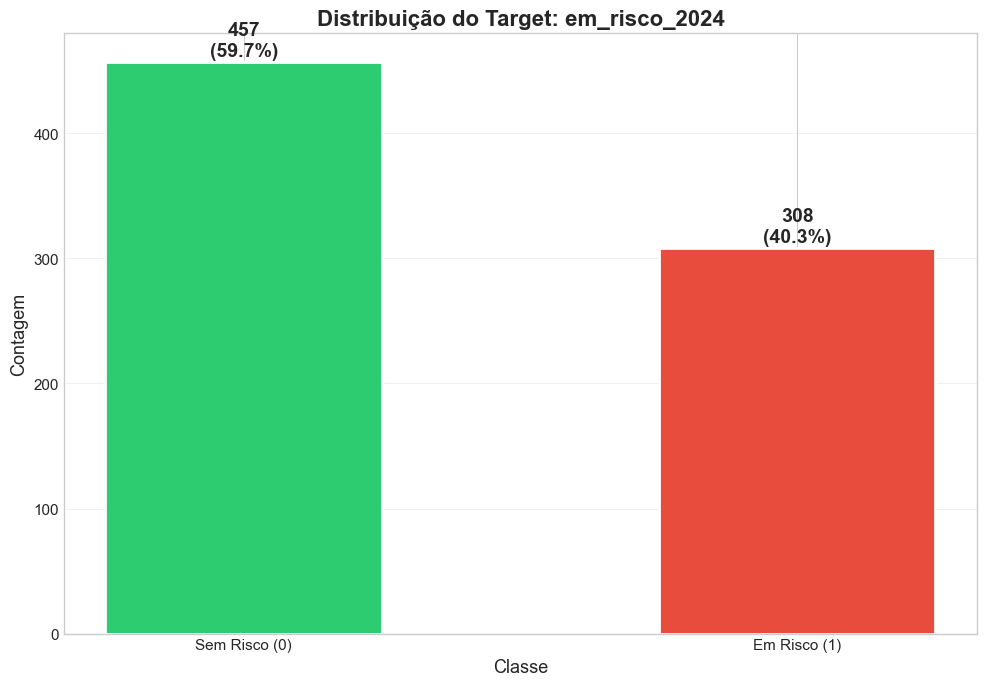

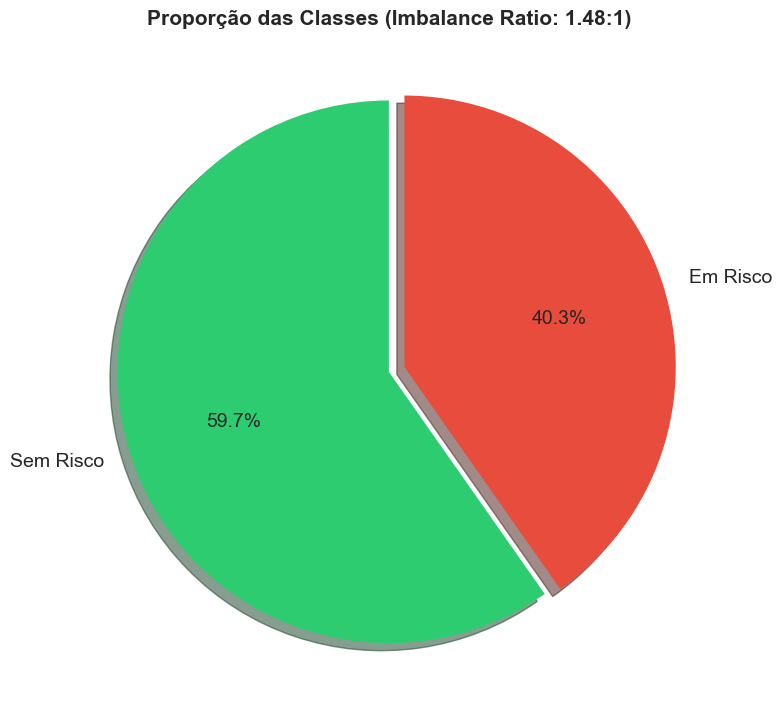


📊 Classe majoritária: 0 (59.7%)
📊 Classe minoritária: 1 (40.3%)
📊 Imbalance ratio: 1.48:1


In [5]:
# Distribuição do Target
print("=" * 70)
print("🎯 DISTRIBUIÇÃO DO TARGET")
print("=" * 70)

target_counts = df[TARGET_COL].value_counts()
target_pct = df[TARGET_COL].value_counts(normalize=True) * 100

# Gráfico: Barplot de distribuição
fig, ax = plt.subplots(figsize=(10, 7))
colors_target = [COLORS['success'], COLORS['danger']]
bars = ax.bar(target_counts.index.astype(str), target_counts.values, 
               color=colors_target, edgecolor='white', linewidth=2, width=0.5)
for bar, count, pct in zip(bars, target_counts.values, target_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
             f'{count}\n({pct:.1f}%)', ha='center', fontweight='bold', fontsize=14)
ax.set_xlabel('Classe', fontsize=13)
ax.set_ylabel('Contagem', fontsize=13)
ax.set_title(f'Distribuição do Target: {TARGET_COL}', fontsize=16, fontweight='bold')
ax.set_xticks([0, 1])
ax.set_xticklabels(['Sem Risco (0)', 'Em Risco (1)'], fontsize=12)
ax.tick_params(labelsize=11)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Gráfico: Pie chart
fig, ax = plt.subplots(figsize=(8, 8))
imbalance_ratio = target_counts.max() / target_counts.min()
ax.pie(target_counts.values, labels=['Sem Risco', 'Em Risco'], 
        colors=colors_target, autopct='%1.1f%%', startangle=90,
        explode=(0, 0.06), shadow=True, textprops={'fontsize': 14})
ax.set_title(f'Proporção das Classes (Imbalance Ratio: {imbalance_ratio:.2f}:1)', 
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n📊 Classe majoritária: {target_counts.idxmax()} ({target_pct.max():.1f}%)")
print(f"📊 Classe minoritária: {target_counts.idxmin()} ({target_pct.min():.1f}%)")
print(f"📊 Imbalance ratio: {imbalance_ratio:.2f}:1")

📊 DISTRIBUIÇÃO DAS FEATURES NUMÉRICAS (16 features)


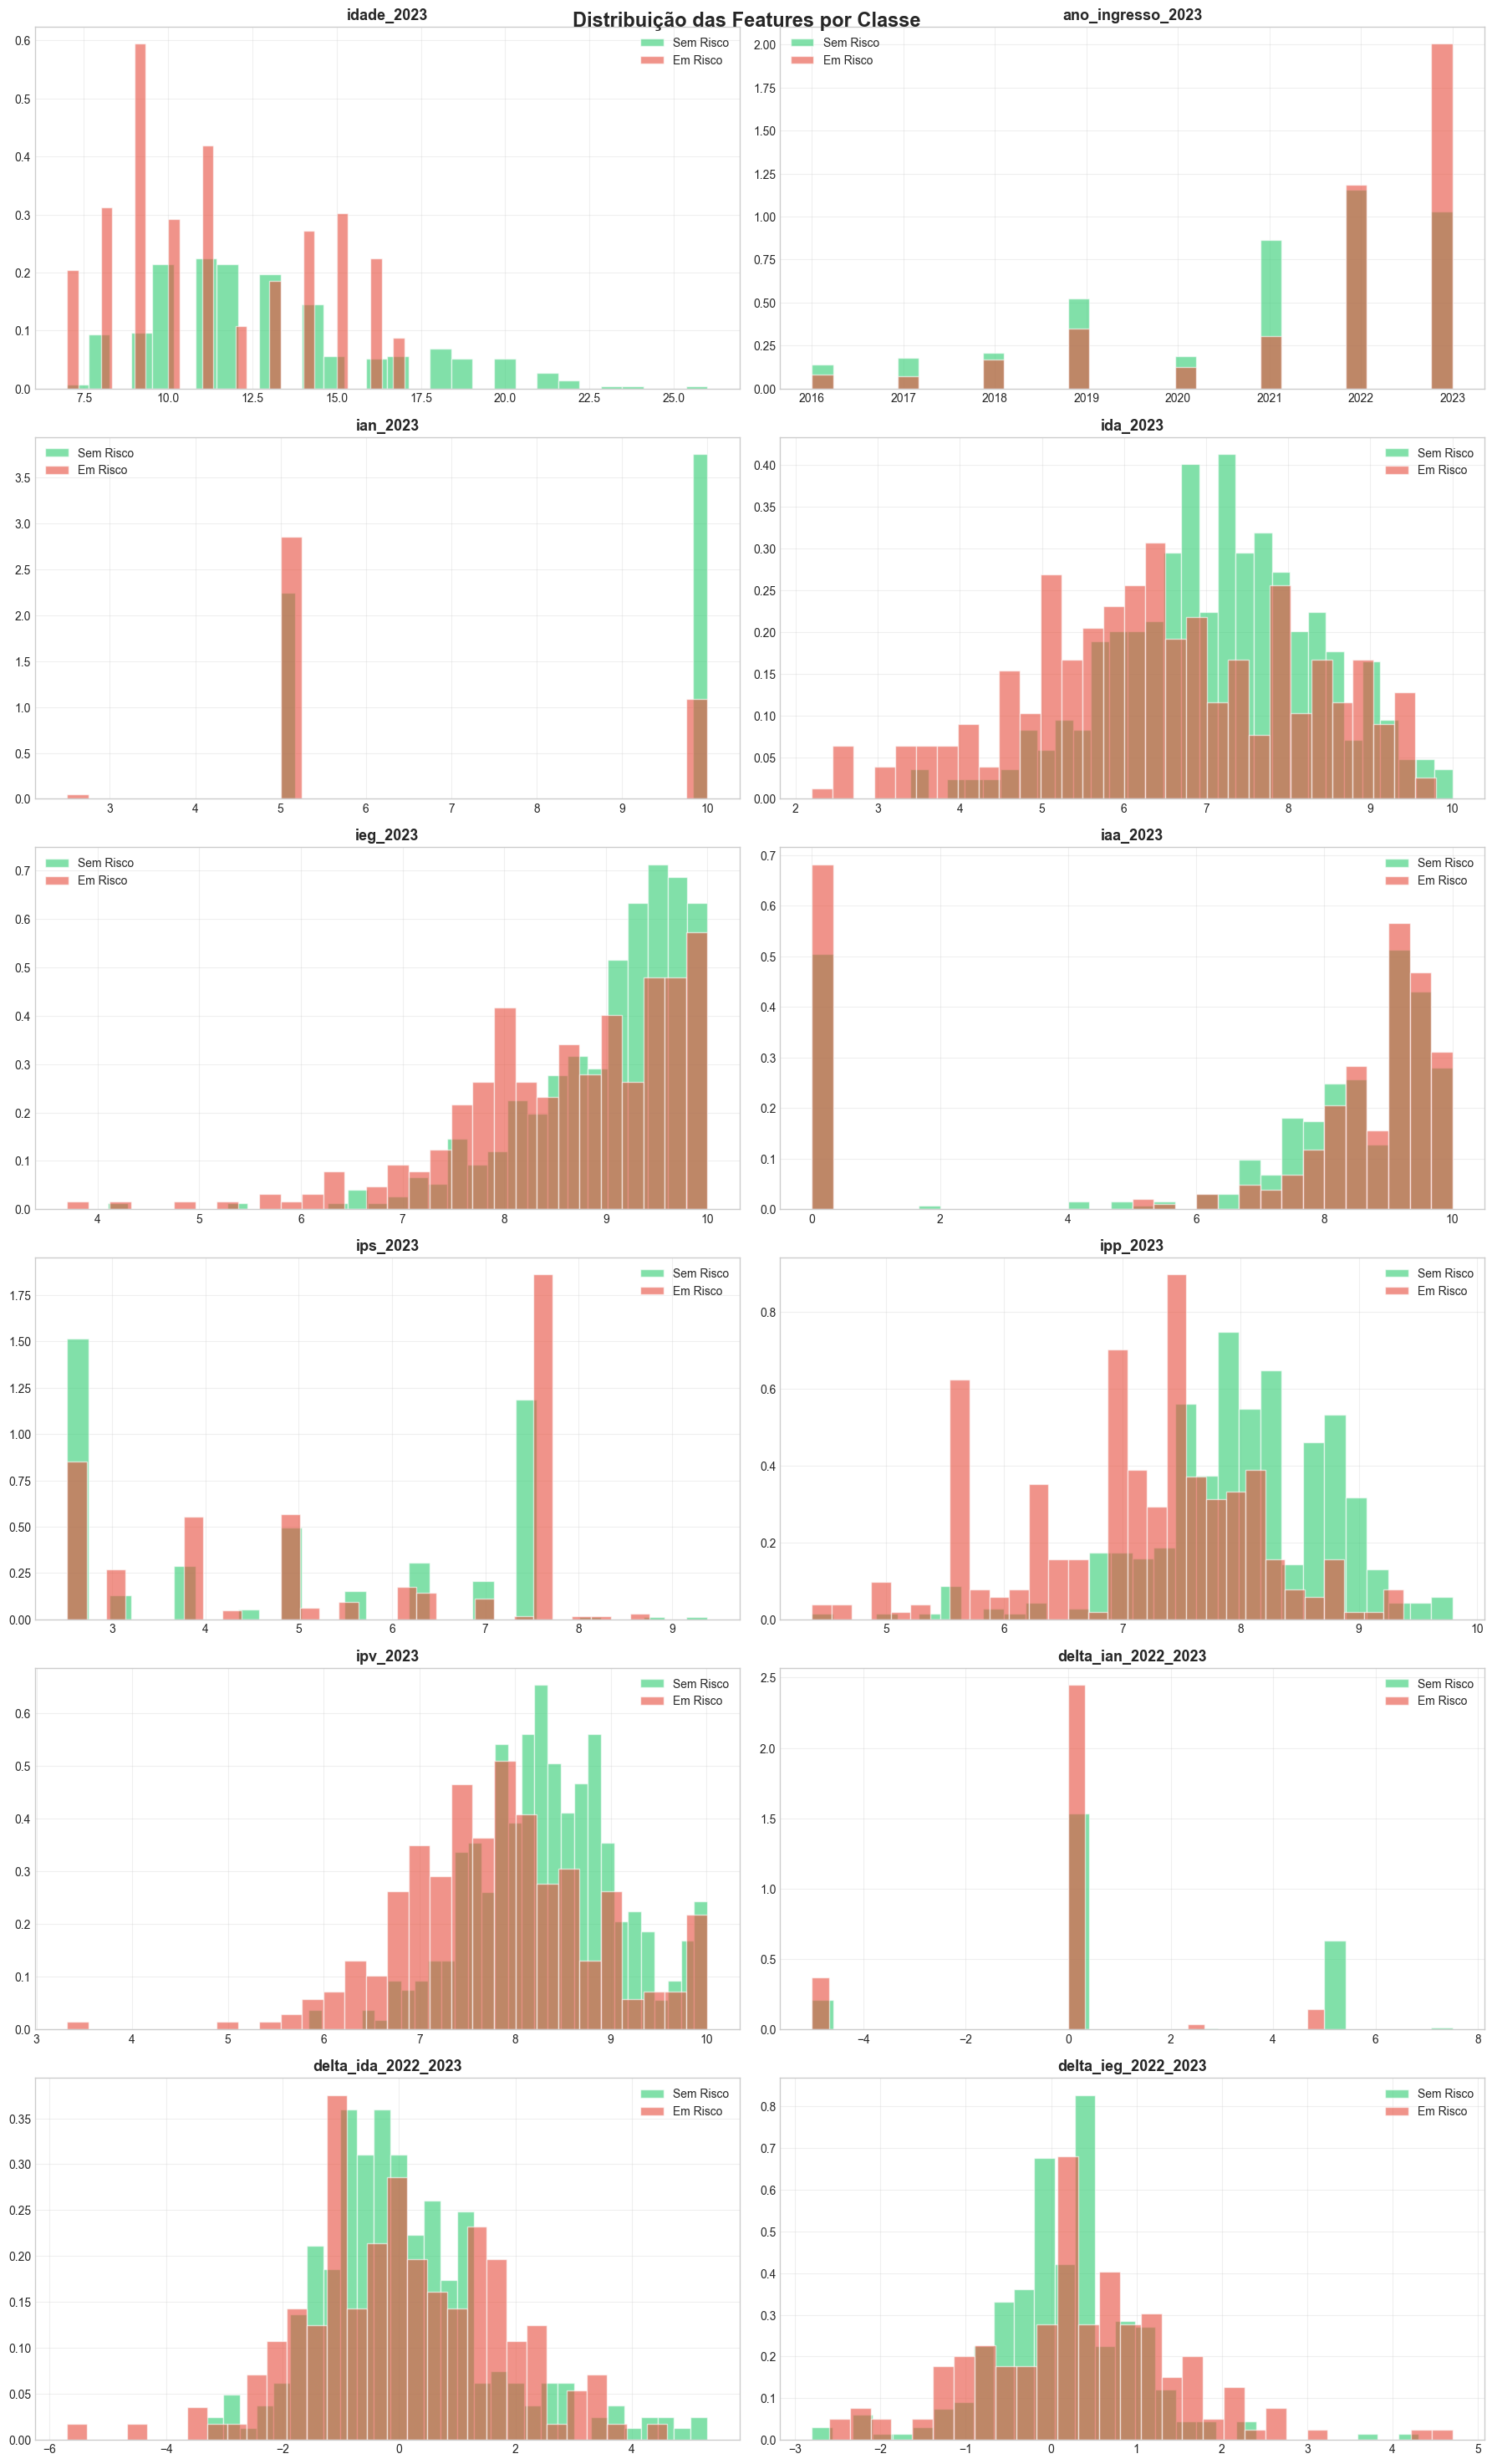

In [6]:
# Distribuição das features numéricas
FEATURE_COLS = [c for c in df.columns if c not in [TARGET_COL] + ID_COLS]
numeric_cols = df[FEATURE_COLS].select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df[FEATURE_COLS].select_dtypes(include=['object', 'category']).columns.tolist()

print("=" * 70)
print(f"📊 DISTRIBUIÇÃO DAS FEATURES NUMÉRICAS ({len(numeric_cols)} features)")
print("=" * 70)

# Plotar distribuições por classe — 2 colunas para mais espaço
n_cols_plot = min(len(numeric_cols), 12)
cols_to_plot = numeric_cols[:n_cols_plot]
n_rows = (n_cols_plot + 1) // 2

fig, axes = plt.subplots(n_rows, 2, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for idx, col in enumerate(cols_to_plot):
    ax = axes[idx]
    for cls, color, label in [(0, COLORS['success'], 'Sem Risco'), 
                               (1, COLORS['danger'], 'Em Risco')]:
        data = df[df[TARGET_COL] == cls][col].dropna()
        ax.hist(data, bins=30, alpha=0.6, color=color, label=label, density=True, edgecolor='white')
    ax.set_title(col, fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.tick_params(labelsize=10)
    ax.grid(True, alpha=0.3)

for idx in range(n_cols_plot, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Distribuição das Features por Classe', fontsize=17, fontweight='bold')
plt.tight_layout()
plt.show()

📦 BOXPLOTS DAS FEATURES POR CLASSE


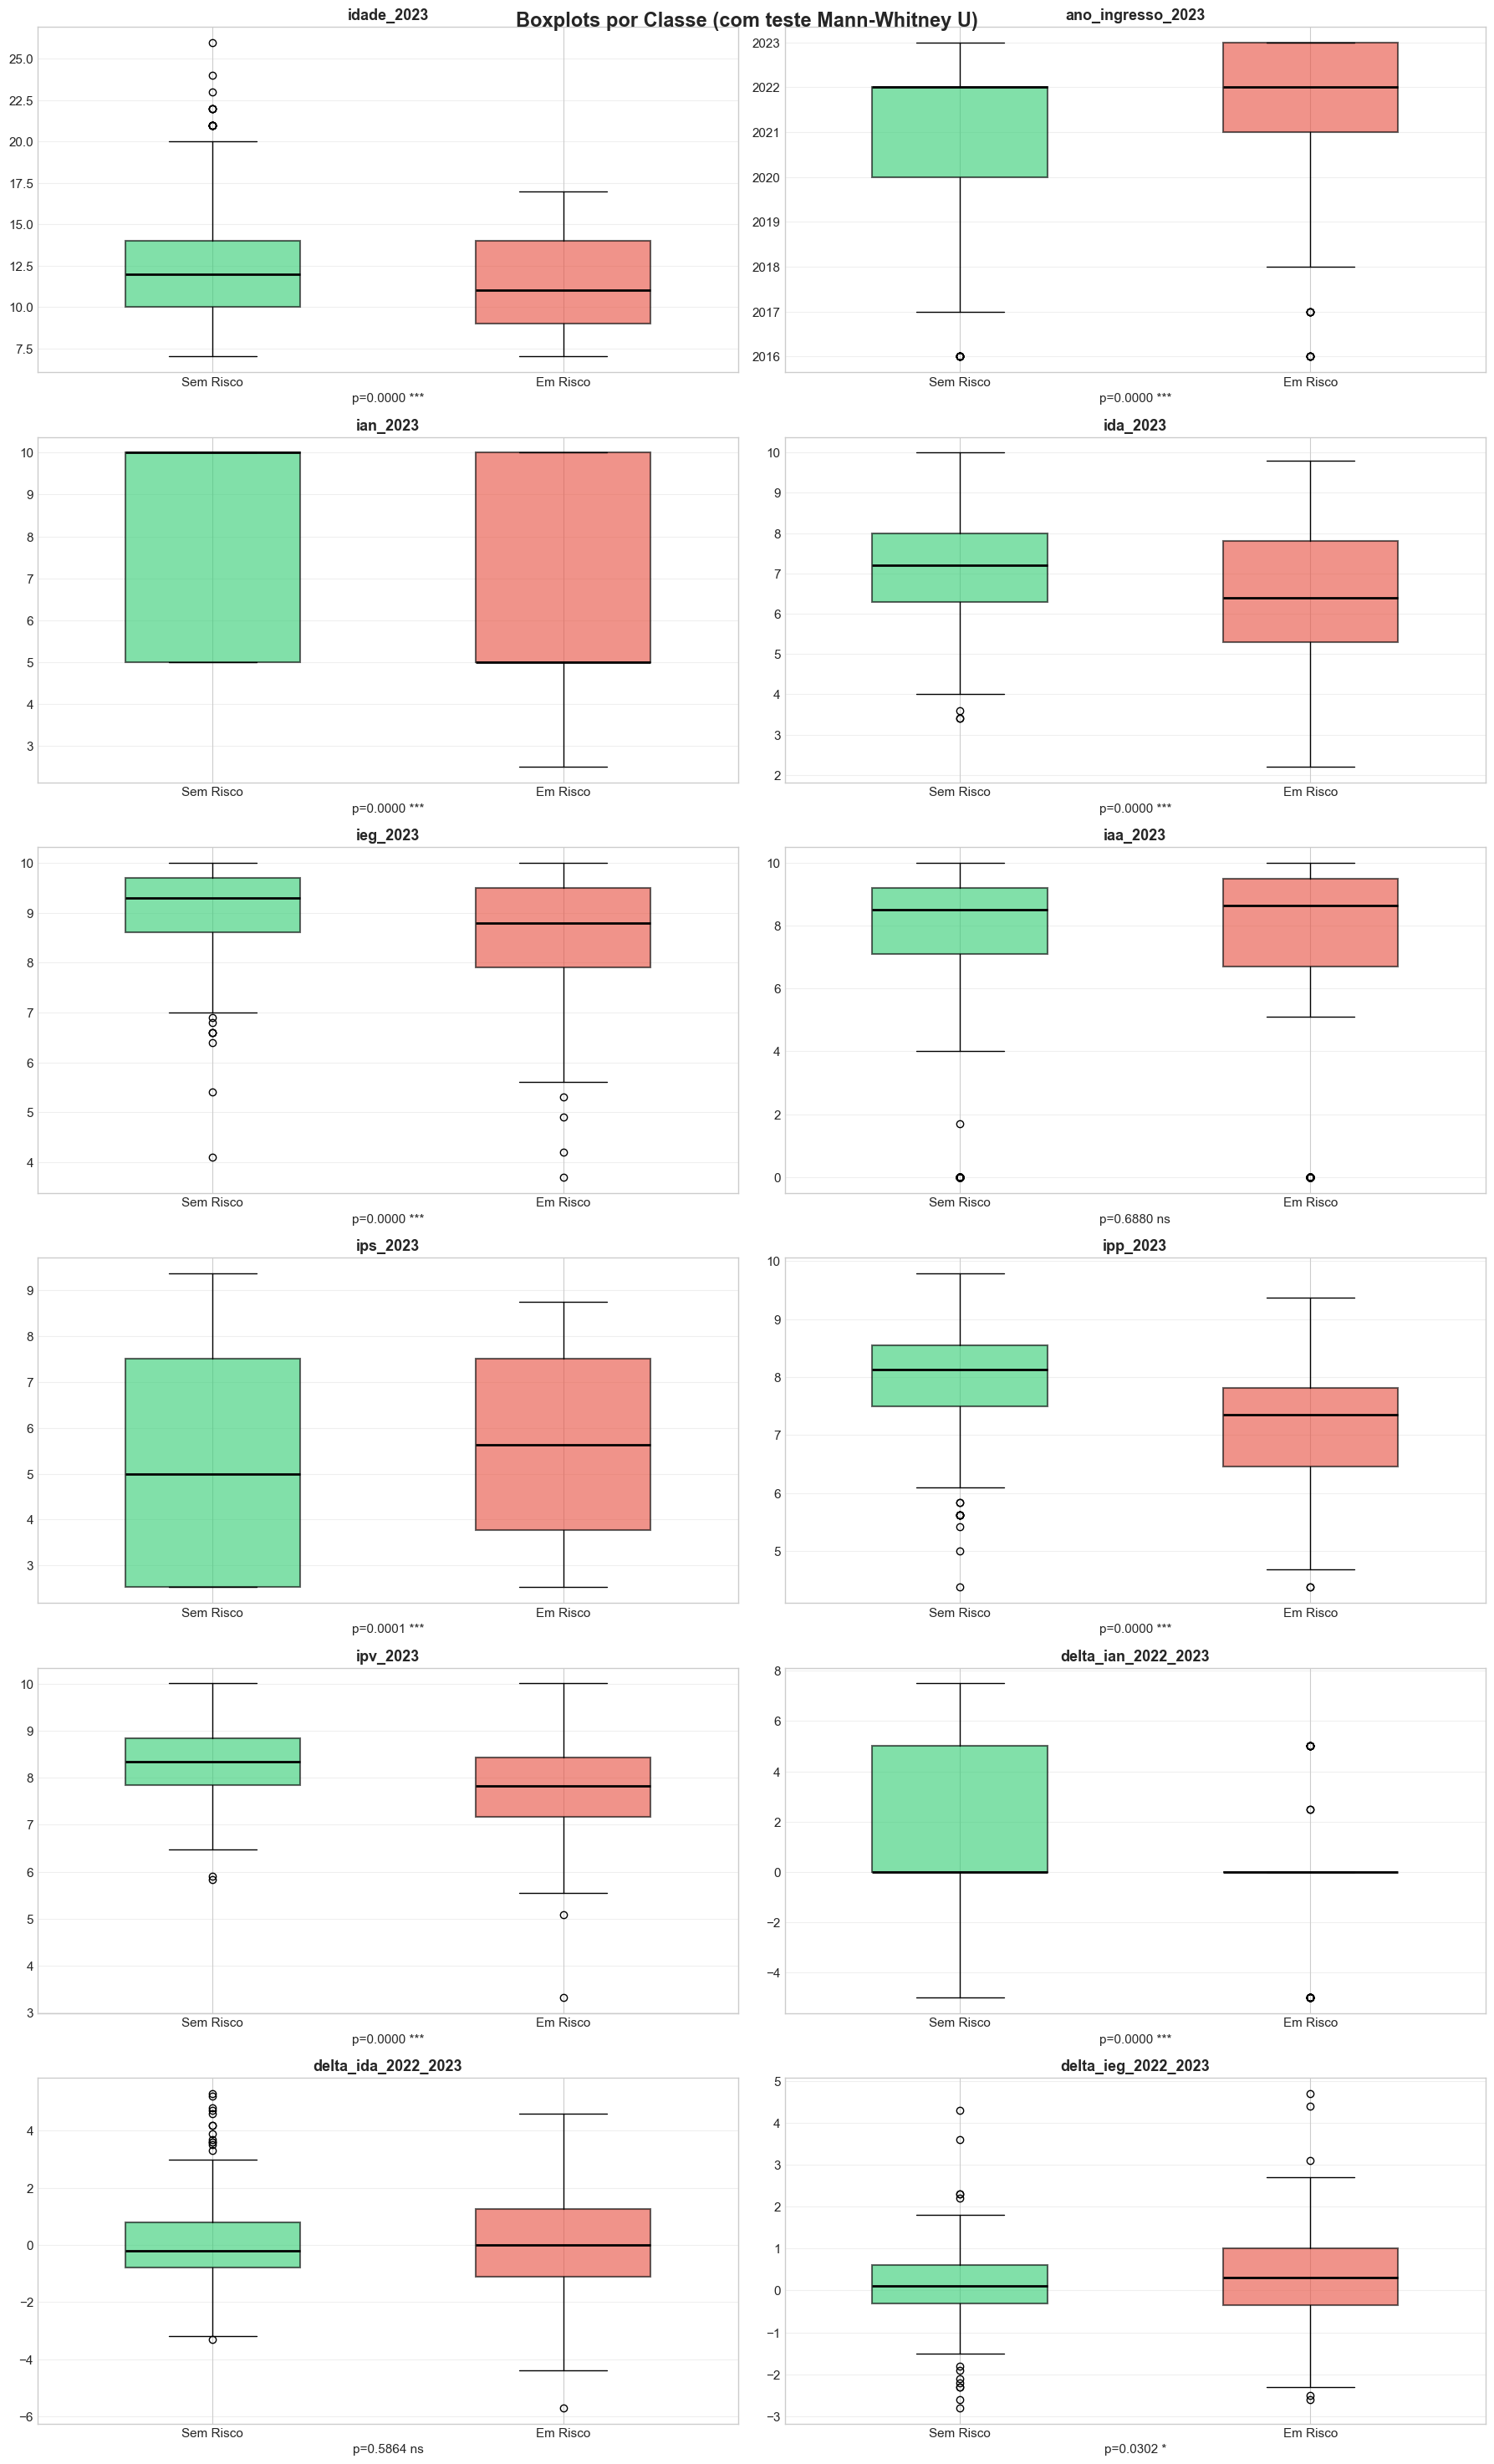

In [7]:
# Boxplots por classe do target — 2 colunas
print("=" * 70)
print("📦 BOXPLOTS DAS FEATURES POR CLASSE")
print("=" * 70)

cols_to_box = numeric_cols[:n_cols_plot]
n_rows_box = (len(cols_to_box) + 1) // 2

fig, axes = plt.subplots(n_rows_box, 2, figsize=(18, 5 * n_rows_box))
axes = axes.flatten()

for idx, col in enumerate(cols_to_box):
    ax = axes[idx]
    data_plot = df[[col, TARGET_COL]].dropna()
    data_plot[TARGET_COL] = data_plot[TARGET_COL].map({0: 'Sem Risco', 1: 'Em Risco'})
    
    bp = ax.boxplot(
        [data_plot[data_plot[TARGET_COL] == 'Sem Risco'][col],
         data_plot[data_plot[TARGET_COL] == 'Em Risco'][col]],
        labels=['Sem Risco', 'Em Risco'],
        patch_artist=True,
        widths=0.5,
        boxprops=dict(linewidth=1.5),
        medianprops=dict(color='black', linewidth=2)
    )
    bp['boxes'][0].set_facecolor(COLORS['success'])
    bp['boxes'][0].set_alpha(0.6)
    bp['boxes'][1].set_facecolor(COLORS['danger'])
    bp['boxes'][1].set_alpha(0.6)
    ax.set_title(col, fontsize=13, fontweight='bold')
    ax.tick_params(labelsize=11)
    
    # Teste estatístico
    g0 = df[df[TARGET_COL] == 0][col].dropna()
    g1 = df[df[TARGET_COL] == 1][col].dropna()
    if len(g0) > 1 and len(g1) > 1:
        stat, pval = stats.mannwhitneyu(g0, g1, alternative='two-sided')
        sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'ns'
        ax.set_xlabel(f'p={pval:.4f} {sig}', fontsize=11)
    ax.grid(True, alpha=0.3, axis='y')

for idx in range(len(cols_to_box), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Boxplots por Classe (com teste Mann-Whitney U)', fontsize=17, fontweight='bold')
plt.tight_layout()
plt.show()

📊 ANÁLISE DE FEATURES CATEGÓRICAS (3 features)


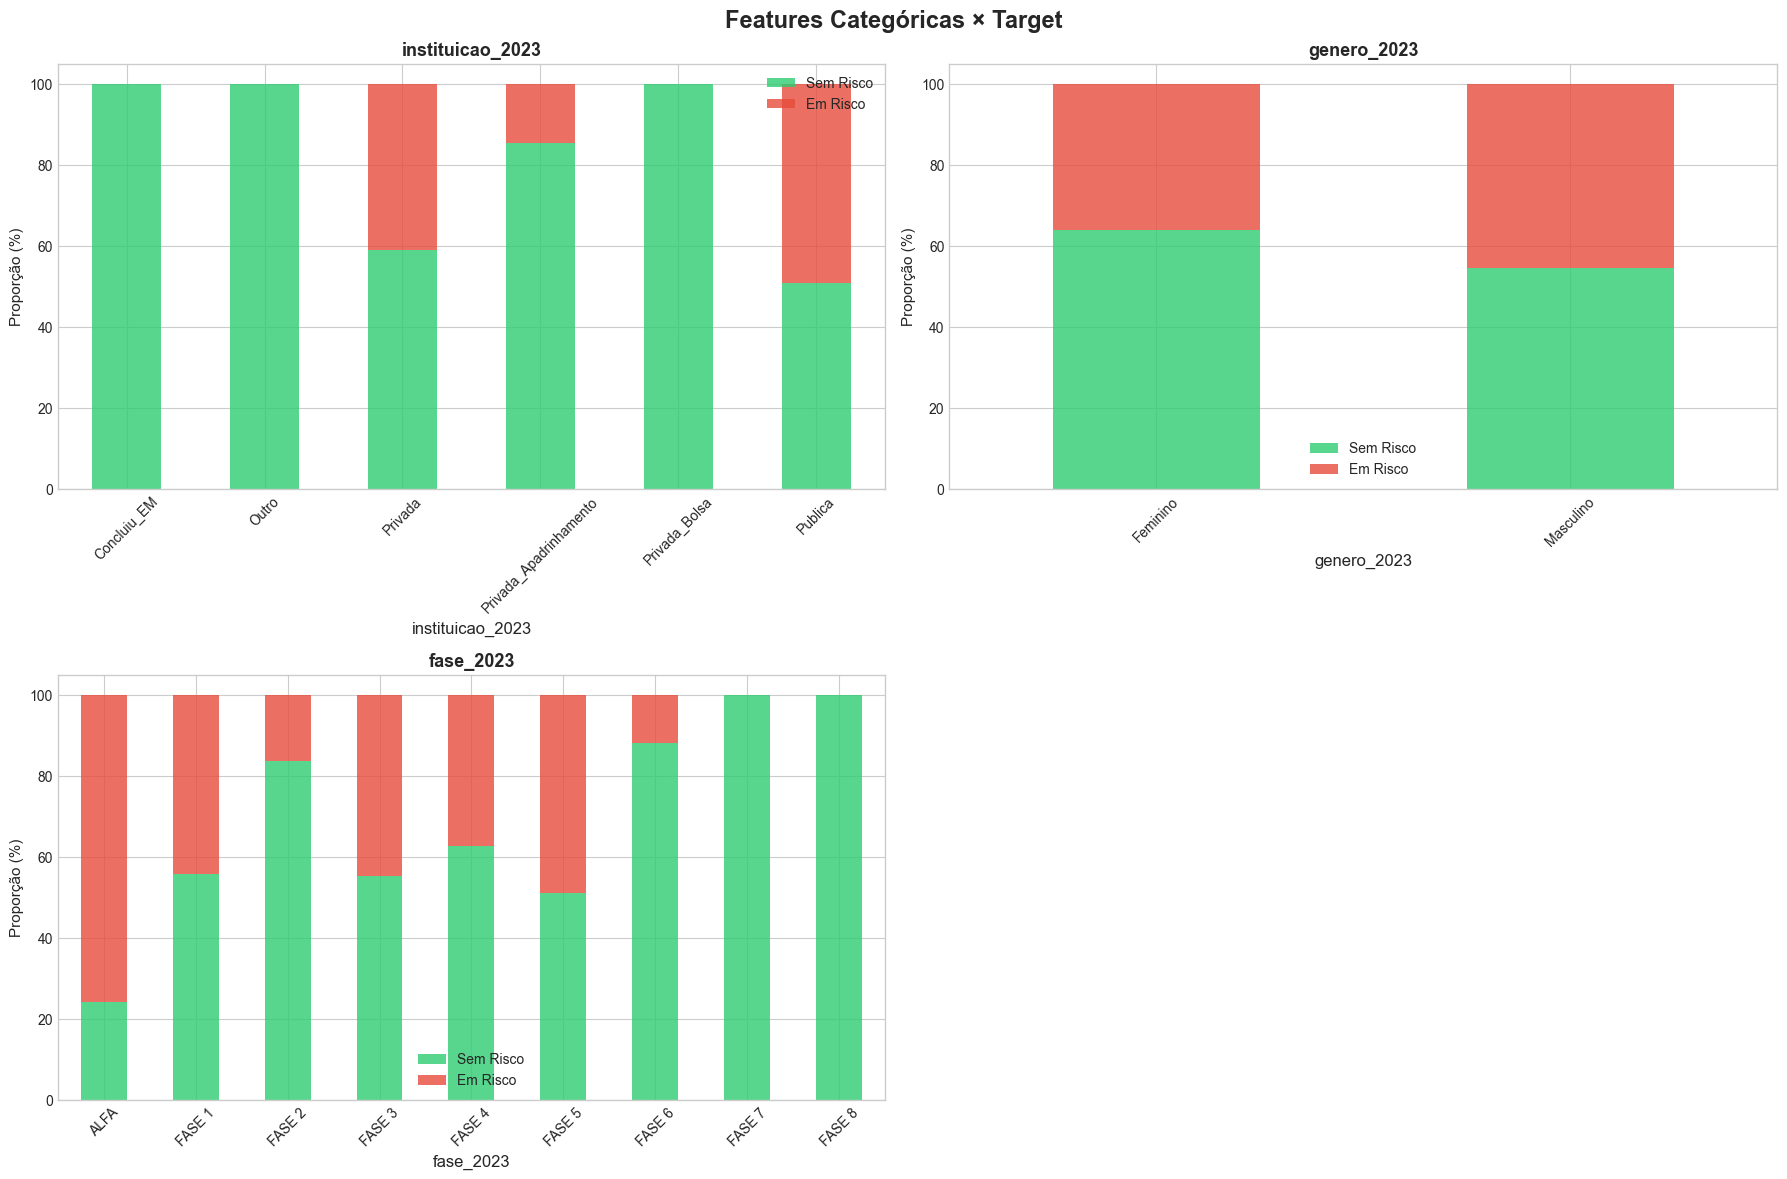

In [8]:
# Análise de features categóricas
if categorical_cols:
    print("=" * 70)
    print(f"📊 ANÁLISE DE FEATURES CATEGÓRICAS ({len(categorical_cols)} features)")
    print("=" * 70)
    
    n_cat = min(len(categorical_cols), 6)
    n_rows = (n_cat + 1) // 2
    fig, axes = plt.subplots(n_rows, 2, figsize=(18, 6 * n_rows))
    axes = axes.flatten() if n_cat > 1 else [axes]
    
    for idx, col in enumerate(categorical_cols[:n_cat]):
        ax = axes[idx]
        ct = pd.crosstab(df[col], df[TARGET_COL], normalize='index') * 100
        ct.plot(kind='bar', stacked=True, ax=ax, 
                color=[COLORS['success'], COLORS['danger']], alpha=0.8)
        ax.set_title(f'{col}', fontweight='bold', fontsize=13)
        ax.set_ylabel('Proporção (%)', fontsize=11)
        ax.legend(['Sem Risco', 'Em Risco'], fontsize=10)
        ax.tick_params(axis='x', rotation=45, labelsize=10)
        ax.tick_params(axis='y', labelsize=10)
    
    for idx in range(n_cat, len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle('Features Categóricas × Target', fontsize=17, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("✅ Sem features categóricas no dataset.")

## 4. Análise de Correlações e Relações <a id="4-correlacoes"></a>

🔗 MATRIZ DE CORRELAÇÃO


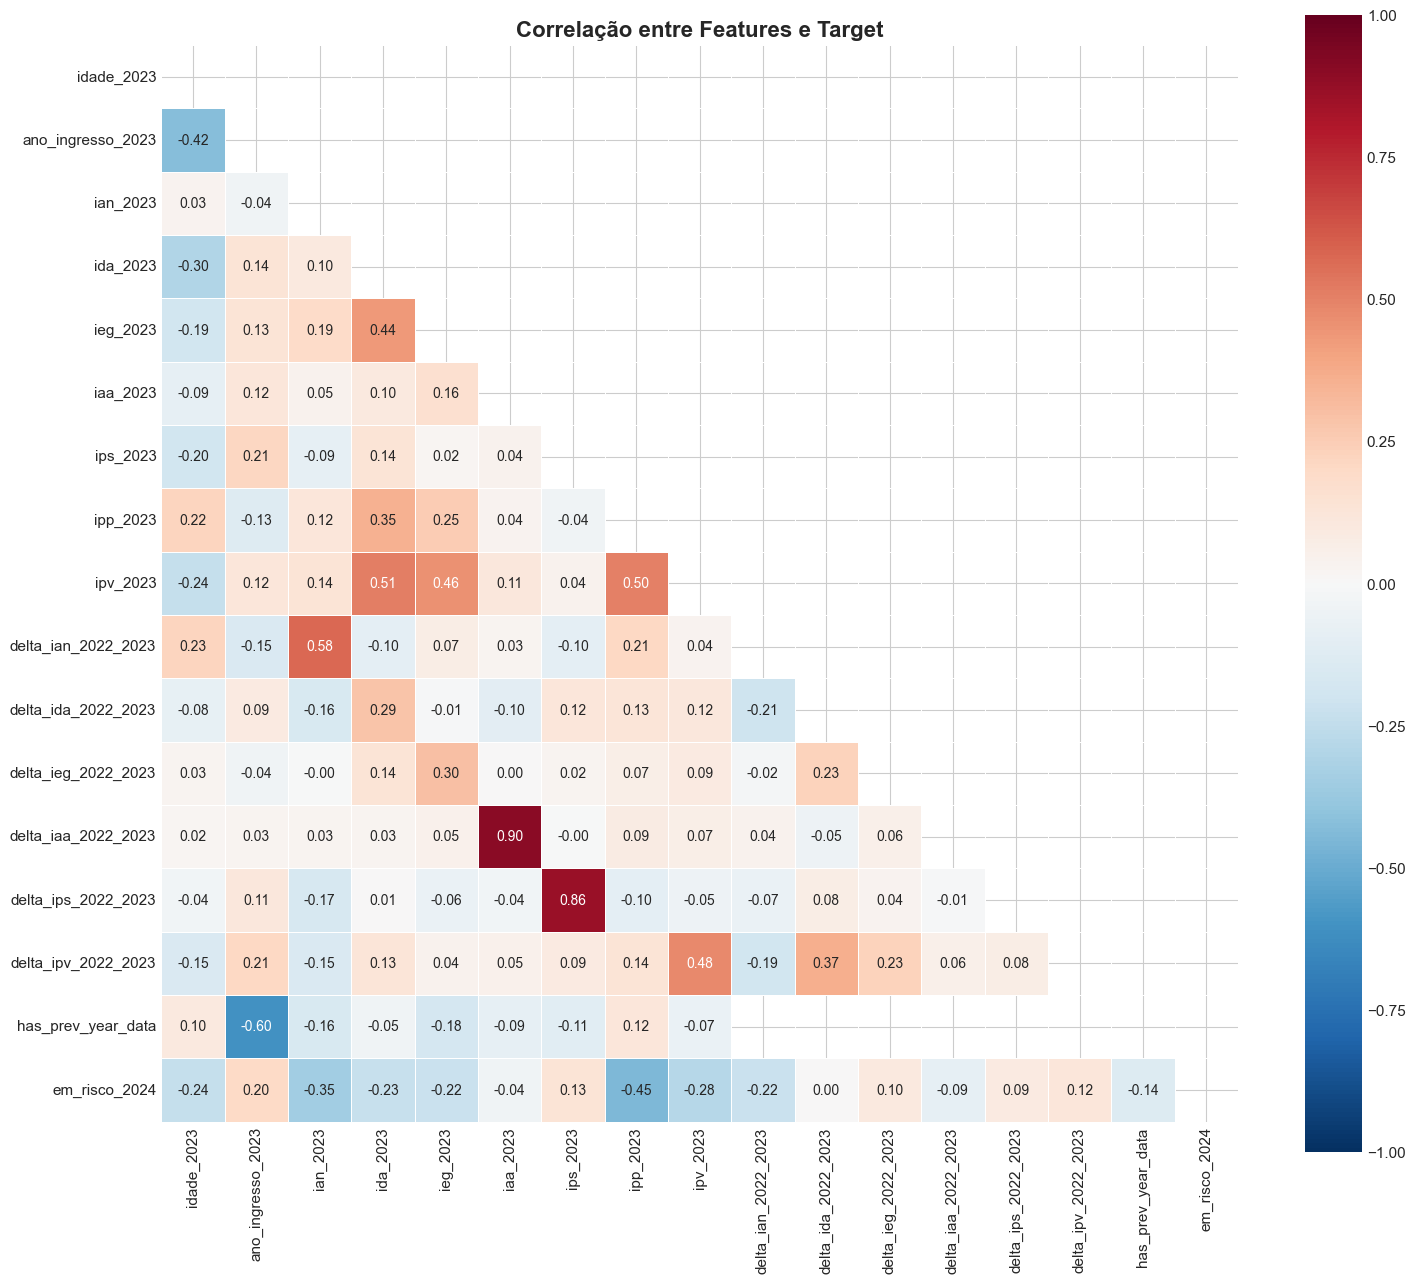

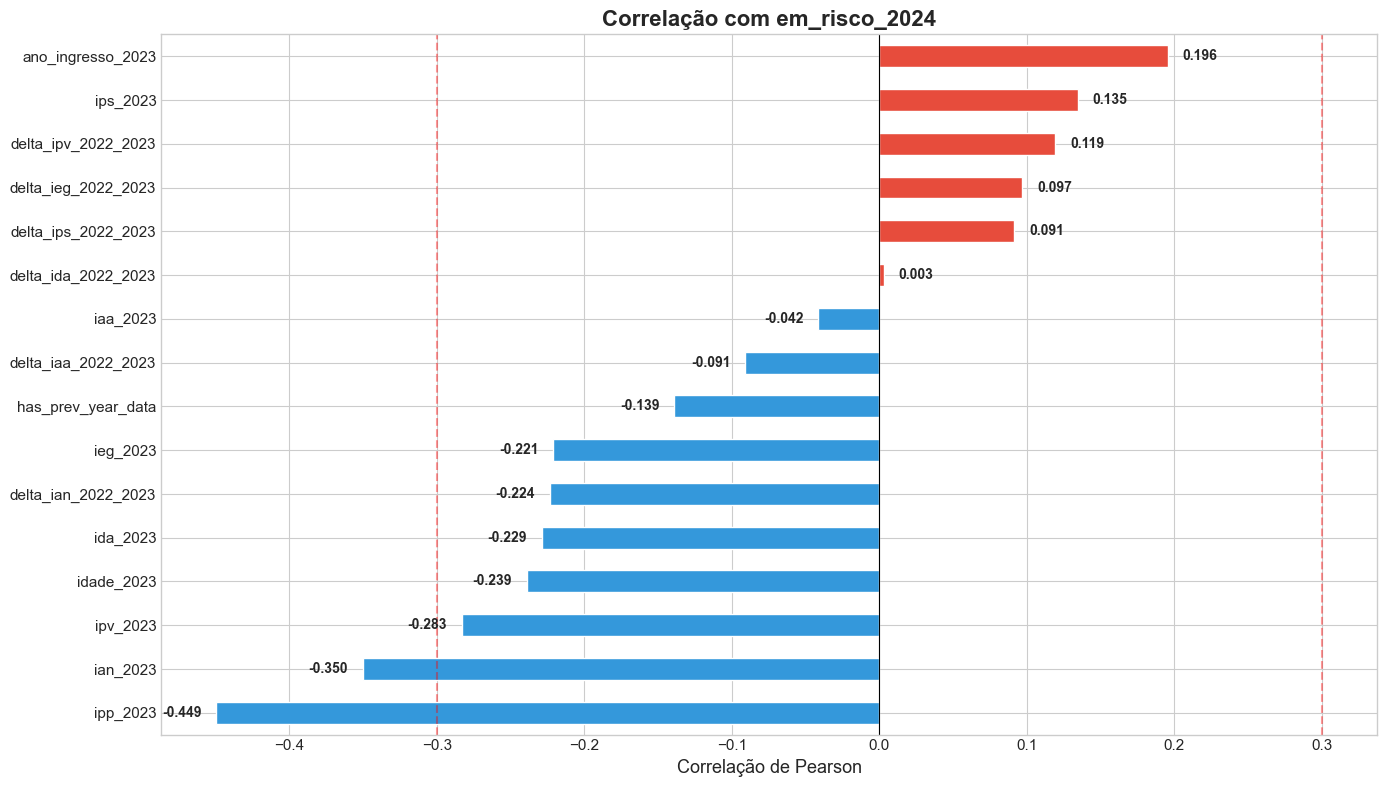


🔝 Top 10 features mais correlacionadas com o target:
   - ipp_2023: -0.4493
   - ian_2023: -0.3502
   - ipv_2023: -0.2832
   - idade_2023: -0.2389
   - ida_2023: -0.2288
   - delta_ian_2022_2023: -0.2235
   - ieg_2023: -0.2209
   + ano_ingresso_2023: 0.1957
   - has_prev_year_data: -0.1390
   + ips_2023: 0.1345


In [9]:
# Matriz de correlação
print("=" * 70)
print("🔗 MATRIZ DE CORRELAÇÃO")
print("=" * 70)

corr_cols = numeric_cols + [TARGET_COL]
corr_matrix = df[corr_cols].corr()

# --- Heatmap completo ---
n_features = len(corr_cols)
fig_size = max(14, n_features * 0.9)
fig, ax1 = plt.subplots(figsize=(fig_size, fig_size * 0.85))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax1, 
            annot_kws={'fontsize': 10}, square=True,
            linewidths=0.5, linecolor='white')
ax1.set_title('Correlação entre Features e Target', fontsize=16, fontweight='bold')
ax1.tick_params(labelsize=11)
plt.tight_layout()
plt.show()

# --- Correlação com target (barplot) ---
fig, ax2 = plt.subplots(figsize=(14, max(8, len(numeric_cols) * 0.5)))
target_corr = corr_matrix[TARGET_COL].drop(TARGET_COL).sort_values()
colors_corr = [COLORS['danger'] if v > 0 else COLORS['secondary'] for v in target_corr.values]
target_corr.plot(kind='barh', ax=ax2, color=colors_corr, edgecolor='white')
ax2.set_title(f'Correlação com {TARGET_COL}', fontsize=16, fontweight='bold')
ax2.set_xlabel('Correlação de Pearson', fontsize=13)
ax2.axvline(x=0, color='black', linewidth=0.8)
ax2.axvline(x=0.3, color='red', linestyle='--', alpha=0.4)
ax2.axvline(x=-0.3, color='red', linestyle='--', alpha=0.4)
ax2.tick_params(labelsize=11)
for i, (feat_name, val) in enumerate(target_corr.items()):
    ax2.text(val + 0.01 if val >= 0 else val - 0.01, i, f'{val:.3f}', 
             va='center', ha='left' if val >= 0 else 'right', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

# Top correlações com target
print("\n🔝 Top 10 features mais correlacionadas com o target:")
abs_corr = target_corr.abs().sort_values(ascending=False)
for feat, corr_val in abs_corr.head(10).items():
    direction = "+" if target_corr[feat] > 0 else "-"
    print(f"   {direction} {feat}: {target_corr[feat]:.4f}")

📊 SCATTER PLOTS: TOP FEATURES vs TARGET


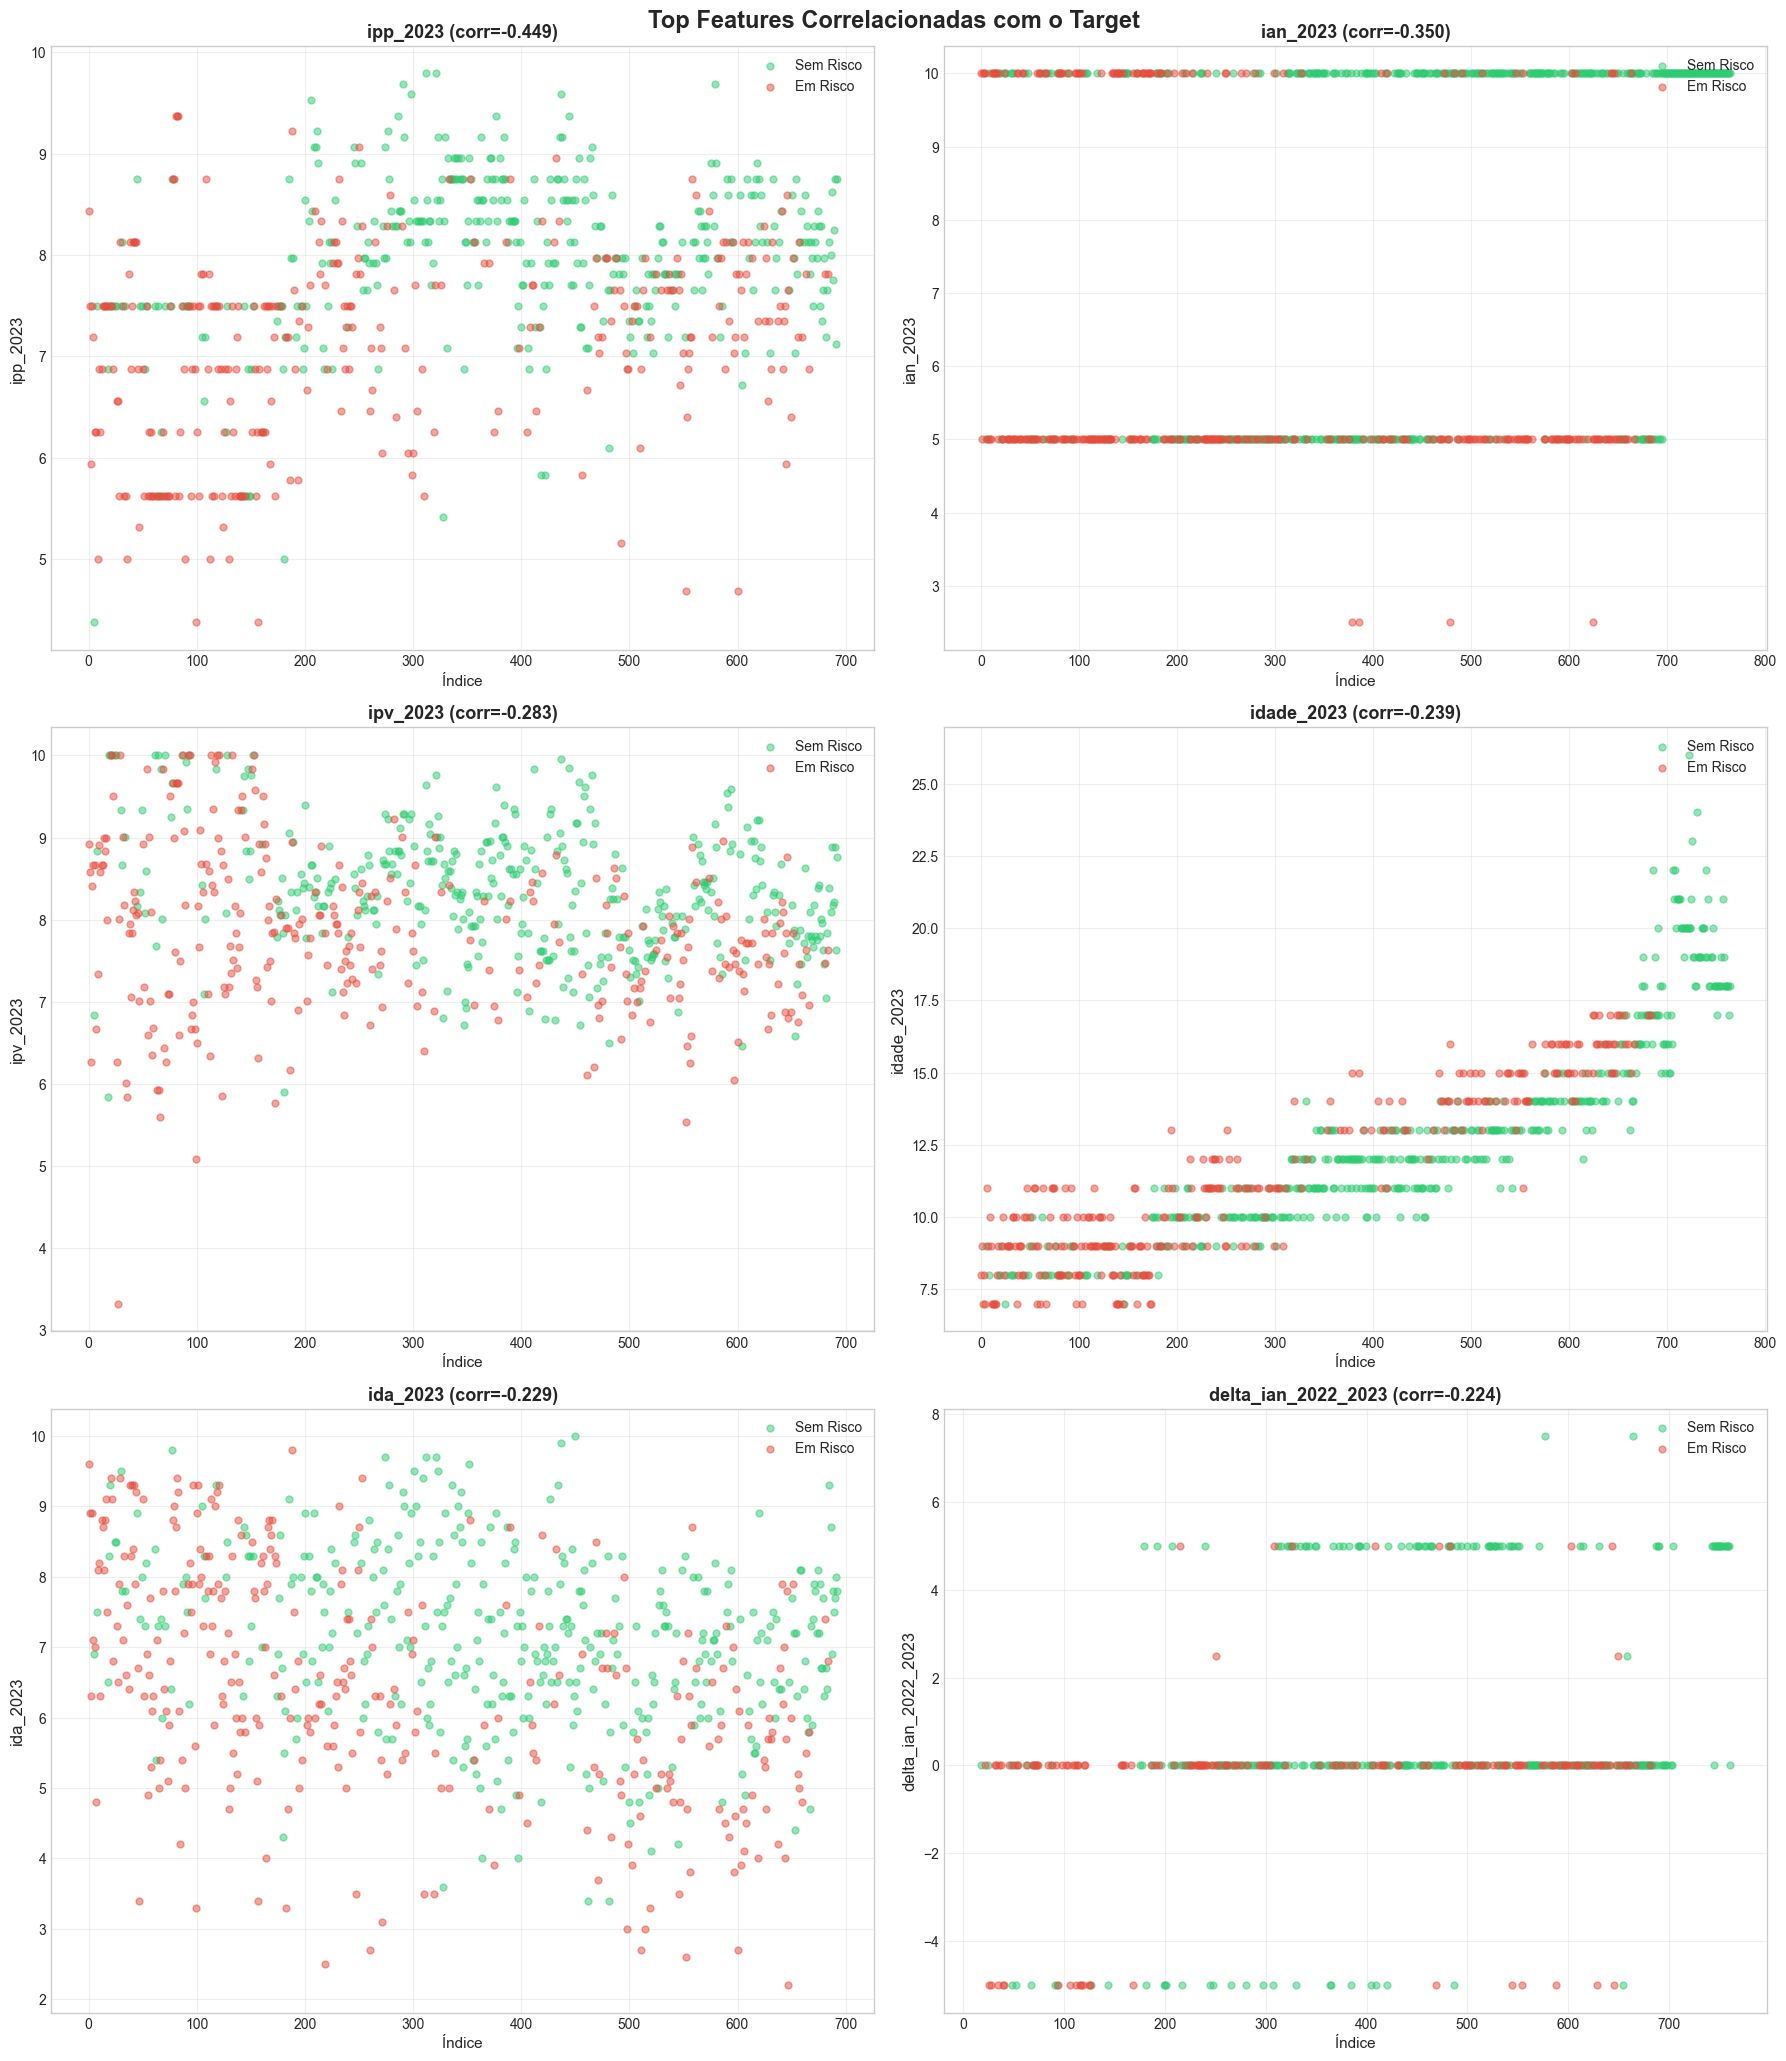

In [10]:
# Pairplot das features mais correlacionadas com target
print("=" * 70)
print("📊 SCATTER PLOTS: TOP FEATURES vs TARGET")
print("=" * 70)

top_features = abs_corr.head(6).index.tolist()
n_rows = (len(top_features) + 1) // 2

fig, axes = plt.subplots(n_rows, 2, figsize=(18, 7 * n_rows))
axes = axes.flatten()

for idx, feat in enumerate(top_features):
    ax = axes[idx]
    for cls, color, label in [(0, COLORS['success'], 'Sem Risco'),
                               (1, COLORS['danger'], 'Em Risco')]:
        subset = df[df[TARGET_COL] == cls]
        ax.scatter(subset.index, subset[feat], alpha=0.5, s=25, color=color, label=label)
    ax.set_title(f'{feat} (corr={target_corr[feat]:.3f})', fontweight='bold', fontsize=13)
    ax.set_ylabel(feat, fontsize=12)
    ax.set_xlabel('Índice', fontsize=11)
    ax.legend(fontsize=10, loc='upper right')
    ax.grid(True, alpha=0.3)
    ax.tick_params(labelsize=10)

for idx in range(len(top_features), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Top Features Correlacionadas com o Target', fontsize=17, fontweight='bold')
plt.tight_layout()
plt.show()

In [11]:
# Análise de multicolinearidade
print("=" * 70)
print("🔍 ANÁLISE DE MULTICOLINEARIDADE")
print("=" * 70)

high_corr_pairs = []
for i in range(len(numeric_cols)):
    for j in range(i + 1, len(numeric_cols)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.8:
            high_corr_pairs.append((numeric_cols[i], numeric_cols[j], corr_val))

if high_corr_pairs:
    print(f"\n⚠️ {len(high_corr_pairs)} pares de features com alta correlação (|r| > 0.8):")
    high_corr_df = pd.DataFrame(high_corr_pairs, columns=['Feature 1', 'Feature 2', 'Correlação'])
    high_corr_df = high_corr_df.sort_values('Correlação', ascending=False, key=abs)
    display(high_corr_df)
else:
    print("✅ Nenhum par de features com correlação > 0.8")

🔍 ANÁLISE DE MULTICOLINEARIDADE

⚠️ 2 pares de features com alta correlação (|r| > 0.8):


,Feature 1,Feature 2,Correlação
0,iaa_2023,delta_iaa_2022_2023,0.899103
1,ips_2023,delta_ips_2022_2023,0.863886


## 5. Pré-processamento e Feature Engineering <a id="5-preprocessing"></a>

In [12]:
# Preparar X e y
print("=" * 70)
print("⚙️ PRÉ-PROCESSAMENTO E FEATURE ENGINEERING")
print("=" * 70)

X = df[FEATURE_COLS].copy()
y = df[TARGET_COL].copy()

print(f"📊 Shape original — X: {X.shape}, y: {y.shape}")

# Converter tipos mistos
for col in X.columns:
    if X[col].dtype == 'object':
        numeric_converted = pd.to_numeric(X[col], errors='coerce')
        if numeric_converted.notna().sum() >= len(X) * 0.7:
            X[col] = numeric_converted

# Recalcular tipos
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"\n📊 Colunas numéricas: {len(numeric_cols)}")
print(f"📊 Colunas categóricas: {len(categorical_cols)}")

⚙️ PRÉ-PROCESSAMENTO E FEATURE ENGINEERING
📊 Shape original — X: (765, 19), y: (765,)

📊 Colunas numéricas: 16
📊 Colunas categóricas: 3


In [13]:
# Feature Engineering avançada
print("\n🔬 FEATURE ENGINEERING")
print("-" * 50)

# Identificar indicadores
indicator_cols = [c for c in numeric_cols if any(
    ind in c.lower() for ind in ['ian', 'ida', 'ieg', 'iaa', 'ips', 'ipp', 'ipv', 'inde']
)]
print(f"📊 Indicadores encontrados: {indicator_cols}")

new_features = []

# 1. Estatísticas agregadas dos indicadores
if indicator_cols:
    X['indicadores_mean'] = X[indicator_cols].mean(axis=1)
    X['indicadores_std'] = X[indicator_cols].std(axis=1)
    X['indicadores_min'] = X[indicator_cols].min(axis=1)
    X['indicadores_max'] = X[indicator_cols].max(axis=1)
    X['indicadores_range'] = X['indicadores_max'] - X['indicadores_min']
    X['indicadores_skew'] = X[indicator_cols].skew(axis=1)
    new_features.extend(['indicadores_mean', 'indicadores_std', 'indicadores_min',
                         'indicadores_max', 'indicadores_range', 'indicadores_skew'])
    print(f"   ✅ Agregações de indicadores: {len(new_features)} features")

# 2. Razões entre indicadores
if len(indicator_cols) >= 2:
    ratio_count = 0
    for i, col1 in enumerate(indicator_cols[:6]):
        for col2 in indicator_cols[i+1:6]:
            ratio_name = f'ratio_{col1.split("_")[0]}_{col2.split("_")[0]}'
            X[ratio_name] = X[col1] / (X[col2] + 1e-6)
            new_features.append(ratio_name)
            ratio_count += 1
    print(f"   ✅ Razões entre indicadores: {ratio_count} features")

# 3. Flags de indicadores abaixo da mediana
if indicator_cols:
    for col in indicator_cols:
        flag_name = f'{col}_below_median'
        X[flag_name] = (X[col] < X[col].median()).astype(int)
        new_features.append(flag_name)
    X['n_indicators_below_median'] = X[[f'{c}_below_median' for c in indicator_cols]].sum(axis=1)
    new_features.append('n_indicators_below_median')
    print(f"   ✅ Flags de risco: {len(indicator_cols) + 1} features")

# 4. Interações com idade
idade_col = [c for c in numeric_cols if 'idade' in c.lower()]
if idade_col:
    idade_col = idade_col[0]
    X['idade_squared'] = X[idade_col] ** 2
    new_features.append('idade_squared')
    
    fase_col = [c for c in numeric_cols if 'fase' in c.lower() and 'ideal' not in c.lower()]
    if fase_col:
        fase_col = fase_col[0]
        X['defasagem_calc'] = X[idade_col] - X[fase_col] - 6
        X['defasagem_flag'] = (X['defasagem_calc'] > 0).astype(int)
        new_features.extend(['defasagem_calc', 'defasagem_flag'])
        print(f"   ✅ Defasagem calculada")

# 5. Missing indicators
for col in FEATURE_COLS:
    if col in X.columns and X[col].isnull().sum() > 0:
        X[f'{col}_missing'] = X[col].isnull().astype(int)
        new_features.append(f'{col}_missing')
X['n_missing'] = X[FEATURE_COLS].isnull().sum(axis=1)
new_features.append('n_missing')

print(f"\n✅ Total de novas features: {len(new_features)}")
print(f"📊 Shape após feature engineering: {X.shape}")


🔬 FEATURE ENGINEERING
--------------------------------------------------
📊 Indicadores encontrados: ['idade_2023', 'ian_2023', 'ida_2023', 'ieg_2023', 'iaa_2023', 'ips_2023', 'ipp_2023', 'ipv_2023', 'delta_ian_2022_2023', 'delta_ida_2022_2023', 'delta_ieg_2022_2023', 'delta_iaa_2022_2023', 'delta_ips_2022_2023', 'delta_ipv_2022_2023']
   ✅ Agregações de indicadores: 6 features
   ✅ Razões entre indicadores: 15 features
   ✅ Flags de risco: 15 features

✅ Total de novas features: 50
📊 Shape após feature engineering: (765, 69)


In [14]:
# Encoding e imputação
print("🔄 ENCODING E IMPUTAÇÃO")
print("-" * 50)

# Encode categóricas
if categorical_cols:
    for col in categorical_cols:
        if col in X.columns:
            le = LabelEncoder()
            X[col] = le.fit_transform(X[col].astype(str))
            print(f"   ✅ Encoded: {col} → {X[col].nunique()} classes")

# Imputação
if X.isnull().sum().sum() > 0:
    print(f"\n🔄 Imputando {X.isnull().sum().sum()} missing values com KNNImputer...")
    imputer = KNNImputer(n_neighbors=5)
    X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)
    print("   ✅ Imputação concluída")
else:
    print("   ✅ Sem missing values")

# Escalar com RobustScaler (resistente a outliers)
scaler = RobustScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

print(f"\n✅ Dados prontos para modelagem: {X_scaled.shape}")

🔄 ENCODING E IMPUTAÇÃO
--------------------------------------------------
   ✅ Encoded: instituicao_2023 → 6 classes
   ✅ Encoded: genero_2023 → 2 classes
   ✅ Encoded: fase_2023 → 9 classes

🔄 Imputando 3298 missing values com KNNImputer...
   ✅ Imputação concluída

✅ Dados prontos para modelagem: (765, 69)


📊 Treino: 612 amostras | Teste: 153 amostras
📊 Distribuição treino: {0: np.int64(366), 1: np.int64(246)}
📊 Distribuição teste:  {0: np.int64(91), 1: np.int64(62)}


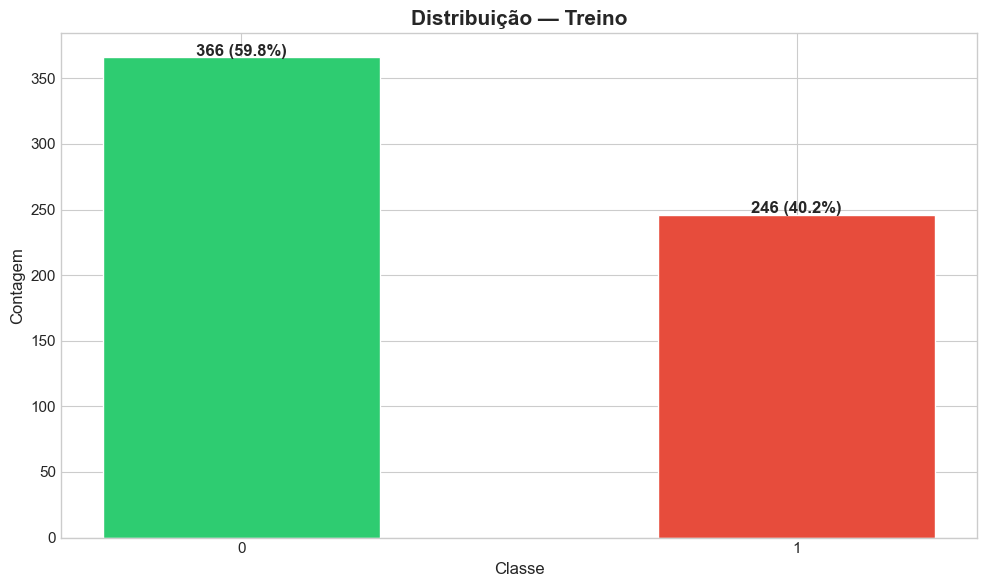

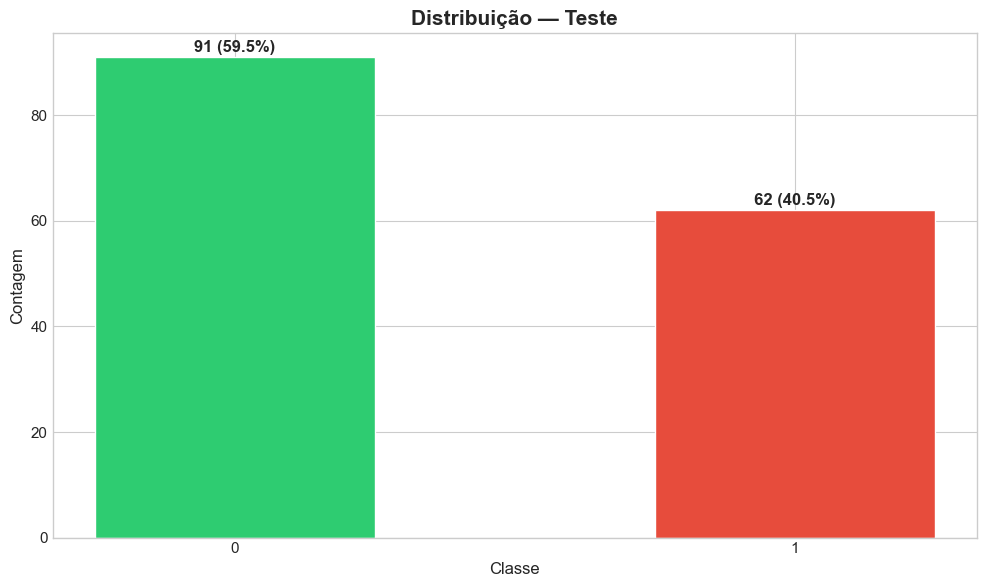

In [15]:
# Split treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"📊 Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras")
print(f"📊 Distribuição treino: {dict(y_train.value_counts())}")
print(f"📊 Distribuição teste:  {dict(y_test.value_counts())}")

# Visualizar split — Treino
fig, ax = plt.subplots(figsize=(10, 6))
counts = y_train.value_counts()
ax.bar(counts.index.astype(str), counts.values, 
       color=[COLORS['success'], COLORS['danger']], edgecolor='white', width=0.5)
ax.set_title('Distribuição — Treino', fontweight='bold', fontsize=15)
ax.set_xlabel('Classe', fontsize=12)
ax.set_ylabel('Contagem', fontsize=12)
for i, v in enumerate(counts.values):
    ax.text(i, v + 1, f'{v} ({v/len(y_train)*100:.1f}%)', ha='center', fontweight='bold', fontsize=12)
ax.tick_params(labelsize=11)
plt.tight_layout()
plt.show()

# Visualizar split — Teste
fig, ax = plt.subplots(figsize=(10, 6))
counts = y_test.value_counts()
ax.bar(counts.index.astype(str), counts.values, 
       color=[COLORS['success'], COLORS['danger']], edgecolor='white', width=0.5)
ax.set_title('Distribuição — Teste', fontweight='bold', fontsize=15)
ax.set_xlabel('Classe', fontsize=12)
ax.set_ylabel('Contagem', fontsize=12)
for i, v in enumerate(counts.values):
    ax.text(i, v + 1, f'{v} ({v/len(y_test)*100:.1f}%)', ha='center', fontweight='bold', fontsize=12)
ax.tick_params(labelsize=11)
plt.tight_layout()
plt.show()

## 6. Treinamento de Modelos <a id="6-treinamento"></a>

In [16]:
# Definir modelos
print("=" * 70)
print("🤖 TREINAMENTO DE MODELOS")
print("=" * 70)

scale_pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

models = {
    'Dummy (Baseline)': DummyClassifier(strategy='stratified', random_state=SEED),
    'Logistic Regression': LogisticRegression(
        random_state=SEED, max_iter=1000, class_weight='balanced', C=1.0
    ),
    'Logistic L1': LogisticRegression(
        random_state=SEED, max_iter=1000, class_weight='balanced',
        penalty='l1', solver='saga', C=0.5
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, random_state=SEED, class_weight='balanced',
        max_depth=10, min_samples_leaf=5, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, random_state=SEED,
        max_depth=5, min_samples_leaf=10, learning_rate=0.1
    ),
    'HistGradientBoosting': HistGradientBoostingClassifier(
        random_state=SEED, max_iter=300, max_depth=8,
        class_weight='balanced', learning_rate=0.1
    ),
    'KNN': KNeighborsClassifier(n_neighbors=7, n_jobs=-1),
    'AdaBoost': AdaBoostClassifier(
        n_estimators=200, random_state=SEED, learning_rate=0.1
    ),
}

# Adicionar boosting libraries se disponíveis
if HAS_XGBOOST:
    models['XGBoost'] = xgb.XGBClassifier(
        n_estimators=300, random_state=SEED, max_depth=6, learning_rate=0.1,
        scale_pos_weight=scale_pos_weight, eval_metric='aucpr',
        use_label_encoder=False, n_jobs=-1
    )

if HAS_LIGHTGBM:
    models['LightGBM'] = lgb.LGBMClassifier(
        n_estimators=300, random_state=SEED, max_depth=6, learning_rate=0.1,
        class_weight='balanced', verbose=-1, n_jobs=-1
    )

if HAS_CATBOOST:
    models['CatBoost'] = CatBoostClassifier(
        iterations=300, random_state=SEED, depth=6, learning_rate=0.1,
        auto_class_weights='Balanced', verbose=False
    )

print(f"📊 Total de modelos: {len(models)}")
for name in models:
    print(f"   • {name}")

🤖 TREINAMENTO DE MODELOS
📊 Total de modelos: 11
   • Dummy (Baseline)
   • Logistic Regression
   • Logistic L1
   • Random Forest
   • Gradient Boosting
   • HistGradientBoosting
   • KNN
   • AdaBoost
   • XGBoost
   • LightGBM
   • CatBoost


In [17]:
# Função de avaliação
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    """Treina e avalia um modelo retornando métricas detalhadas."""
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    # Métricas com threshold padrão (0.5)
    metrics = {
        'model': model_name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
        'f2': fbeta_score(y_test, y_pred, beta=2, zero_division=0),
        'roc_auc': roc_auc_score(y_test, y_proba),
        'pr_auc': average_precision_score(y_test, y_proba),
        'brier': brier_score_loss(y_test, y_proba),
        'log_loss': log_loss(y_test, y_proba),
    }
    
    # Threshold ótimo para F1
    prec_curve, rec_curve, thresholds = precision_recall_curve(y_test, y_proba)
    f1_scores = 2 * (prec_curve * rec_curve) / (prec_curve + rec_curve + 1e-10)
    best_idx = np.argmax(f1_scores)
    
    if best_idx < len(thresholds):
        best_threshold = thresholds[best_idx]
        y_pred_opt = (y_proba >= best_threshold).astype(int)
        metrics['best_threshold'] = best_threshold
        metrics['best_f1'] = f1_scores[best_idx]
        metrics['best_precision'] = precision_score(y_test, y_pred_opt, zero_division=0)
        metrics['best_recall'] = recall_score(y_test, y_pred_opt, zero_division=0)
        metrics['best_f2'] = fbeta_score(y_test, y_pred_opt, beta=2, zero_division=0)
    else:
        metrics['best_threshold'] = 0.5
        metrics['best_f1'] = metrics['f1']
        metrics['best_precision'] = metrics['precision']
        metrics['best_recall'] = metrics['recall']
        metrics['best_f2'] = metrics['f2']
    
    return metrics, model, y_proba

# Treinar e avaliar todos os modelos
results = []
trained_models = {}
probas = {}

for name, model in models.items():
    print(f"\n🔄 Treinando {name}...", end=" ")
    try:
        metrics, trained_model, y_proba = evaluate_model(
            model, X_train, y_train, X_test, y_test, name
        )
        results.append(metrics)
        trained_models[name] = trained_model
        probas[name] = y_proba
        print(f"✅ PR-AUC={metrics['pr_auc']:.4f} | F1*={metrics['best_f1']:.4f} | Recall*={metrics['best_recall']:.4f}")
    except Exception as e:
        print(f"❌ Erro: {e}")

print(f"\n{'='*70}")
print(f"✅ {len(results)} modelos treinados com sucesso!")


🔄 Treinando Dummy (Baseline)... ✅ PR-AUC=0.4266 | F1*=0.5767 | Recall*=1.0000

🔄 Treinando Logistic Regression... ✅ PR-AUC=0.7989 | F1*=0.8000 | Recall*=0.8387

🔄 Treinando Logistic L1... ✅ PR-AUC=0.5780 | F1*=0.6053 | Recall*=0.7419

🔄 Treinando Random Forest... ✅ PR-AUC=0.8703 | F1*=0.8169 | Recall*=0.9355

🔄 Treinando Gradient Boosting... ✅ PR-AUC=0.8772 | F1*=0.8437 | Recall*=0.8710

🔄 Treinando HistGradientBoosting... ✅ PR-AUC=0.8734 | F1*=0.8571 | Recall*=0.8710

🔄 Treinando KNN... ✅ PR-AUC=0.7876 | F1*=0.7769 | Recall*=0.7581

🔄 Treinando AdaBoost... ✅ PR-AUC=0.8706 | F1*=0.8372 | Recall*=0.8710

🔄 Treinando XGBoost... ✅ PR-AUC=0.8719 | F1*=0.8618 | Recall*=0.8548

🔄 Treinando LightGBM... ✅ PR-AUC=0.8709 | F1*=0.8455 | Recall*=0.8387

🔄 Treinando CatBoost... ✅ PR-AUC=0.8949 | F1*=0.8527 | Recall*=0.8871

✅ 11 modelos treinados com sucesso!


In [18]:
# Cross-validation dos top modelos
print("=" * 70)
print("🔄 CROSS-VALIDATION (5-Fold Estratificado)")
print("=" * 70)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_results = {}

# Selecionar top 5 modelos por PR-AUC
results_df = pd.DataFrame(results).sort_values('pr_auc', ascending=False)
top_models = results_df.head(5)['model'].tolist()

for name in top_models:
    model = trained_models[name]
    print(f"\n🔄 CV para {name}...", end=" ")
    
    try:
        scores = cross_validate(
            model.__class__(**model.get_params()) if hasattr(model, 'get_params') else model,
            X_scaled, y, cv=cv,
            scoring=['f1', 'precision', 'recall', 'average_precision', 'roc_auc'],
            n_jobs=-1
        )
        cv_results[name] = {
            'f1': f"{scores['test_f1'].mean():.4f} ± {scores['test_f1'].std():.4f}",
            'precision': f"{scores['test_precision'].mean():.4f} ± {scores['test_precision'].std():.4f}",
            'recall': f"{scores['test_recall'].mean():.4f} ± {scores['test_recall'].std():.4f}",
            'pr_auc': f"{scores['test_average_precision'].mean():.4f} ± {scores['test_average_precision'].std():.4f}",
            'roc_auc': f"{scores['test_roc_auc'].mean():.4f} ± {scores['test_roc_auc'].std():.4f}",
            'pr_auc_mean': scores['test_average_precision'].mean(),
            'pr_auc_std': scores['test_average_precision'].std(),
        }
        print(f"✅ PR-AUC={scores['test_average_precision'].mean():.4f}±{scores['test_average_precision'].std():.4f}")
    except Exception as e:
        print(f"❌ {e}")

if cv_results:
    cv_df = pd.DataFrame(cv_results).T
    print("\n📊 Resultados Cross-Validation:")
    display(cv_df[['pr_auc', 'roc_auc', 'f1', 'precision', 'recall']])

🔄 CROSS-VALIDATION (5-Fold Estratificado)

🔄 CV para CatBoost... ❌ The following error was raised: 'CatBoostClassifier' object has no attribute '__sklearn_tags__'. It seems that there are no classes that implement `__sklearn_tags__` in the MRO and/or all classes in the MRO call `super().__sklearn_tags__()`. Make sure to inherit from `BaseEstimator` which implements `__sklearn_tags__` (or alternatively define `__sklearn_tags__` but we don't recommend this approach). Note that `BaseEstimator` needs to be on the right side of other Mixins in the inheritance order.

🔄 CV para Gradient Boosting... ✅ PR-AUC=0.8372±0.0384

🔄 CV para HistGradientBoosting... ✅ PR-AUC=0.8258±0.0328

🔄 CV para XGBoost... ✅ PR-AUC=0.8343±0.0360

🔄 CV para LightGBM... ✅ PR-AUC=0.8318±0.0372

📊 Resultados Cross-Validation:


,pr_auc,roc_auc,f1,precision,recall
Gradient Boosting,0.8372 ± 0.0384,0.8995 ± 0.0266,0.7776 ± 0.0375,0.7762 ± 0.0330,0.7791 ± 0.0428
HistGradientBoosting,0.8258 ± 0.0328,0.8940 ± 0.0198,0.7669 ± 0.0283,0.7593 ± 0.0279,0.7759 ± 0.0432
XGBoost,0.8343 ± 0.0360,0.9013 ± 0.0234,0.7795 ± 0.0351,0.7571 ± 0.0378,0.8049 ± 0.0483
LightGBM,0.8318 ± 0.0372,0.8961 ± 0.0184,0.7738 ± 0.0196,0.7666 ± 0.0340,0.7823 ± 0.0208


## 7. Métricas e Avaliação <a id="7-metricas"></a>

In [19]:
# Tabela comparativa principal
print("=" * 70)
print("📊 TABELA COMPARATIVA DE MODELOS")
print("=" * 70)

results_df = pd.DataFrame(results).sort_values('pr_auc', ascending=False).reset_index(drop=True)

display_cols = ['model', 'pr_auc', 'roc_auc', 'best_f1', 'best_f2',
                'best_precision', 'best_recall', 'best_threshold', 'brier']
print("\n🏆 Ranking por PR-AUC:")
display(results_df[display_cols].round(4))

# Melhor modelo
best = results_df.iloc[0]
print(f"\n🥇 MELHOR MODELO: {best['model']}")
print(f"   PR-AUC:     {best['pr_auc']:.4f}")
print(f"   ROC-AUC:    {best['roc_auc']:.4f}")
print(f"   Best F1:    {best['best_f1']:.4f}")
print(f"   Best F2:    {best['best_f2']:.4f}")
print(f"   Precision:  {best['best_precision']:.4f}")
print(f"   Recall:     {best['best_recall']:.4f}")
print(f"   Threshold:  {best['best_threshold']:.4f}")
print(f"   Brier:      {best['brier']:.4f}")

📊 TABELA COMPARATIVA DE MODELOS

🏆 Ranking por PR-AUC:


,model,pr_auc,roc_auc,best_f1,best_f2,best_precision,best_recall,best_threshold,brier
0,CatBoost,0.8949,0.9277,0.8527,0.8730,0.8209,0.8871,0.1975,0.1097
1,Gradient Boosting,0.8772,0.9195,0.8437,0.8599,0.8182,0.8710,0.1816,0.1148
2,HistGradientBoosting,0.8734,0.9233,0.8571,0.8654,0.8438,0.8710,0.2207,0.1149
3,XGBoost,0.8719,0.9302,0.8618,0.8576,0.8689,0.8548,0.4474,0.1081
4,LightGBM,0.8709,0.9192,0.8455,0.8414,0.8525,0.8387,0.4978,0.1170
5,AdaBoost,0.8706,0.9068,0.8372,0.8571,0.8060,0.8710,0.4494,0.1668
6,Random Forest,0.8703,0.9169,0.8169,0.8841,0.7250,0.9355,0.3627,0.1182
7,Logistic Regression,0.7989,0.8710,0.8000,0.8228,0.7647,0.8387,0.5302,0.1463
8,KNN,0.7876,0.8679,0.7769,0.7655,0.7966,0.7581,0.5714,0.1413
9,Logistic L1,0.5780,0.6512,0.6053,0.6805,0.5111,0.7419,0.5000,0.2464



🥇 MELHOR MODELO: CatBoost
   PR-AUC:     0.8949
   ROC-AUC:    0.9277
   Best F1:    0.8527
   Best F2:    0.8730
   Precision:  0.8209
   Recall:     0.8871
   Threshold:  0.1975
   Brier:      0.1097


In [20]:
# Classification Report do melhor modelo
best_model_name = best['model']
best_model = trained_models[best_model_name]
best_proba = probas[best_model_name]
best_threshold = best['best_threshold']

y_pred_best = (best_proba >= best_threshold).astype(int)

print("=" * 70)
print(f"📋 CLASSIFICATION REPORT — {best_model_name}")
print(f"   (Threshold otimizado: {best_threshold:.4f})")
print("=" * 70)
print(classification_report(y_test, y_pred_best, target_names=['Sem Risco', 'Em Risco']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_best)
print(f"\nConfusion Matrix:")
print(f"   TN={cm[0,0]}  FP={cm[0,1]}")
print(f"   FN={cm[1,0]}  TP={cm[1,1]}")

📋 CLASSIFICATION REPORT — CatBoost
   (Threshold otimizado: 0.1975)
              precision    recall  f1-score   support

   Sem Risco       0.92      0.87      0.89        91
    Em Risco       0.82      0.89      0.85        62

    accuracy                           0.88       153
   macro avg       0.87      0.88      0.87       153
weighted avg       0.88      0.88      0.88       153


Confusion Matrix:
   TN=79  FP=12
   FN=7  TP=55


## 8. Análise Gráfica de Performance <a id="8-graficos"></a>

📊 DASHBOARD DE PERFORMANCE DOS MODELOS


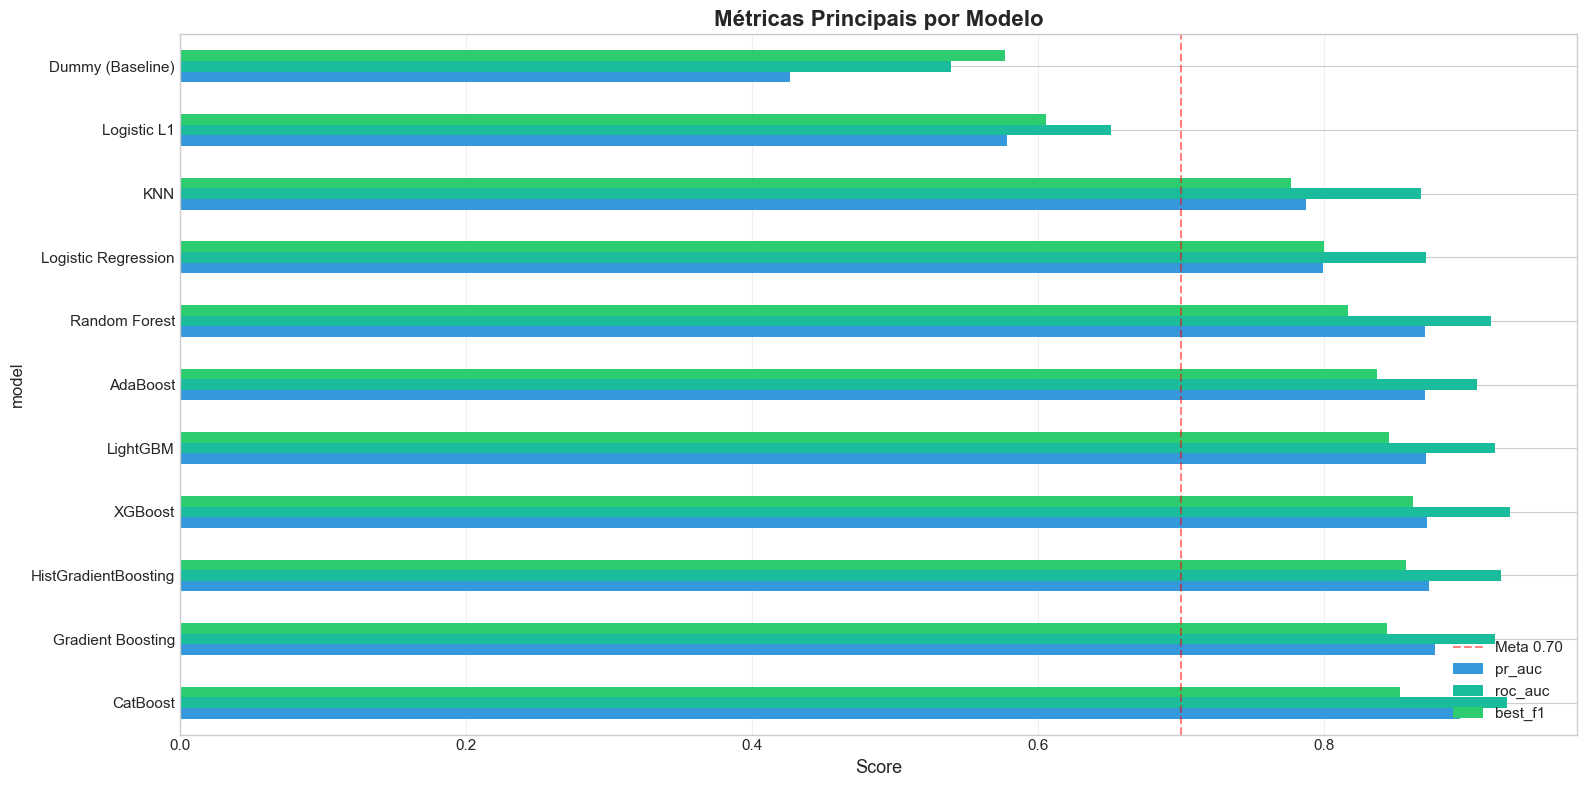

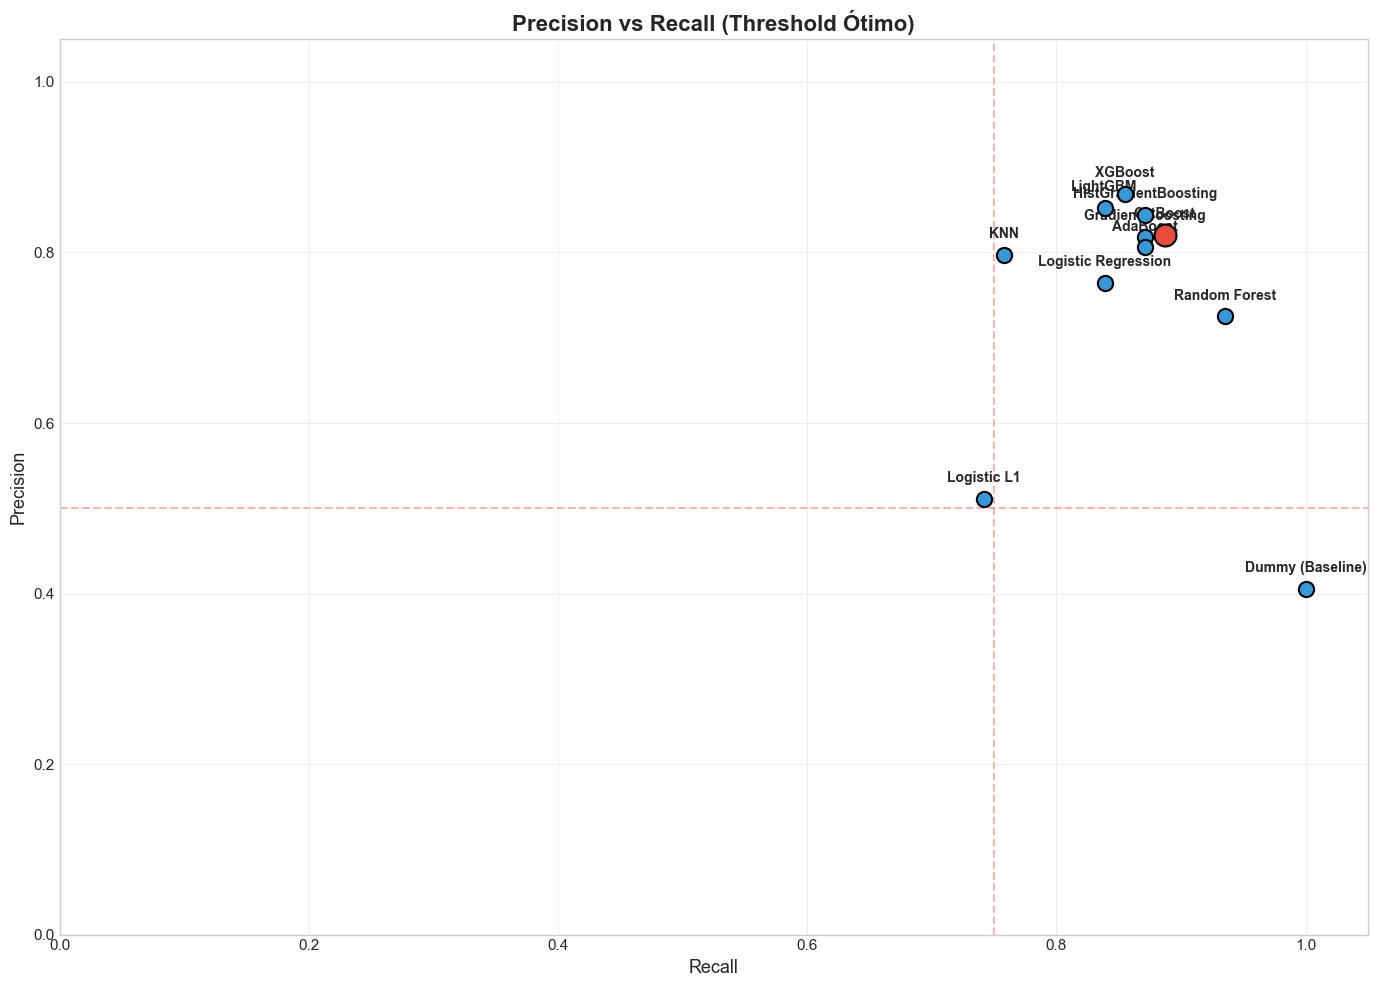

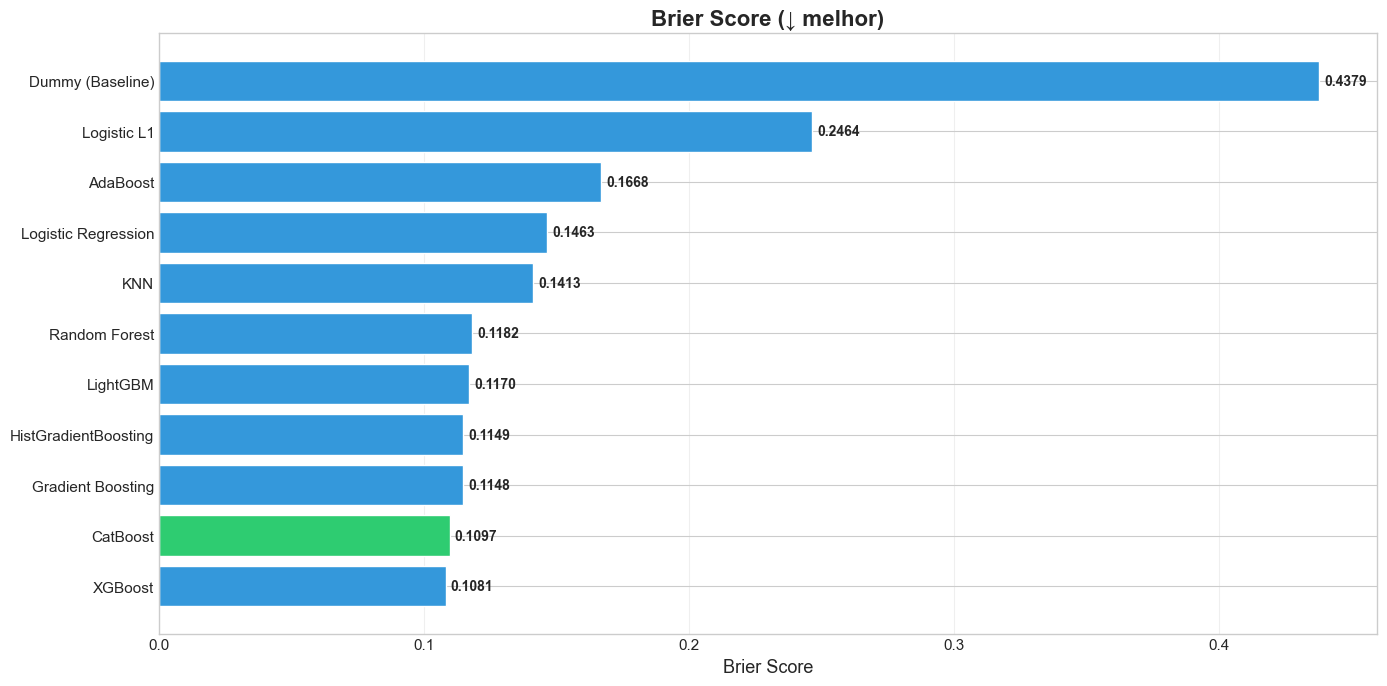

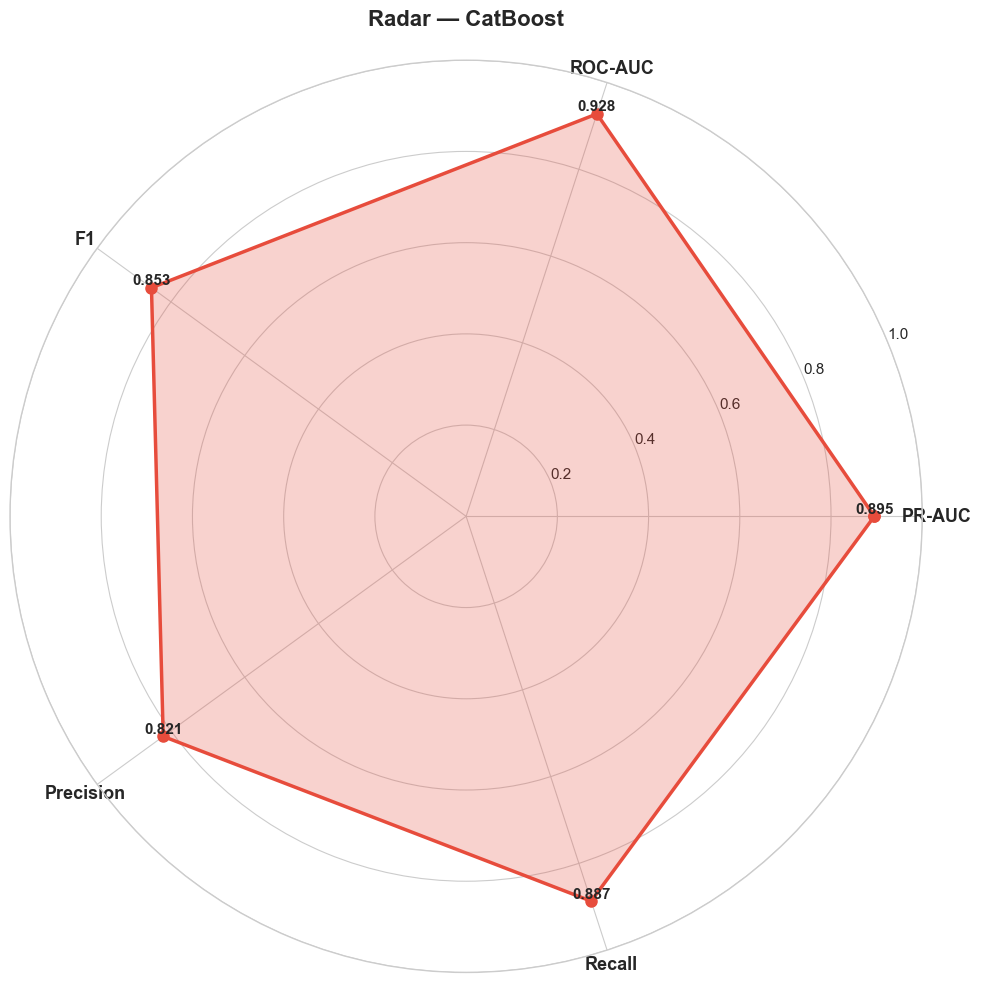

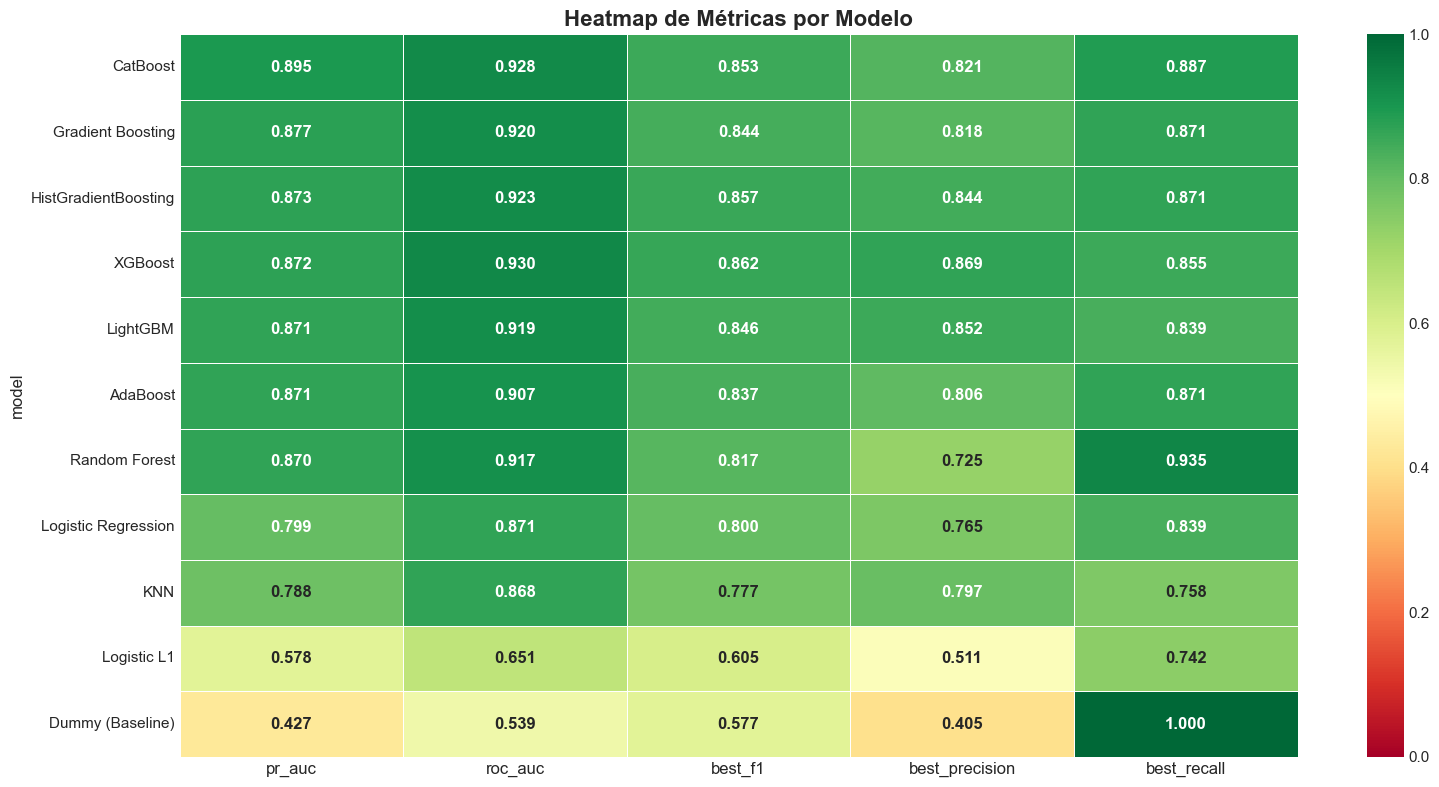

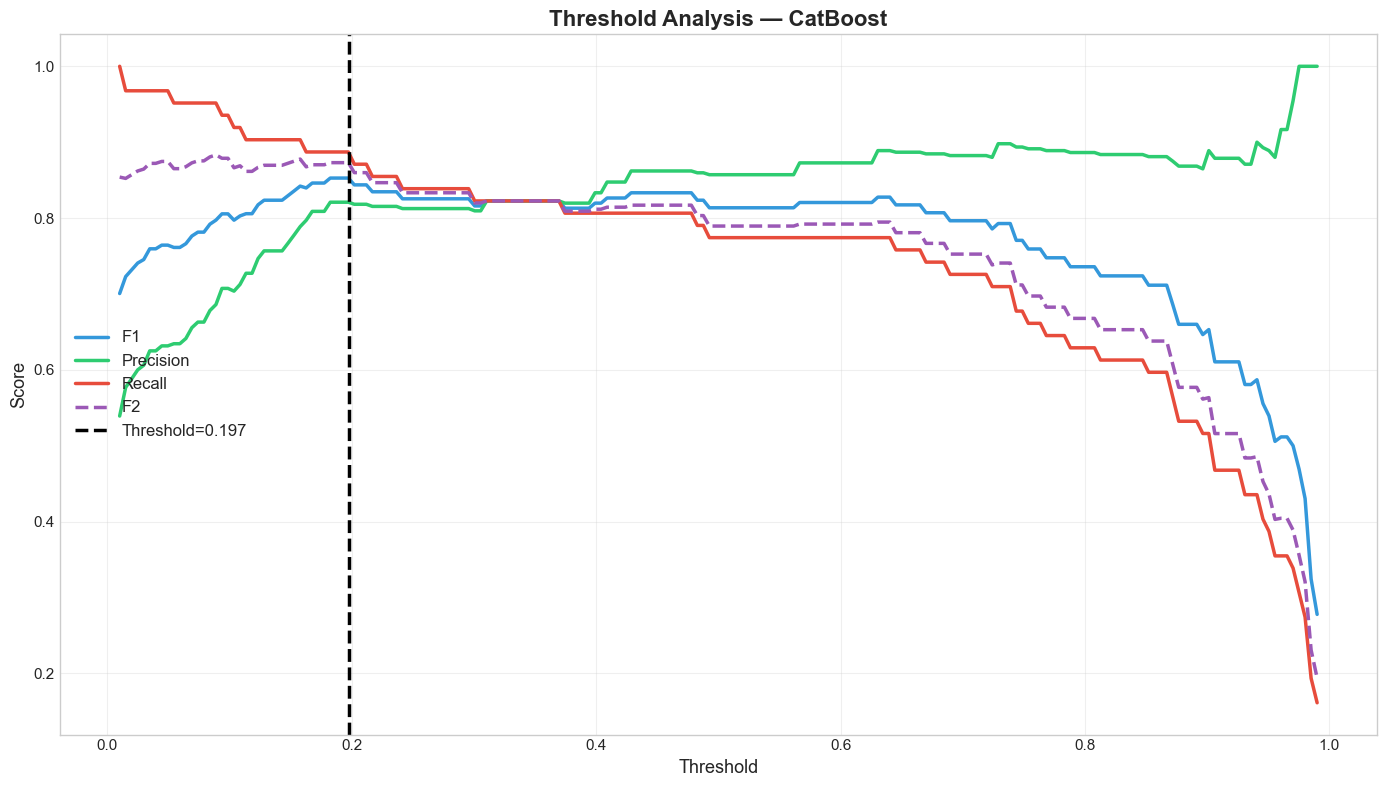

✅ Dashboard salvo em artifacts/performance_dashboard.png


In [21]:
# ===== DASHBOARD DE PERFORMANCE — Gráficos Individuais =====
print("=" * 70)
print("📊 DASHBOARD DE PERFORMANCE DOS MODELOS")
print("=" * 70)

# --- 1. Barplot de métricas principais ---
fig, ax1 = plt.subplots(figsize=(16, max(8, len(results_df) * 0.7)))
metrics_plot = results_df[['model', 'pr_auc', 'roc_auc', 'best_f1']].set_index('model')
metrics_plot.plot(kind='barh', ax=ax1, color=[COLORS['secondary'], COLORS['info'], COLORS['success']])
ax1.set_title('Métricas Principais por Modelo', fontweight='bold', fontsize=16)
ax1.set_xlabel('Score', fontsize=13)
ax1.axvline(x=0.7, color='red', linestyle='--', alpha=0.5, label='Meta 0.70')
ax1.legend(fontsize=11, loc='lower right')
ax1.tick_params(labelsize=11)
ax1.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

# --- 2. Precision vs Recall scatter ---
fig, ax2 = plt.subplots(figsize=(14, 10))
for idx, row in results_df.iterrows():
    color = COLORS['danger'] if row['model'] == best_model_name else COLORS['secondary']
    size = 250 if row['model'] == best_model_name else 120
    ax2.scatter(row['best_recall'], row['best_precision'], s=size, color=color,
               edgecolors='black', linewidth=1.5, zorder=5)
    ax2.annotate(row['model'], (row['best_recall'], row['best_precision']),
                fontsize=10, ha='center', va='bottom', 
                xytext=(0, 10), textcoords='offset points', fontweight='bold')
ax2.set_xlabel('Recall', fontsize=13)
ax2.set_ylabel('Precision', fontsize=13)
ax2.set_title('Precision vs Recall (Threshold Ótimo)', fontweight='bold', fontsize=16)
ax2.axhline(y=0.5, color='red', linestyle='--', alpha=0.3)
ax2.axvline(x=0.75, color='red', linestyle='--', alpha=0.3)
ax2.set_xlim(0, 1.05)
ax2.set_ylim(0, 1.05)
ax2.grid(True, alpha=0.3)
ax2.tick_params(labelsize=11)
plt.tight_layout()
plt.show()

# --- 3. Brier Score ---
fig, ax3 = plt.subplots(figsize=(14, max(7, len(results_df) * 0.6)))
brier_sorted = results_df.sort_values('brier')
colors_brier = [COLORS['success'] if m == best_model_name else COLORS['secondary'] 
                for m in brier_sorted['model']]
ax3.barh(brier_sorted['model'], brier_sorted['brier'], color=colors_brier, edgecolor='white')
ax3.set_title('Brier Score (↓ melhor)', fontweight='bold', fontsize=16)
ax3.set_xlabel('Brier Score', fontsize=13)
ax3.tick_params(labelsize=11)
for i, (_, row) in enumerate(brier_sorted.iterrows()):
    ax3.text(row['brier'] + 0.002, i, f"{row['brier']:.4f}", va='center', fontsize=10, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

# --- 4. Radar plot do melhor modelo ---
fig, ax4 = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
categories = ['PR-AUC', 'ROC-AUC', 'F1', 'Precision', 'Recall']
values = [best['pr_auc'], best['roc_auc'], best['best_f1'], 
          best['best_precision'], best['best_recall']]
values += values[:1]
angles = [n / float(len(categories)) * 2 * np.pi for n in range(len(categories))]
angles += angles[:1]

ax4.plot(angles, values, 'o-', linewidth=2.5, color=COLORS['danger'], markersize=8)
ax4.fill(angles, values, alpha=0.25, color=COLORS['danger'])
ax4.set_xticks(angles[:-1])
ax4.set_xticklabels(categories, fontsize=13, fontweight='bold')
ax4.set_ylim(0, 1)
ax4.set_title(f'Radar — {best_model_name}', fontweight='bold', fontsize=16, pad=25)
# Adicionar valores no radar
for angle, val, cat in zip(angles[:-1], values[:-1], categories):
    ax4.annotate(f'{val:.3f}', xy=(angle, val), fontsize=11, fontweight='bold',
                ha='center', va='bottom')
plt.tight_layout()
plt.show()

# --- 5. Heatmap de métricas ---
fig, ax5 = plt.subplots(figsize=(16, max(8, len(results_df) * 0.7)))
heatmap_data = results_df[['model', 'pr_auc', 'roc_auc', 'best_f1', 'best_precision', 'best_recall']].set_index('model')
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='RdYlGn', ax=ax5,
            linewidths=0.5, linecolor='white', vmin=0, vmax=1,
            annot_kws={'fontsize': 12, 'fontweight': 'bold'})
ax5.set_title('Heatmap de Métricas por Modelo', fontweight='bold', fontsize=16)
ax5.tick_params(labelsize=11)
ax5.set_xticklabels(ax5.get_xticklabels(), rotation=0, fontsize=12)
plt.tight_layout()
plt.show()

# --- 6. Threshold analysis ---
fig, ax6 = plt.subplots(figsize=(14, 8))
thresholds_range = np.linspace(0.01, 0.99, 200)
f1_t, prec_t, rec_t, f2_t = [], [], [], []
for t in thresholds_range:
    yp = (best_proba >= t).astype(int)
    f1_t.append(f1_score(y_test, yp, zero_division=0))
    prec_t.append(precision_score(y_test, yp, zero_division=0))
    rec_t.append(recall_score(y_test, yp, zero_division=0))
    f2_t.append(fbeta_score(y_test, yp, beta=2, zero_division=0))

ax6.plot(thresholds_range, f1_t, label='F1', linewidth=2.5, color=COLORS['secondary'])
ax6.plot(thresholds_range, prec_t, label='Precision', linewidth=2.5, color=COLORS['success'])
ax6.plot(thresholds_range, rec_t, label='Recall', linewidth=2.5, color=COLORS['danger'])
ax6.plot(thresholds_range, f2_t, label='F2', linewidth=2.5, color=COLORS['purple'], linestyle='--')
ax6.axvline(x=best_threshold, color='black', linestyle='--', linewidth=2.5,
            label=f'Threshold={best_threshold:.3f}')
ax6.set_xlabel('Threshold', fontsize=13)
ax6.set_ylabel('Score', fontsize=13)
ax6.set_title(f'Threshold Analysis — {best_model_name}', fontweight='bold', fontsize=16)
ax6.legend(fontsize=12, loc='center left')
ax6.grid(True, alpha=0.3)
ax6.tick_params(labelsize=11)
plt.tight_layout()
plt.savefig(ARTIFACTS_PATH / 'performance_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Dashboard salvo em artifacts/performance_dashboard.png")

📈 CURVAS PRECISION-RECALL E ROC


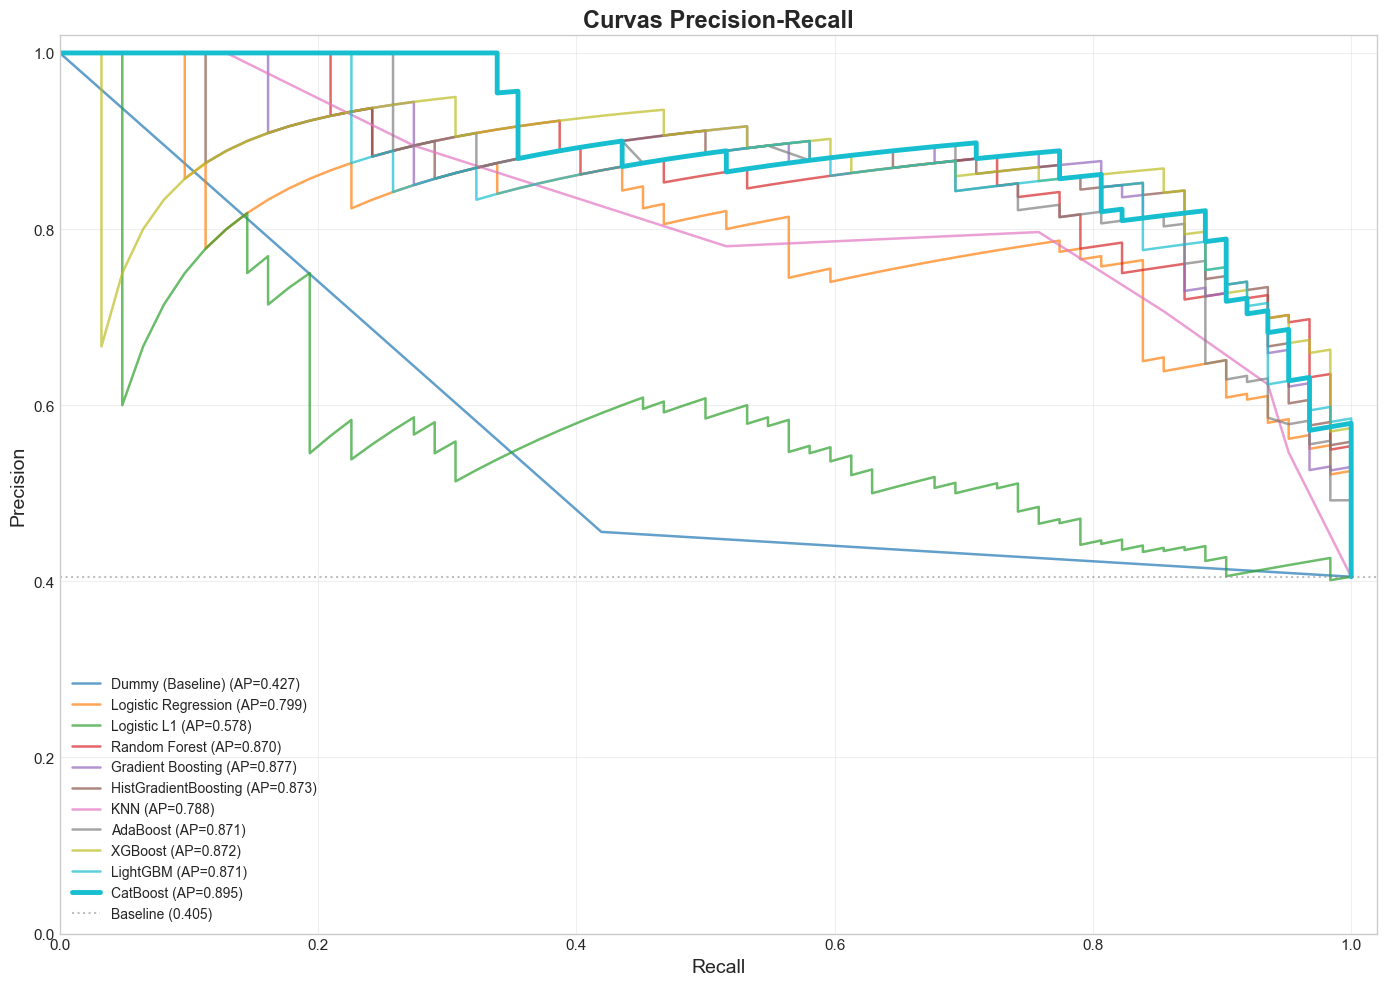

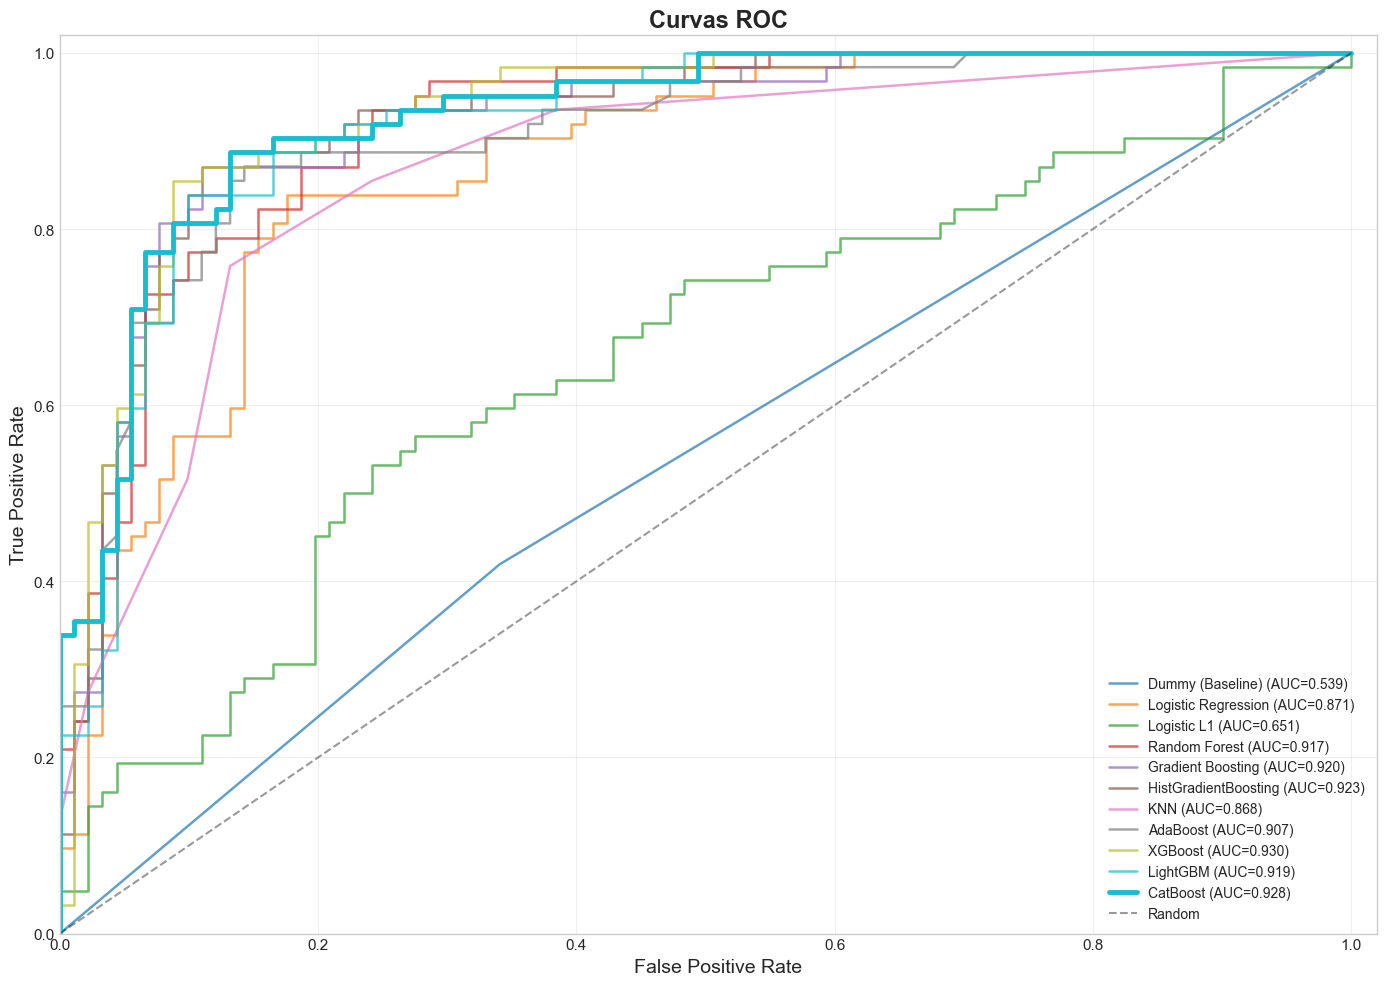

In [22]:
# ===== GRÁFICO 2: Curvas PR e ROC para todos os modelos =====
print("=" * 70)
print("📈 CURVAS PRECISION-RECALL E ROC")
print("=" * 70)

cmap = plt.cm.get_cmap('tab10')

# --- Precision-Recall Curves ---
fig, ax1 = plt.subplots(figsize=(14, 10))
for idx, (name, proba) in enumerate(probas.items()):
    precision_c, recall_c, _ = precision_recall_curve(y_test, proba)
    pr_auc = average_precision_score(y_test, proba)
    lw = 3.5 if name == best_model_name else 1.8
    alpha = 1.0 if name == best_model_name else 0.7
    ax1.plot(recall_c, precision_c, label=f'{name} (AP={pr_auc:.3f})',
             linewidth=lw, alpha=alpha, color=cmap(idx))

baseline_precision = y_test.mean()
ax1.axhline(y=baseline_precision, color='gray', linestyle=':', alpha=0.5, 
            label=f'Baseline ({baseline_precision:.3f})')
ax1.set_xlabel('Recall', fontsize=14)
ax1.set_ylabel('Precision', fontsize=14)
ax1.set_title('Curvas Precision-Recall', fontsize=17, fontweight='bold')
ax1.legend(loc='best', fontsize=10, framealpha=0.9)
ax1.set_xlim(0, 1.02)
ax1.set_ylim(0, 1.02)
ax1.grid(True, alpha=0.3)
ax1.tick_params(labelsize=11)
plt.tight_layout()
plt.show()

# --- ROC Curves ---
fig, ax2 = plt.subplots(figsize=(14, 10))
for idx, (name, proba) in enumerate(probas.items()):
    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = roc_auc_score(y_test, proba)
    lw = 3.5 if name == best_model_name else 1.8
    alpha = 1.0 if name == best_model_name else 0.7
    ax2.plot(fpr, tpr, label=f'{name} (AUC={roc_auc:.3f})',
             linewidth=lw, alpha=alpha, color=cmap(idx))

ax2.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random')
ax2.set_xlabel('False Positive Rate', fontsize=14)
ax2.set_ylabel('True Positive Rate', fontsize=14)
ax2.set_title('Curvas ROC', fontsize=17, fontweight='bold')
ax2.legend(loc='lower right', fontsize=10, framealpha=0.9)
ax2.set_xlim(0, 1.02)
ax2.set_ylim(0, 1.02)
ax2.grid(True, alpha=0.3)
ax2.tick_params(labelsize=11)
plt.tight_layout()
plt.savefig(ARTIFACTS_PATH / 'pr_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

📊 CONFUSION MATRICES — TOP 5 MODELOS


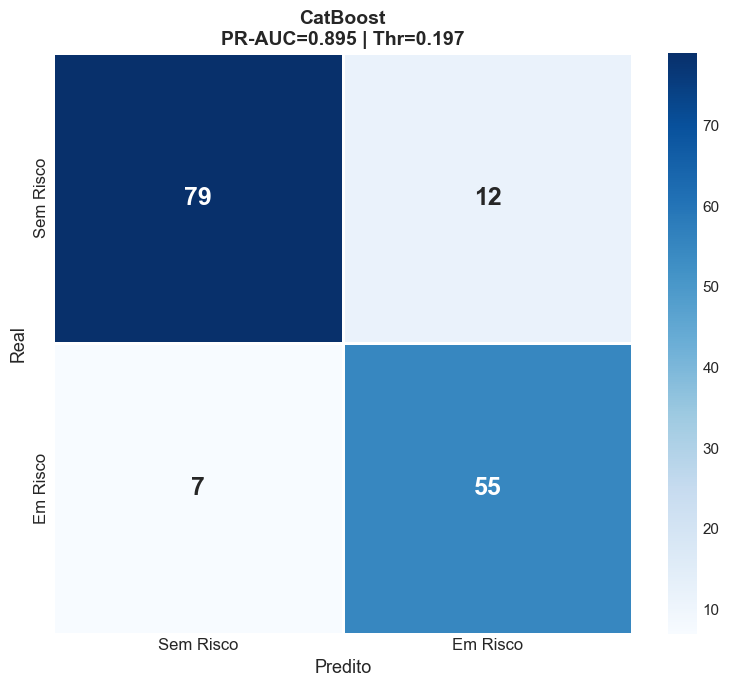

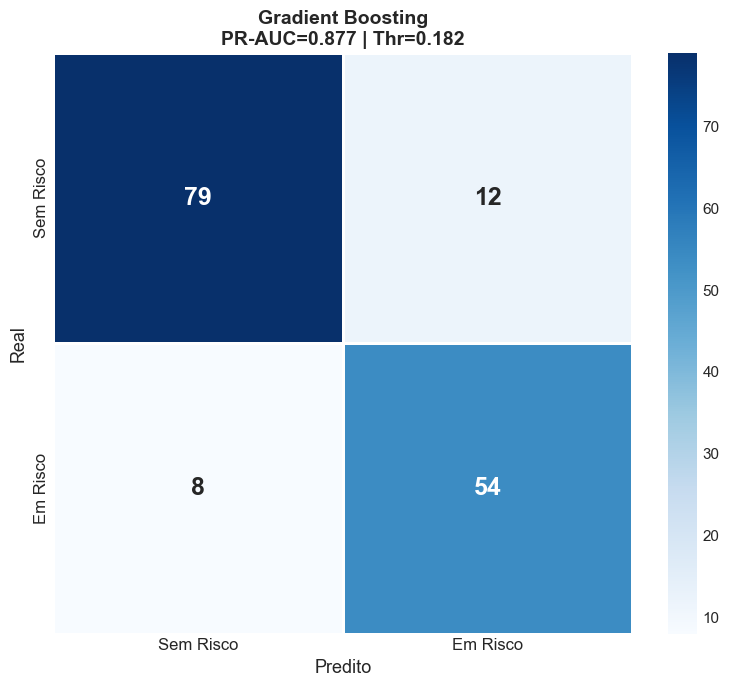

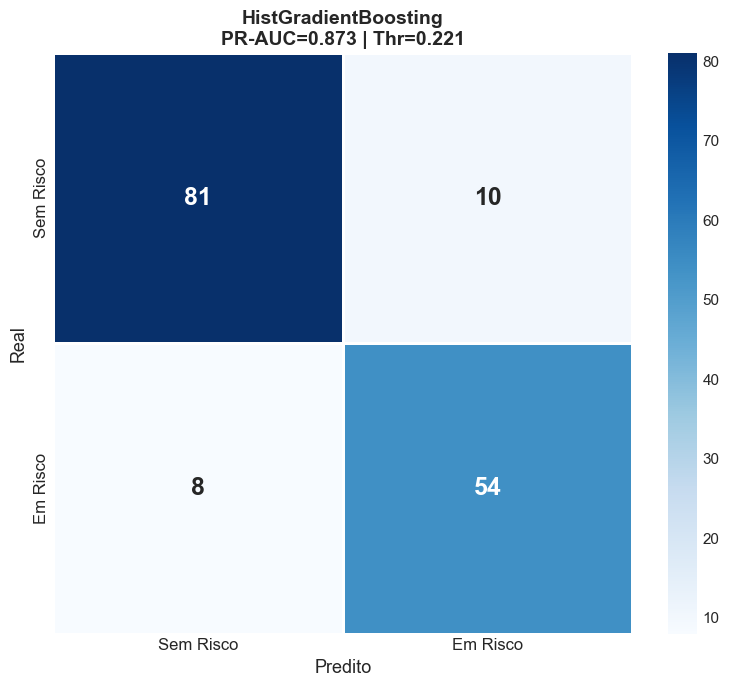

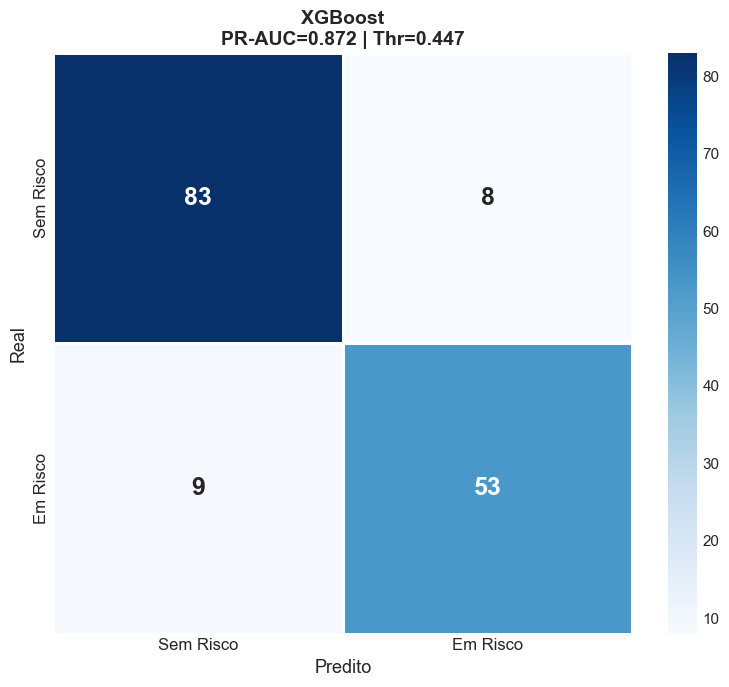

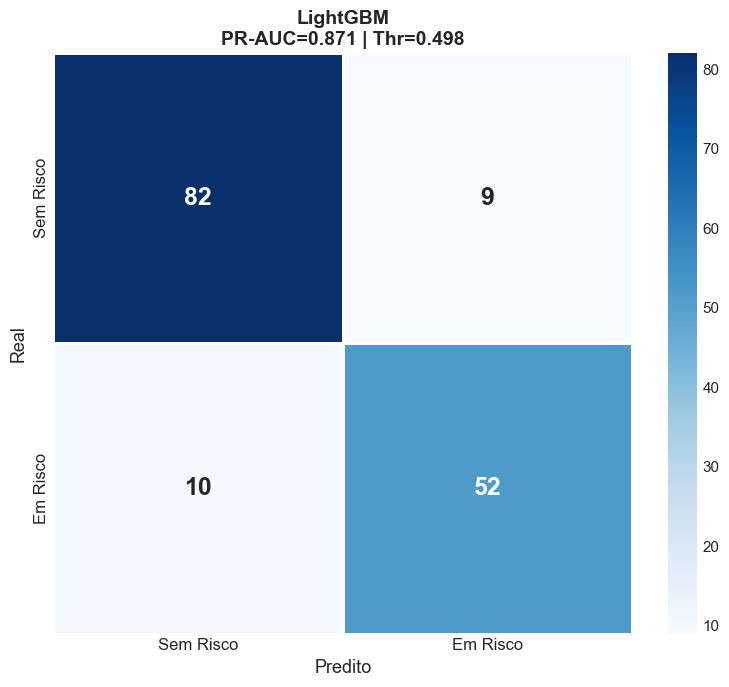

<Figure size 1400x600 with 0 Axes>

In [23]:
# ===== GRÁFICO 3: Confusion Matrices dos top modelos =====
print("=" * 70)
print("📊 CONFUSION MATRICES — TOP 5 MODELOS")
print("=" * 70)

top5 = results_df.head(5)['model'].tolist()

for name in top5:
    fig, ax = plt.subplots(figsize=(8, 7))
    proba = probas[name]
    threshold = results_df[results_df['model'] == name]['best_threshold'].values[0]
    y_pred_t = (proba >= threshold).astype(int)
    cm = confusion_matrix(y_test, y_pred_t)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Sem Risco', 'Em Risco'],
                yticklabels=['Sem Risco', 'Em Risco'],
                linewidths=2, linecolor='white',
                annot_kws={'fontsize': 18, 'fontweight': 'bold'})
    
    pr_auc = results_df[results_df['model'] == name]['pr_auc'].values[0]
    ax.set_title(f'{name}\nPR-AUC={pr_auc:.3f} | Thr={threshold:.3f}', 
                fontweight='bold', fontsize=14)
    ax.set_ylabel('Real', fontsize=13)
    ax.set_xlabel('Predito', fontsize=13)
    ax.tick_params(labelsize=12)
    plt.tight_layout()
    plt.show()

plt.savefig(ARTIFACTS_PATH / 'confusion_matrices.png', dpi=150, bbox_inches='tight')

📊 DISTRIBUIÇÃO DE PROBABILIDADES PREDITAS


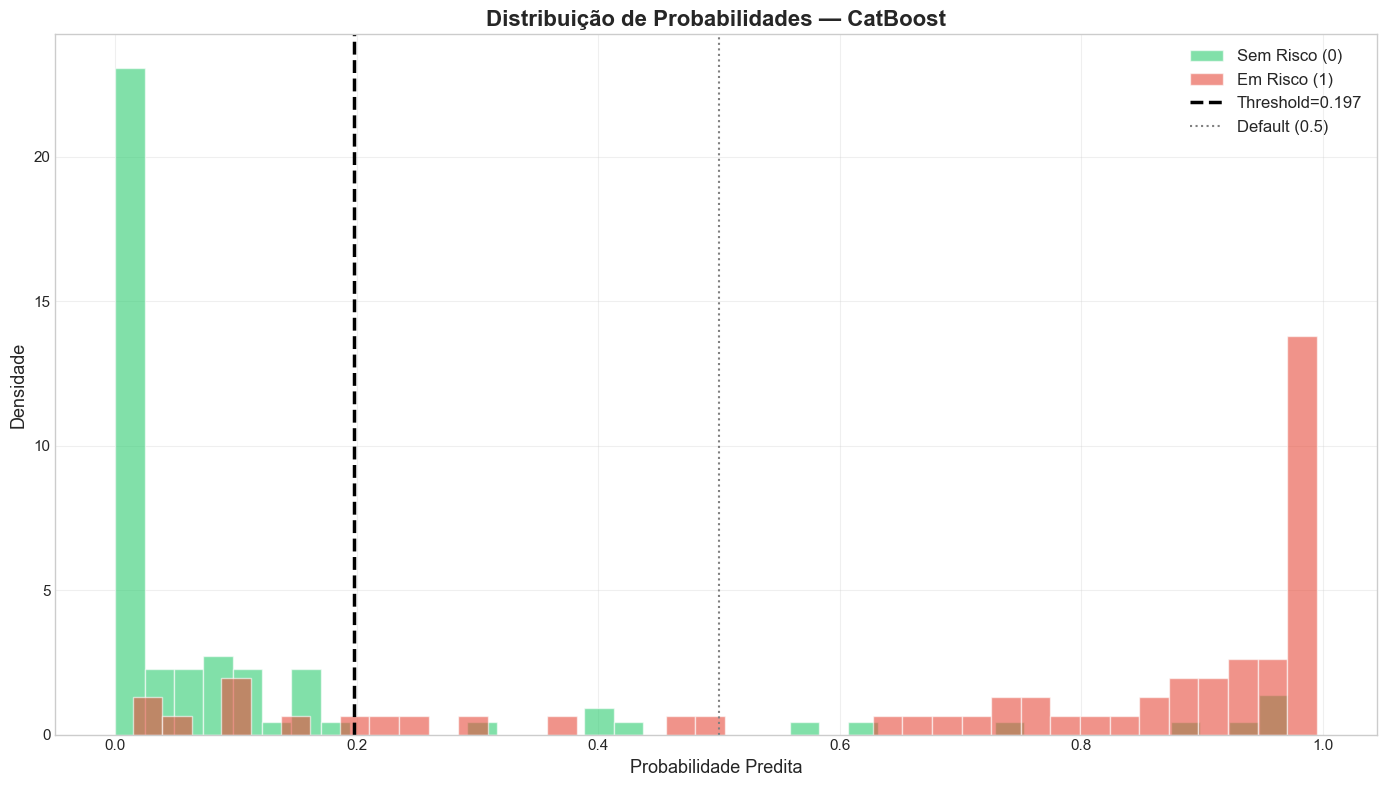

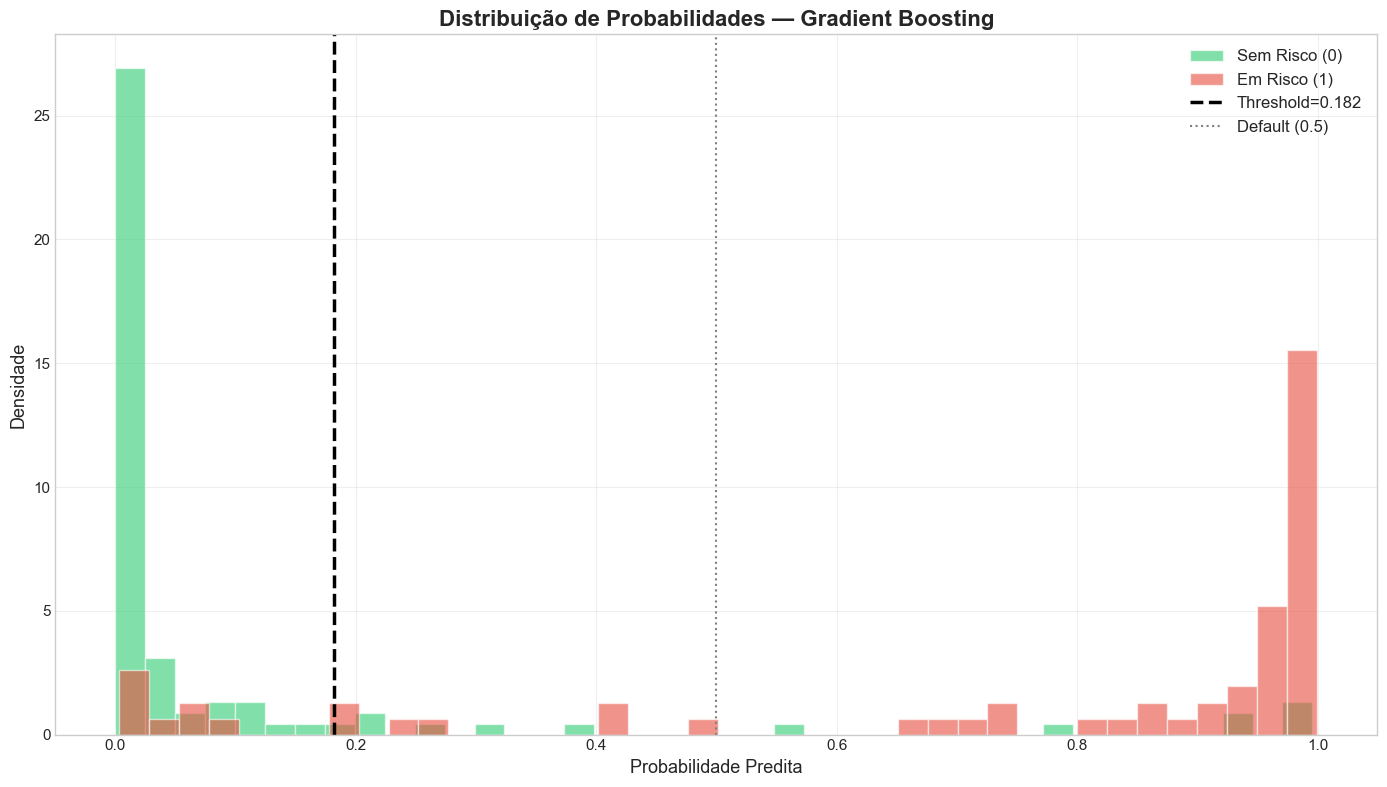

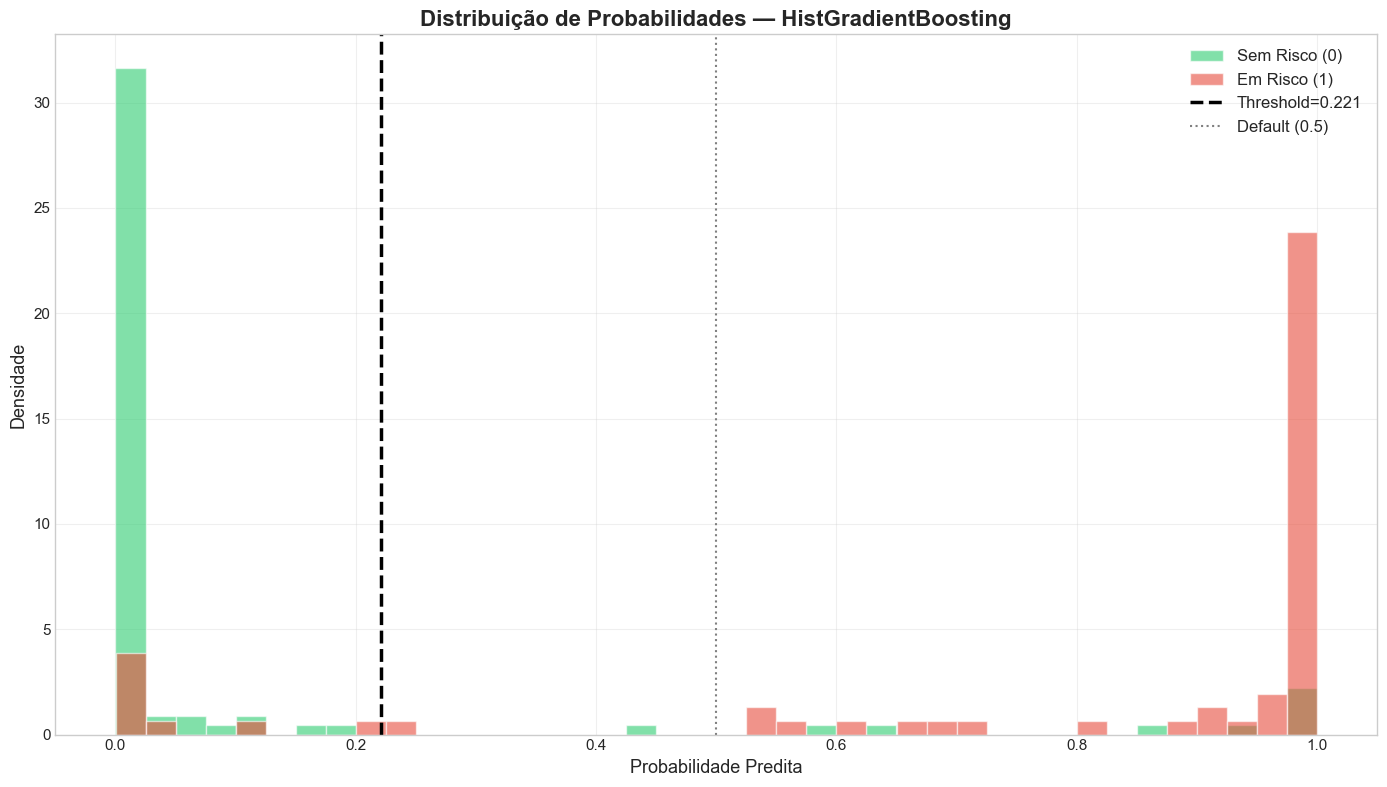

<Figure size 1400x600 with 0 Axes>

In [24]:
# ===== GRÁFICO 4: Distribuição de probabilidades =====
print("=" * 70)
print("📊 DISTRIBUIÇÃO DE PROBABILIDADES PREDITAS")
print("=" * 70)

top3 = results_df.head(3)['model'].tolist()

for name in top3:
    fig, ax = plt.subplots(figsize=(14, 8))
    proba = probas[name]
    threshold = results_df[results_df['model'] == name]['best_threshold'].values[0]
    
    ax.hist(proba[y_test == 0], bins=40, alpha=0.6, color=COLORS['success'], 
            label='Sem Risco (0)', density=True, edgecolor='white')
    ax.hist(proba[y_test == 1], bins=40, alpha=0.6, color=COLORS['danger'],
            label='Em Risco (1)', density=True, edgecolor='white')
    
    ax.axvline(x=threshold, color='black', linewidth=2.5, linestyle='--',
               label=f'Threshold={threshold:.3f}')
    ax.axvline(x=0.5, color='gray', linewidth=1.5, linestyle=':',
               label='Default (0.5)')
    
    ax.set_title(f'Distribuição de Probabilidades — {name}', fontweight='bold', fontsize=16)
    ax.set_xlabel('Probabilidade Predita', fontsize=13)
    ax.set_ylabel('Densidade', fontsize=13)
    ax.legend(fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.tick_params(labelsize=11)
    plt.tight_layout()
    plt.show()

plt.savefig(ARTIFACTS_PATH / 'probability_distributions.png', dpi=150, bbox_inches='tight')

📊 COMPARAÇÃO DETALHADA DE MÉTRICAS


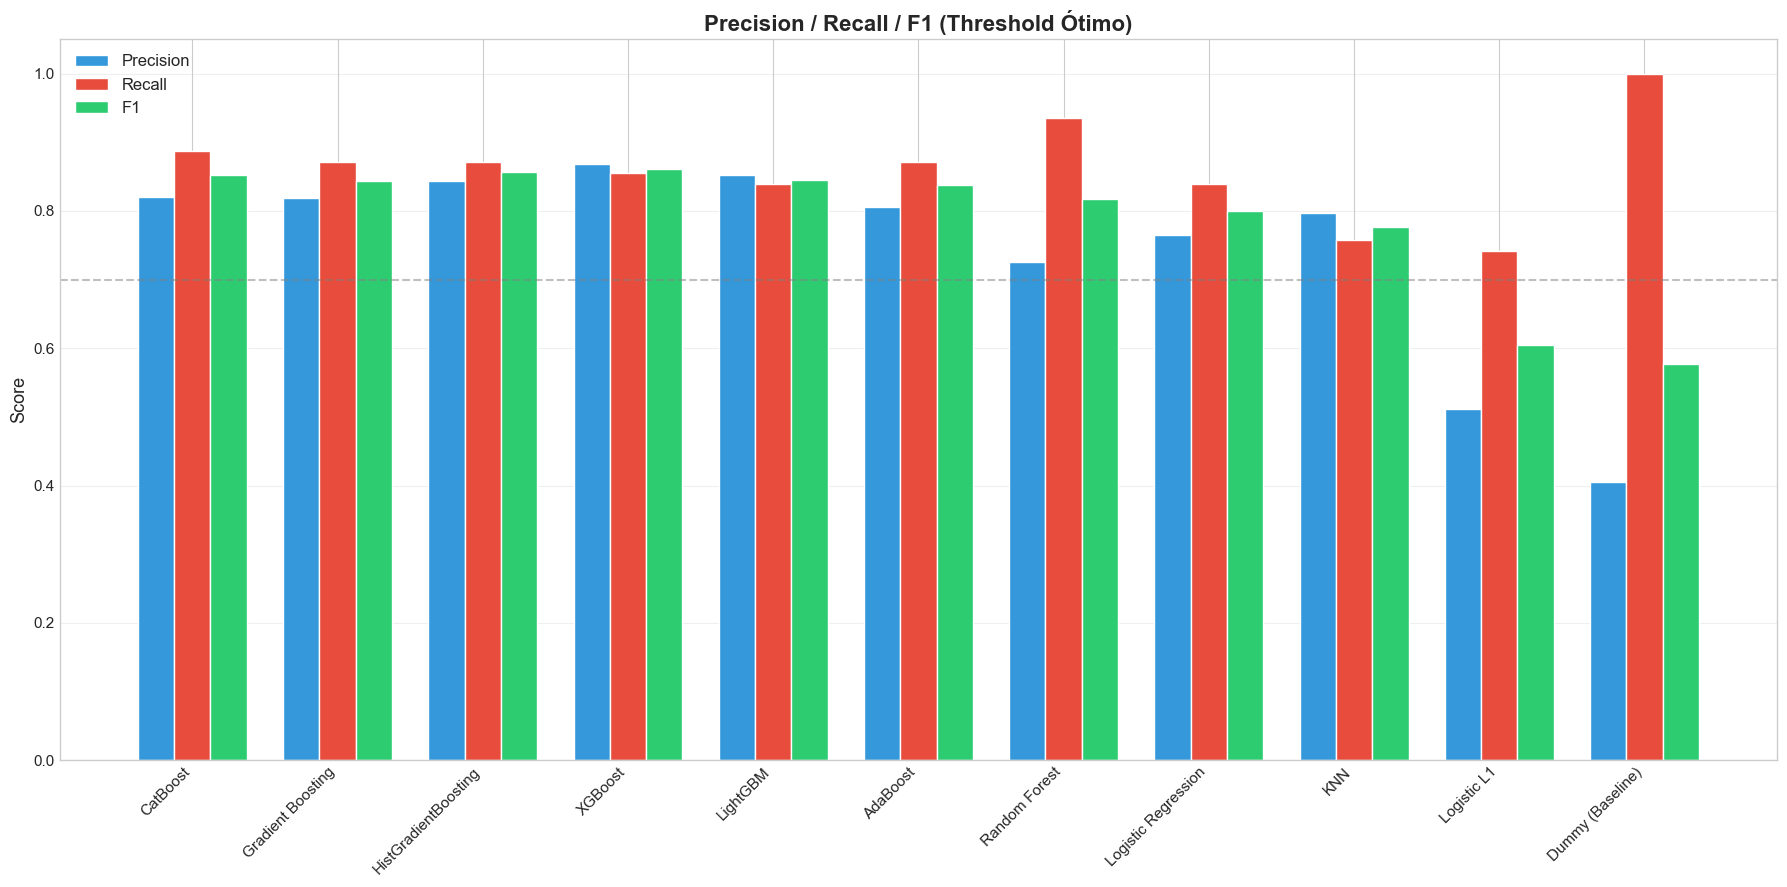

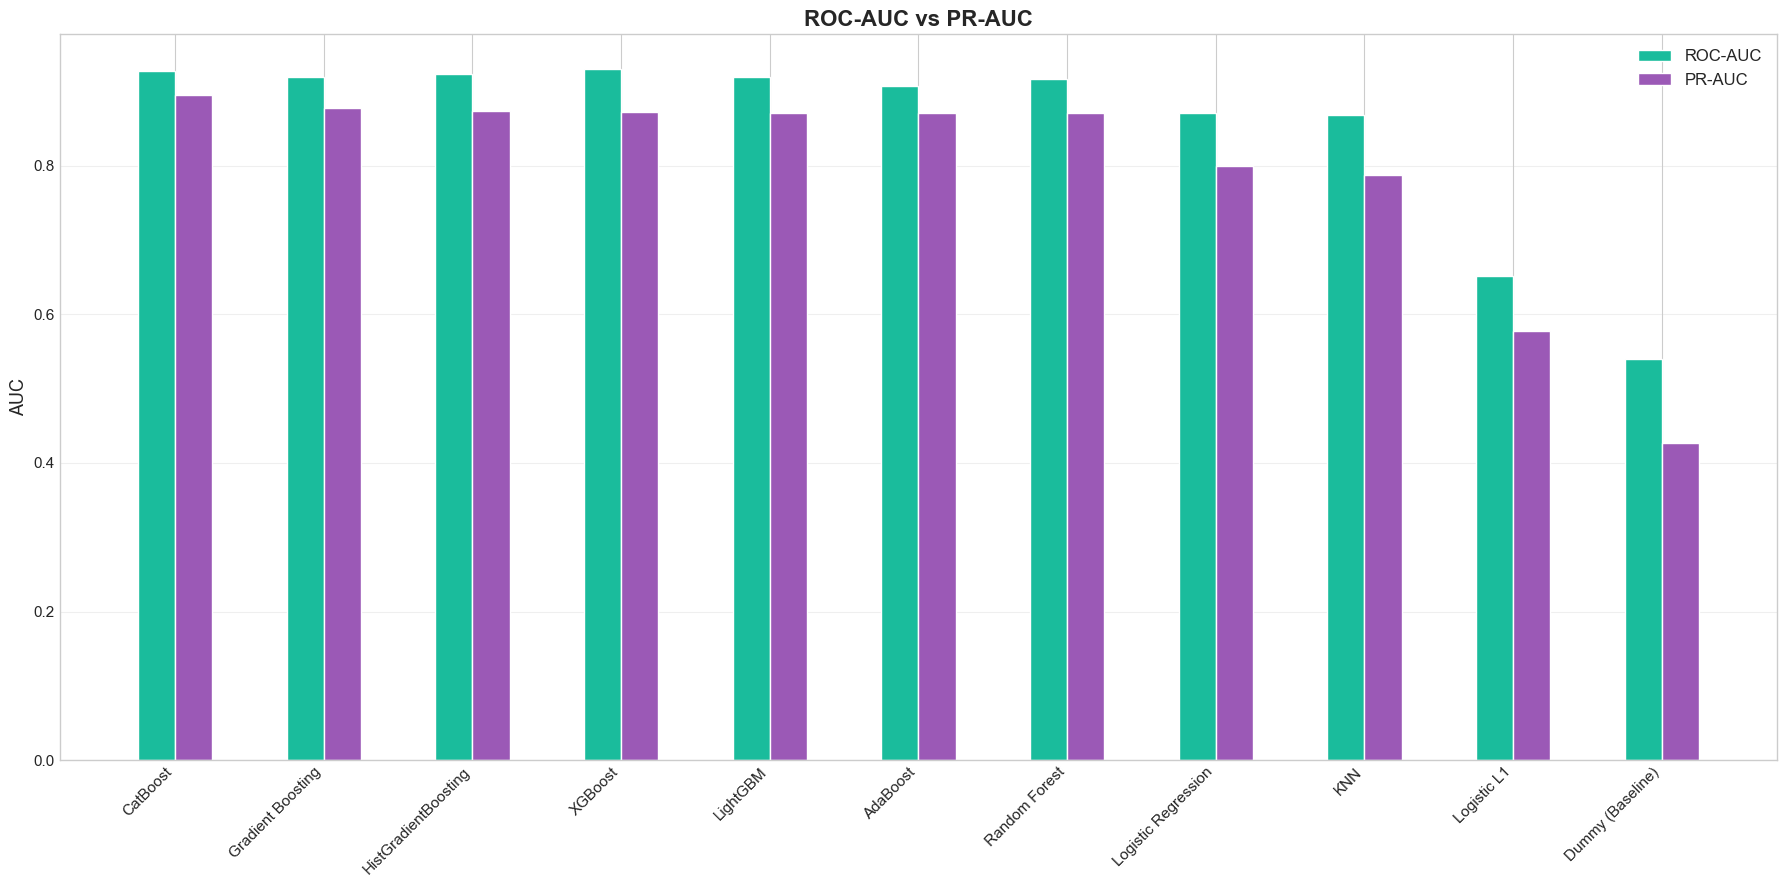

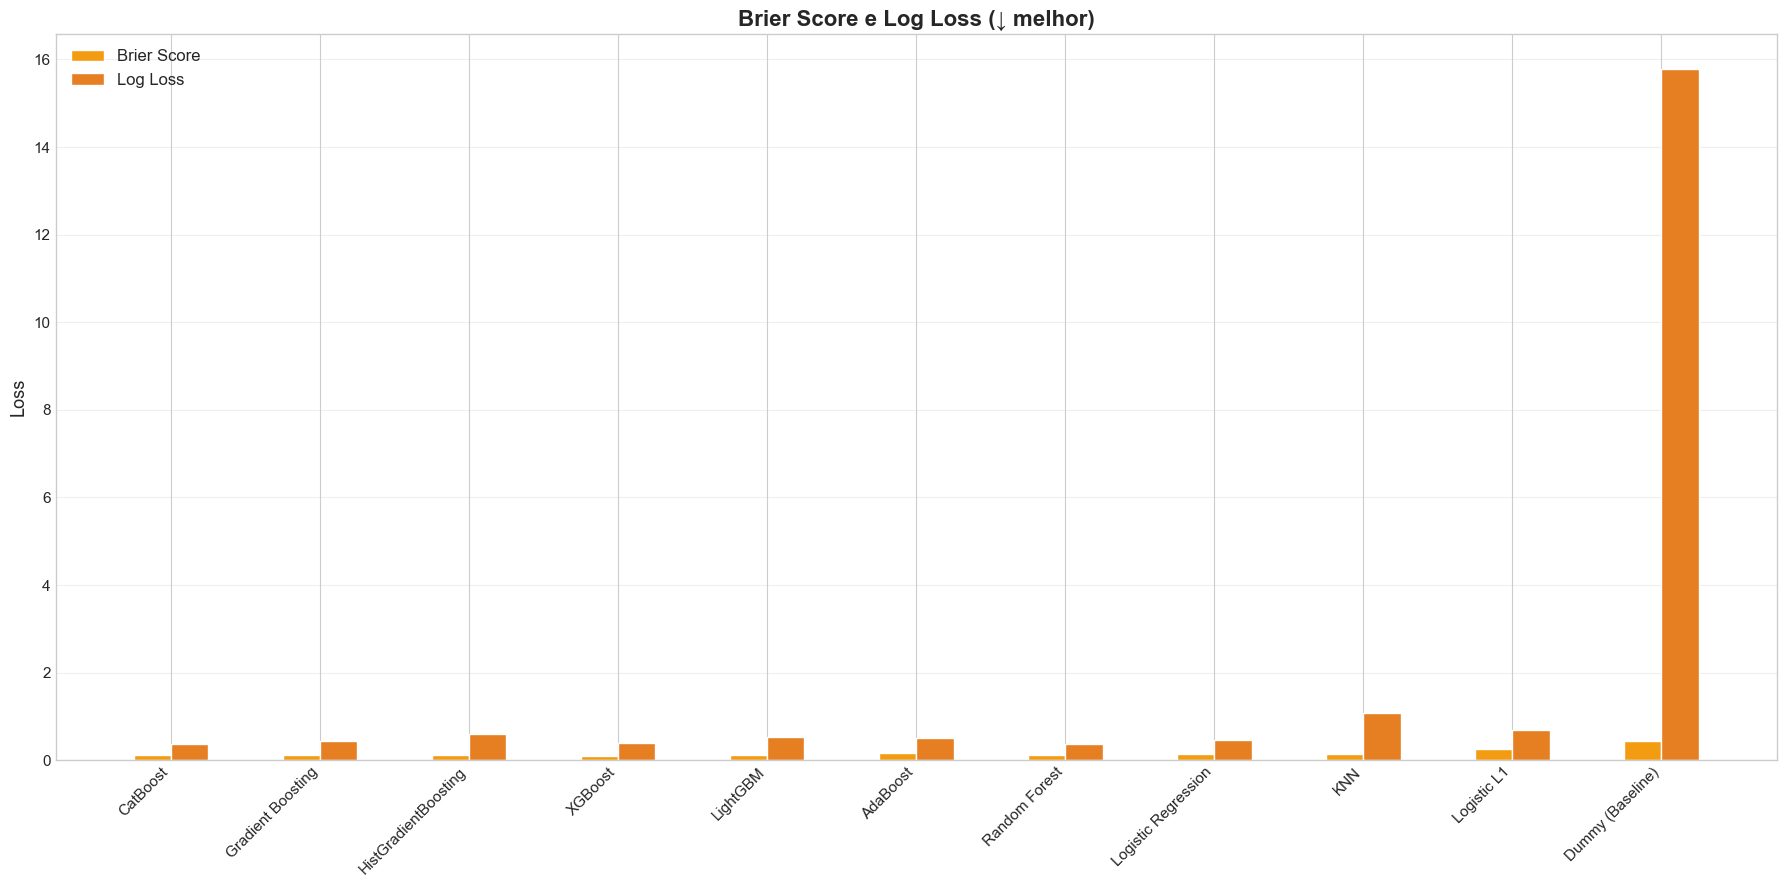

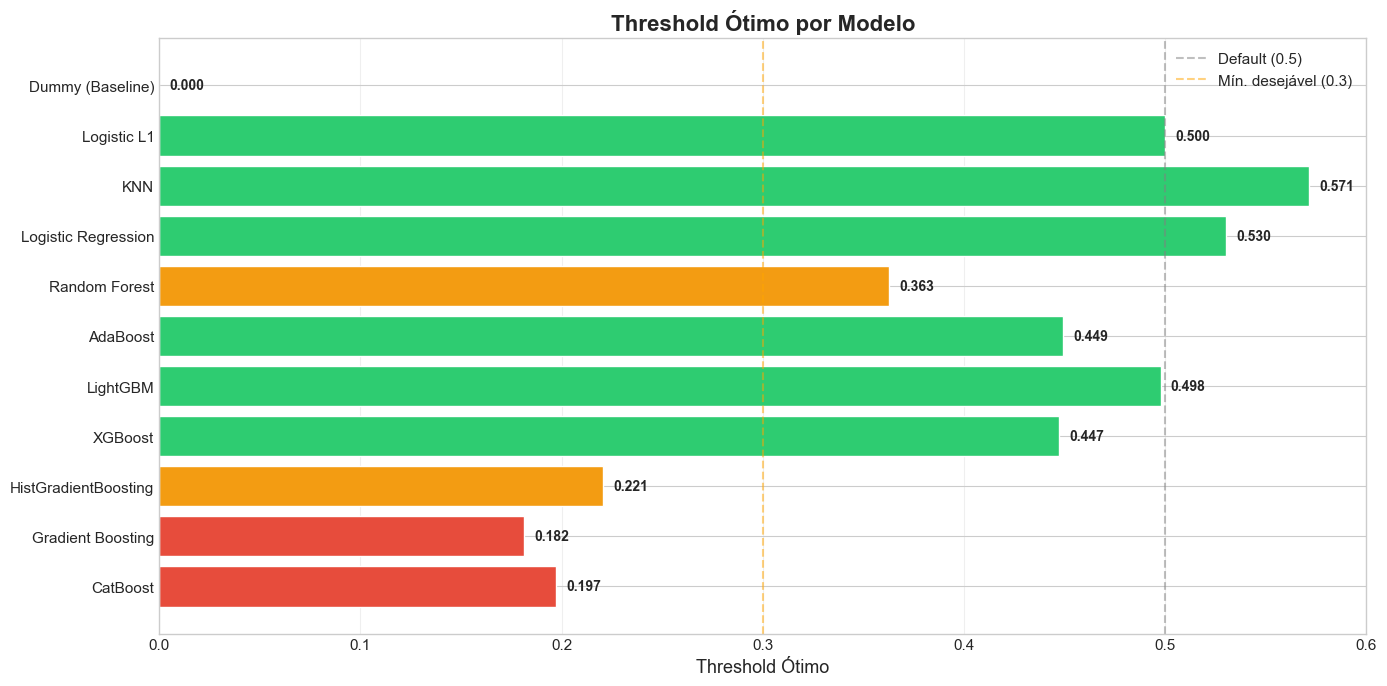

In [25]:
# ===== GRÁFICO 5: Comparação detalhada de métricas =====
print("=" * 70)
print("📊 COMPARAÇÃO DETALHADA DE MÉTRICAS")
print("=" * 70)

x = np.arange(len(results_df))
width = 0.25

# --- 5.1 Precision / Recall / F1 ---
fig, ax1 = plt.subplots(figsize=(18, 9))
ax1.bar(x - width, results_df['best_precision'], width, label='Precision', 
        color=COLORS['secondary'], edgecolor='white')
ax1.bar(x, results_df['best_recall'], width, label='Recall',
        color=COLORS['danger'], edgecolor='white')
ax1.bar(x + width, results_df['best_f1'], width, label='F1',
        color=COLORS['success'], edgecolor='white')
ax1.set_xticks(x)
ax1.set_xticklabels(results_df['model'], rotation=45, ha='right', fontsize=11)
ax1.set_ylabel('Score', fontsize=13)
ax1.set_title('Precision / Recall / F1 (Threshold Ótimo)', fontweight='bold', fontsize=16)
ax1.legend(fontsize=12)
ax1.axhline(y=0.7, color='gray', linestyle='--', alpha=0.5)
ax1.grid(True, alpha=0.3, axis='y')
ax1.tick_params(labelsize=11)
plt.tight_layout()
plt.show()

# --- 5.2 ROC-AUC vs PR-AUC ---
fig, ax2 = plt.subplots(figsize=(18, 9))
ax2.bar(x - width/2, results_df['roc_auc'], width, label='ROC-AUC',
        color=COLORS['info'], edgecolor='white')
ax2.bar(x + width/2, results_df['pr_auc'], width, label='PR-AUC',
        color=COLORS['purple'], edgecolor='white')
ax2.set_xticks(x)
ax2.set_xticklabels(results_df['model'], rotation=45, ha='right', fontsize=11)
ax2.set_ylabel('AUC', fontsize=13)
ax2.set_title('ROC-AUC vs PR-AUC', fontweight='bold', fontsize=16)
ax2.legend(fontsize=12)
ax2.grid(True, alpha=0.3, axis='y')
ax2.tick_params(labelsize=11)
plt.tight_layout()
plt.show()

# --- 5.3 Brier Score + Log Loss ---
fig, ax3 = plt.subplots(figsize=(18, 9))
ax3.bar(x - width/2, results_df['brier'], width, label='Brier Score',
        color=COLORS['warning'], edgecolor='white')
ax3.bar(x + width/2, results_df['log_loss'], width, label='Log Loss',
        color=COLORS['orange'], edgecolor='white')
ax3.set_xticks(x)
ax3.set_xticklabels(results_df['model'], rotation=45, ha='right', fontsize=11)
ax3.set_ylabel('Loss', fontsize=13)
ax3.set_title('Brier Score e Log Loss (↓ melhor)', fontweight='bold', fontsize=16)
ax3.legend(fontsize=12)
ax3.grid(True, alpha=0.3, axis='y')
ax3.tick_params(labelsize=11)
plt.tight_layout()
plt.show()

# --- 5.4 Threshold ótimo por modelo ---
fig, ax4 = plt.subplots(figsize=(14, max(7, len(results_df) * 0.6)))
colors_thresh = [COLORS['danger'] if t < 0.2 else COLORS['warning'] if t < 0.4 
                 else COLORS['success'] for t in results_df['best_threshold']]
ax4.barh(results_df['model'], results_df['best_threshold'], color=colors_thresh, edgecolor='white')
ax4.set_xlabel('Threshold Ótimo', fontsize=13)
ax4.set_title('Threshold Ótimo por Modelo', fontweight='bold', fontsize=16)
ax4.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label='Default (0.5)')
ax4.axvline(x=0.3, color='orange', linestyle='--', alpha=0.5, label='Mín. desejável (0.3)')
ax4.legend(fontsize=11)
ax4.tick_params(labelsize=11)
ax4.grid(True, alpha=0.3, axis='x')
for i, (_, row) in enumerate(results_df.iterrows()):
    ax4.text(row['best_threshold'] + 0.005, i, f"{row['best_threshold']:.3f}", 
             va='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig(ARTIFACTS_PATH / 'detailed_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

📊 LEARNING CURVES — CatBoost
✅ Learning curves calculadas com sucesso


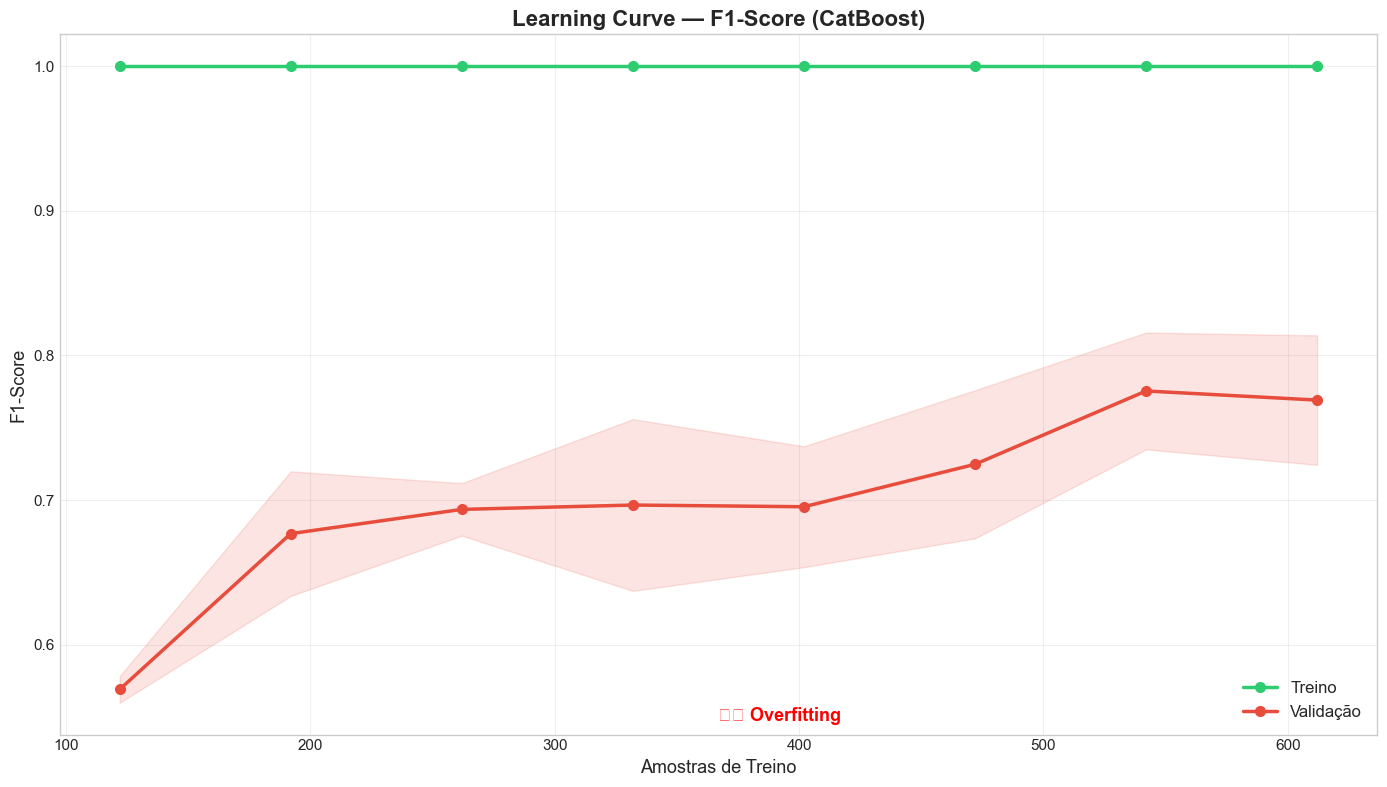

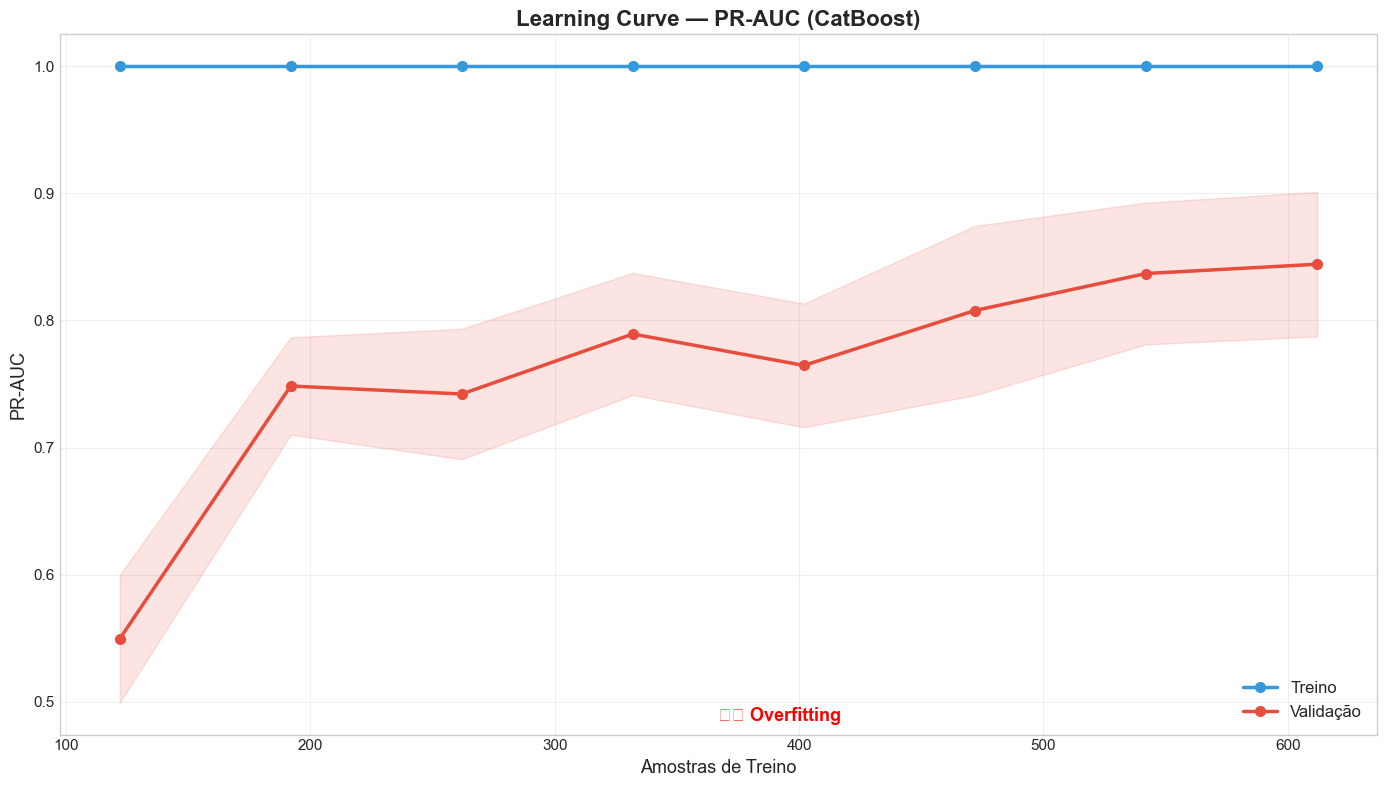

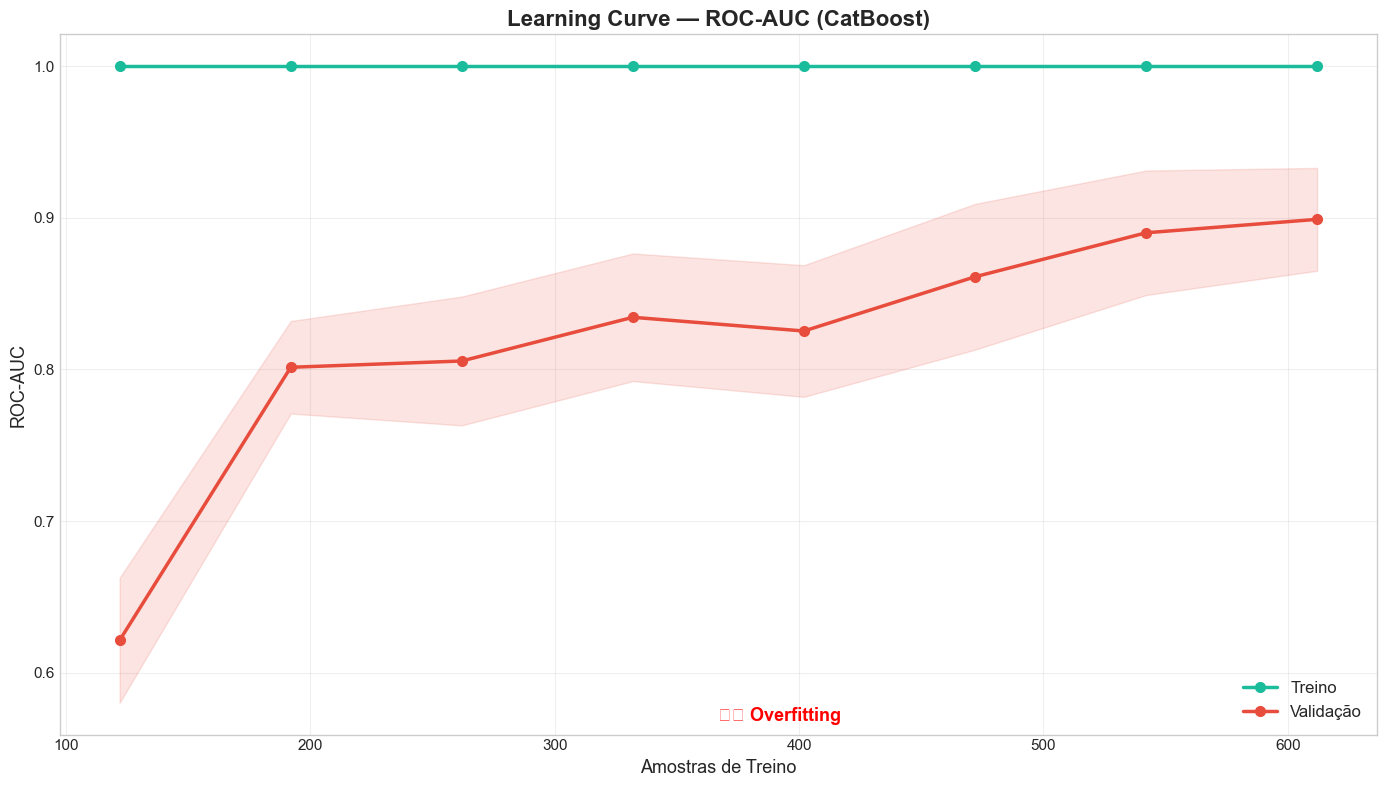

In [26]:
# ===== GRÁFICO 6: Learning Curves do melhor modelo =====
print("=" * 70)
print(f"📊 LEARNING CURVES — {best_model_name}")
print("=" * 70)

from catboost import CatBoostClassifier as _CBC
from sklearn.utils import resample

scoring_metrics = ['f1', 'average_precision', 'roc_auc']
scoring_labels = ['F1-Score', 'PR-AUC', 'ROC-AUC']
scoring_colors = [COLORS['success'], COLORS['secondary'], COLORS['info']]

# Parâmetros limpos do CatBoost (sem synonyms conflitantes)
_cb_base_params = best_model.get_params()
# CatBoost tem synonyms que conflitam: remover duplicatas
_synonym_groups = [
    ('random_seed', 'random_state'),
    ('depth', 'max_depth'),
    ('rsm', 'colsample_bylevel'),
    ('l2_leaf_reg', 'reg_lambda'),
    ('iterations', 'n_estimators', 'num_boost_round', 'num_trees'),
    ('learning_rate', 'eta'),
    ('border_count', 'max_bin'),
]
for group in _synonym_groups:
    found = [k for k in group if k in _cb_base_params and _cb_base_params[k] is not None]
    if len(found) > 1:
        for k in found[1:]:
            del _cb_base_params[k]

_cb_base_params['verbose'] = 0

# Learning curve manual (evita sklearn clone)
train_fracs = np.linspace(0.2, 1.0, 8)
cv_lc = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

lc_results = {m: [] for m in scoring_metrics}

for fold_idx, (train_idx, val_idx) in enumerate(cv_lc.split(X_scaled, y)):
    X_fold_train, X_fold_val = X_scaled.iloc[train_idx], X_scaled.iloc[val_idx]
    y_fold_train, y_fold_val = y.iloc[train_idx], y.iloc[val_idx]
    
    for frac in train_fracs:
        n_samples = max(int(len(X_fold_train) * frac), 10)
        
        X_sub = X_fold_train.iloc[:n_samples]
        y_sub = y_fold_train.iloc[:n_samples]
        
        m = _CBC(**_cb_base_params)
        m.fit(X_sub, y_sub)
        
        proba_train = m.predict_proba(X_sub)[:, 1]
        proba_val = m.predict_proba(X_fold_val)[:, 1]
        pred_train = (proba_train >= 0.5).astype(int)
        pred_val = (proba_val >= 0.5).astype(int)
        
        for metric in scoring_metrics:
            if metric == 'f1':
                s_train = f1_score(y_sub, pred_train, zero_division=0)
                s_val = f1_score(y_fold_val, pred_val, zero_division=0)
            elif metric == 'average_precision':
                s_train = average_precision_score(y_sub, proba_train)
                s_val = average_precision_score(y_fold_val, proba_val)
            elif metric == 'roc_auc':
                s_train = roc_auc_score(y_sub, proba_train)
                s_val = roc_auc_score(y_fold_val, proba_val)
            
            lc_results[metric].append((n_samples, fold_idx, s_train, s_val))

print("✅ Learning curves calculadas com sucesso")

for metric, label, color in zip(scoring_metrics, scoring_labels, scoring_colors):
    fig, ax = plt.subplots(figsize=(14, 8))
    
    df_lc = pd.DataFrame(lc_results[metric], columns=['size', 'fold', 'train_score', 'val_score'])
    
    sizes = sorted(df_lc['size'].unique())
    train_mean = [df_lc[df_lc['size'] == s]['train_score'].mean() for s in sizes]
    train_std = [df_lc[df_lc['size'] == s]['train_score'].std() for s in sizes]
    val_mean = [df_lc[df_lc['size'] == s]['val_score'].mean() for s in sizes]
    val_std = [df_lc[df_lc['size'] == s]['val_score'].std() for s in sizes]
    
    sizes = np.array(sizes)
    train_mean, train_std = np.array(train_mean), np.array(train_std)
    val_mean, val_std = np.array(val_mean), np.array(val_std)
    
    ax.fill_between(sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color=color)
    ax.fill_between(sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color=COLORS['danger'])
    ax.plot(sizes, train_mean, 'o-', color=color, linewidth=2.5, label='Treino', markersize=7)
    ax.plot(sizes, val_mean, 'o-', color=COLORS['danger'], linewidth=2.5, label='Validação', markersize=7)
    
    ax.set_title(f'Learning Curve — {label} ({best_model_name})', fontweight='bold', fontsize=16)
    ax.set_xlabel('Amostras de Treino', fontsize=13)
    ax.set_ylabel(label, fontsize=13)
    ax.legend(fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.tick_params(labelsize=11)
    
    gap = train_mean[-1] - val_mean[-1]
    if gap > 0.1:
        ax.annotate('⚠️ Overfitting', xy=(0.5, 0.02), xycoords='axes fraction',
                   fontsize=13, color='red', fontweight='bold')
    elif val_mean[-1] < 0.6:
        ax.annotate('⚠️ Underfitting', xy=(0.5, 0.02), xycoords='axes fraction',
                   fontsize=13, color='orange', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(ARTIFACTS_PATH / 'learning_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

📊 CURVAS DET E ANÁLISE DE THRESHOLD MULTI-MODELO


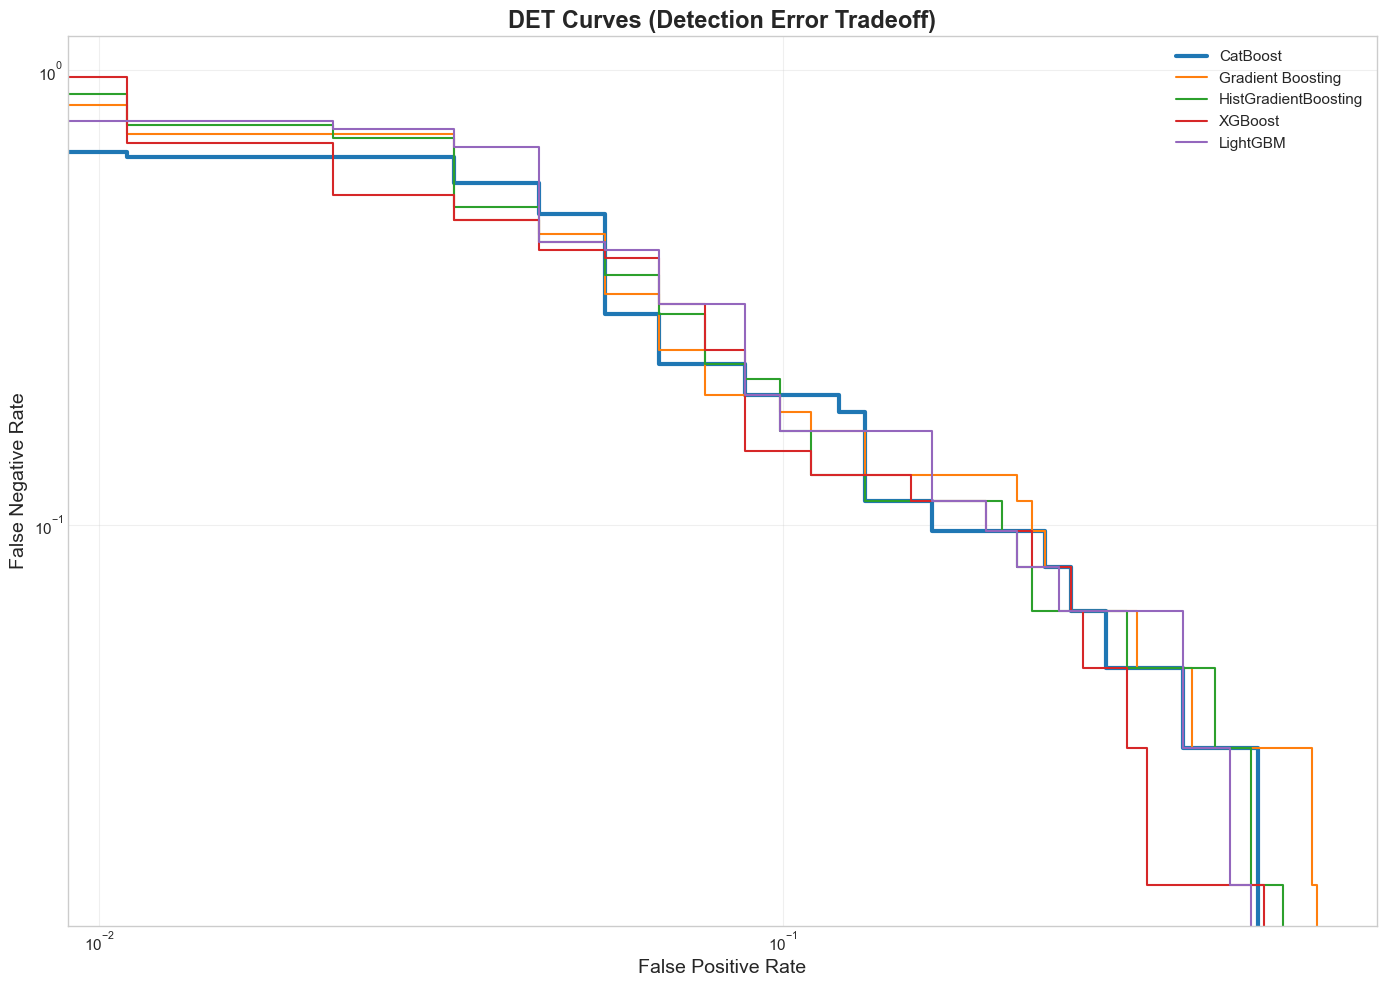

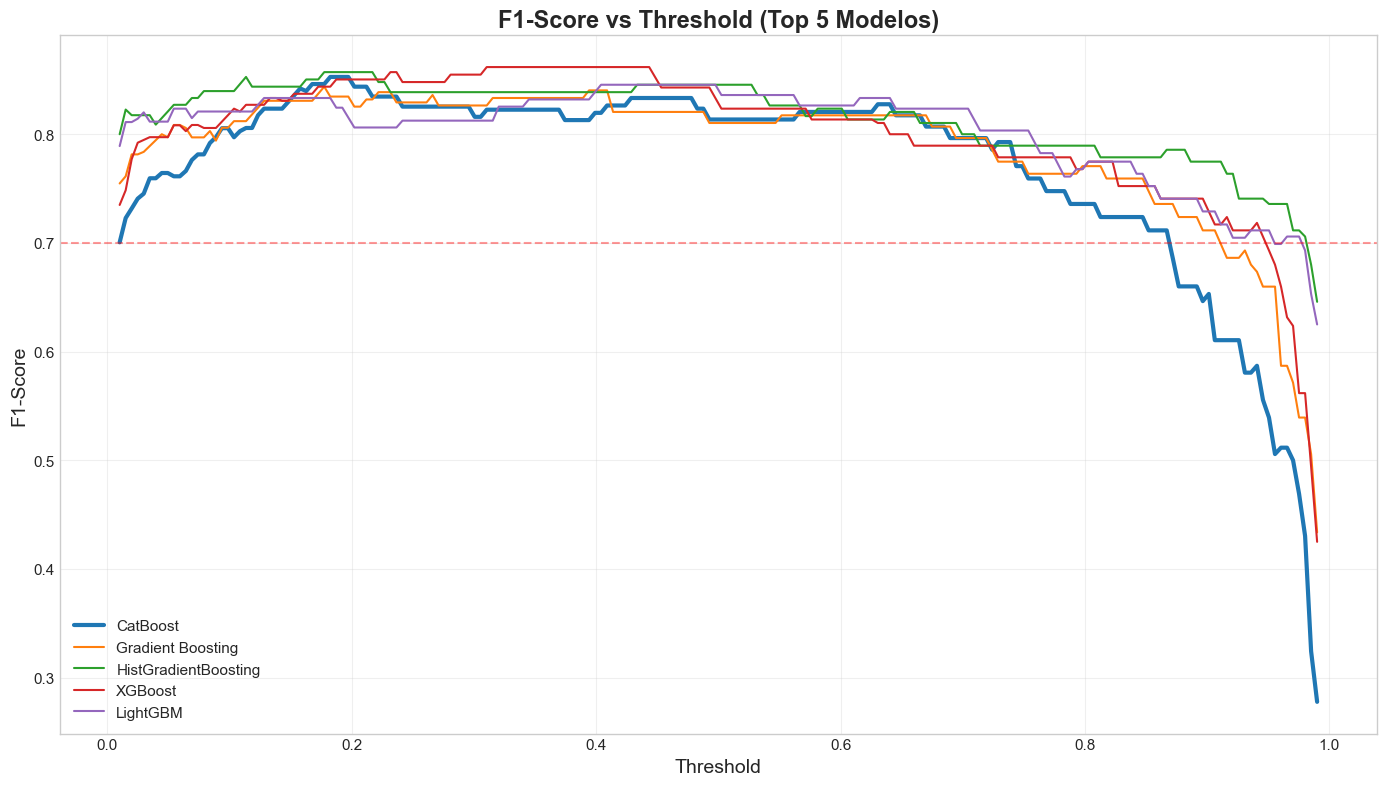

In [27]:
# ===== GRÁFICO 7: DET Curve & Curvas de Threshold Multi-modelo =====
print("=" * 70)
print("📊 CURVAS DET E ANÁLISE DE THRESHOLD MULTI-MODELO")
print("=" * 70)

# --- DET Curves ---
fig, ax1 = plt.subplots(figsize=(14, 10))
for idx, name in enumerate(top5):
    proba = probas[name]
    fpr, fnr, _ = det_curve(y_test, proba)
    ax1.plot(fpr, fnr, label=name, linewidth=3 if name == best_model_name else 1.5,
             color=cmap(idx))
ax1.set_xlabel('False Positive Rate', fontsize=14)
ax1.set_ylabel('False Negative Rate', fontsize=14)
ax1.set_title('DET Curves (Detection Error Tradeoff)', fontweight='bold', fontsize=17)
ax1.legend(fontsize=11)
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3)
ax1.tick_params(labelsize=11)
plt.tight_layout()
plt.show()

# --- Multi-model threshold analysis ---
fig, ax2 = plt.subplots(figsize=(14, 8))
thresholds_range = np.linspace(0.01, 0.99, 200)
for idx, name in enumerate(top5):
    proba = probas[name]
    f1_vals = [f1_score(y_test, (proba >= t).astype(int), zero_division=0) for t in thresholds_range]
    ax2.plot(thresholds_range, f1_vals, label=name, 
             linewidth=3 if name == best_model_name else 1.5, color=cmap(idx))

ax2.set_xlabel('Threshold', fontsize=14)
ax2.set_ylabel('F1-Score', fontsize=14)
ax2.set_title('F1-Score vs Threshold (Top 5 Modelos)', fontweight='bold', fontsize=17)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0.7, color='red', linestyle='--', alpha=0.4, label='Meta 0.70')
ax2.tick_params(labelsize=11)
plt.tight_layout()
plt.savefig(ARTIFACTS_PATH / 'det_threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Análise de Feature Importance <a id="9-features"></a>

📊 FEATURE IMPORTANCE


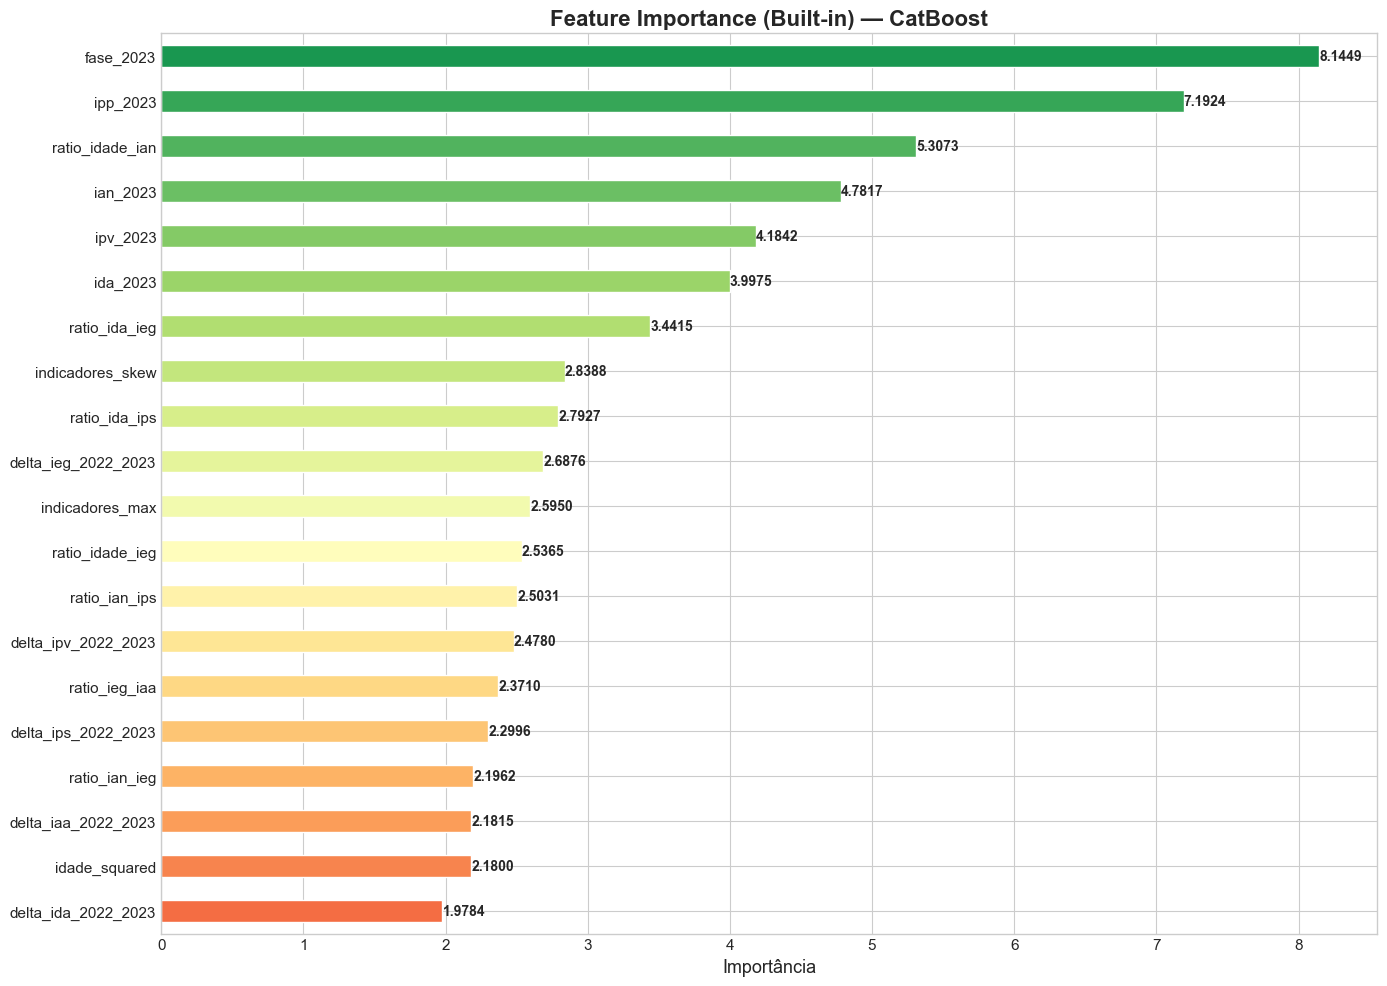

🔄 Calculando Permutation Importance (pode demorar)...


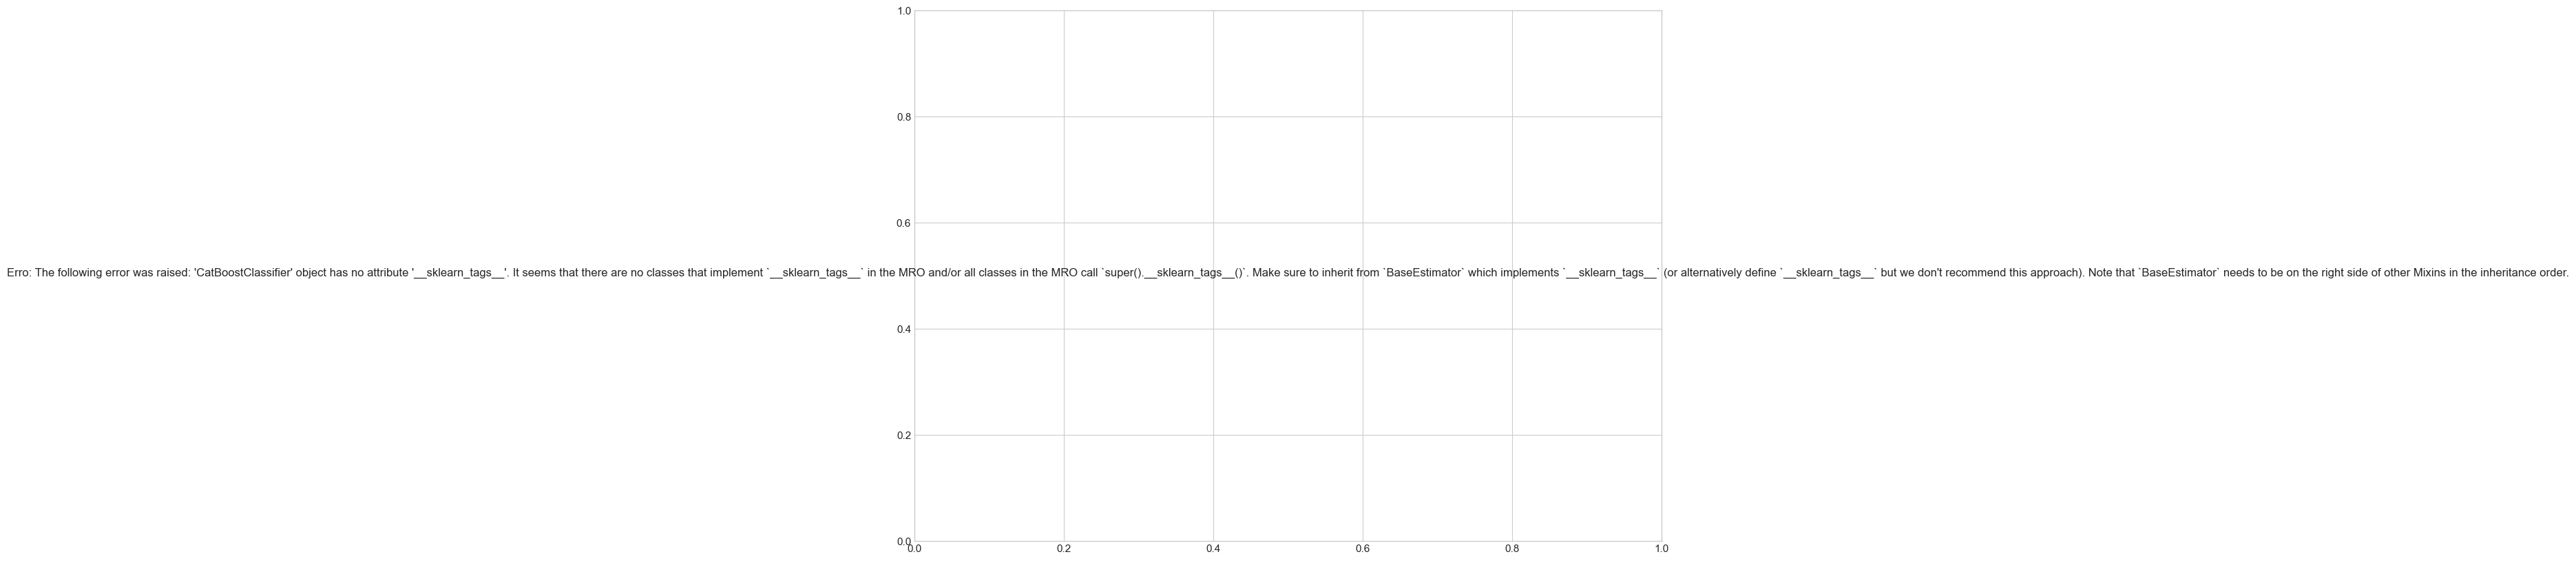

In [28]:
# ===== GRÁFICO 8: Feature Importance =====
print("=" * 70)
print("📊 FEATURE IMPORTANCE")
print("=" * 70)

# --- 8.1 Feature Importance nativa ---
fig, ax1 = plt.subplots(figsize=(14, 10))
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    feat_imp = pd.Series(importances, index=X_train.columns).sort_values(ascending=True)
    top_feat = feat_imp.tail(20)
    
    colors_imp = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(top_feat)))
    top_feat.plot(kind='barh', ax=ax1, color=colors_imp, edgecolor='white')
    ax1.set_title(f'Feature Importance (Built-in) — {best_model_name}', fontweight='bold', fontsize=16)
    ax1.set_xlabel('Importância', fontsize=13)
    ax1.tick_params(labelsize=11)
    for i, (feat_name, val) in enumerate(top_feat.items()):
        ax1.text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=10, fontweight='bold')
else:
    ax1.text(0.5, 0.5, 'Modelo sem feature_importances_ nativo', 
             transform=ax1.transAxes, ha='center', fontsize=14)
    ax1.set_title('Feature Importance (não disponível)', fontweight='bold', fontsize=16)
plt.tight_layout()
plt.show()

# --- 8.2 Permutation Importance ---
fig, ax2 = plt.subplots(figsize=(14, 10))
print("🔄 Calculando Permutation Importance (pode demorar)...")
try:
    perm_imp = permutation_importance(
        best_model, X_test, y_test, 
        n_repeats=10, random_state=SEED, scoring='average_precision',
        n_jobs=-1
    )
    perm_imp_df = pd.Series(perm_imp.importances_mean, index=X_test.columns).sort_values(ascending=True)
    top_perm = perm_imp_df.tail(20)
    
    colors_perm = plt.cm.RdYlBu_r(np.linspace(0.2, 0.9, len(top_perm)))
    top_perm.plot(kind='barh', ax=ax2, color=colors_perm, edgecolor='white')
    ax2.set_title('Permutation Importance (PR-AUC)', fontweight='bold', fontsize=16)
    ax2.set_xlabel('Redução média em PR-AUC', fontsize=13)
    ax2.tick_params(labelsize=11)
    for i, (feat_name, val) in enumerate(top_perm.items()):
        ax2.text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=10, fontweight='bold')
except Exception as e:
    ax2.text(0.5, 0.5, f'Erro: {e}', transform=ax2.transAxes, ha='center', fontsize=12)

plt.tight_layout()
plt.savefig(ARTIFACTS_PATH / 'feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

📊 SHAP VALUES — INTERPRETABILIDADE


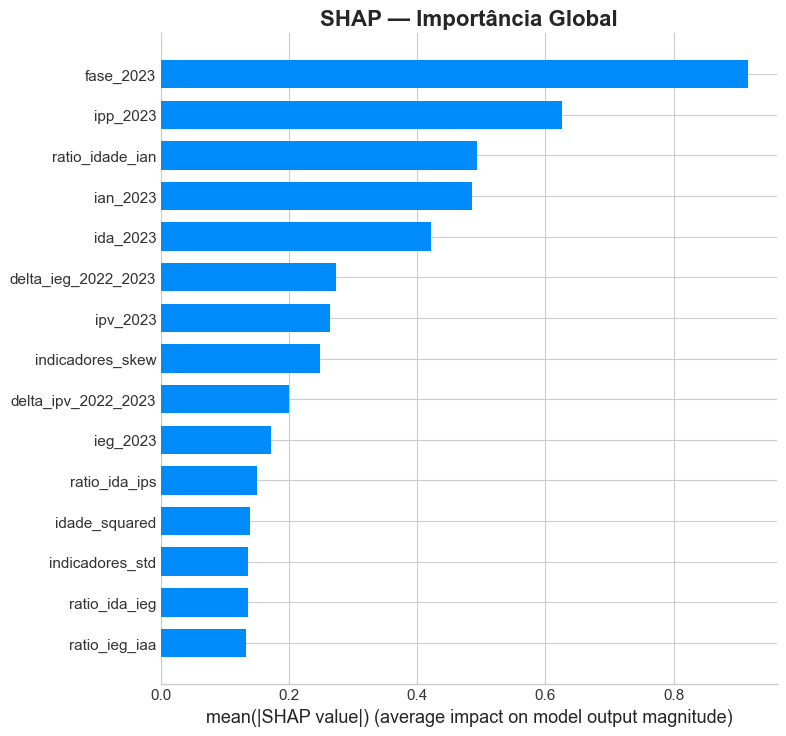

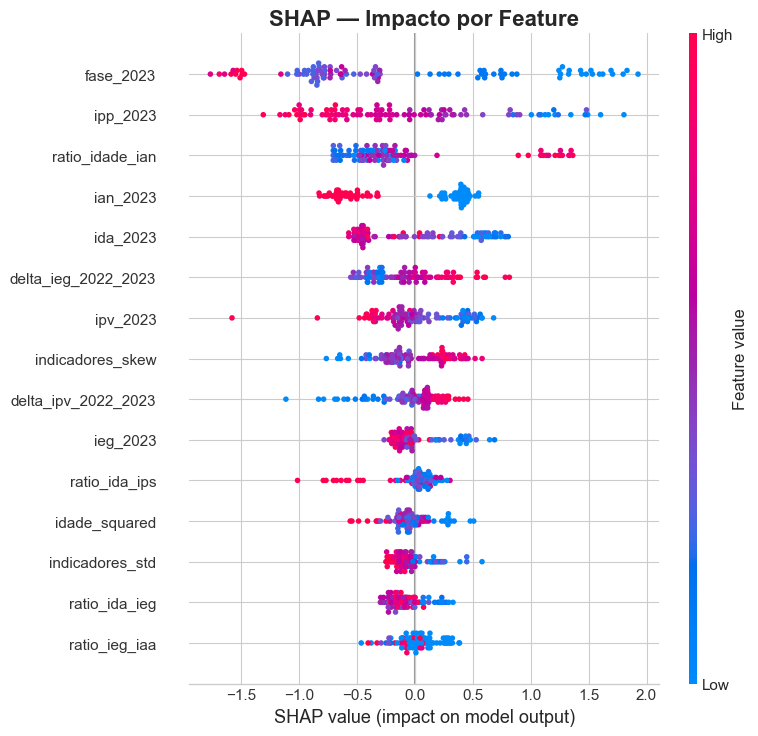

In [29]:
# ===== GRÁFICO 9: SHAP Values (se disponível) =====
if HAS_SHAP:
    print("=" * 70)
    print("📊 SHAP VALUES — INTERPRETABILIDADE")
    print("=" * 70)
    
    try:
        n_sample = min(100, len(X_test))
        X_shap = X_test.iloc[:n_sample]
        
        explainer = shap.TreeExplainer(best_model)
        shap_values = explainer.shap_values(X_shap)
        
        if isinstance(shap_values, list):
            shap_values = shap_values[1]
        
        # --- SHAP Bar (importância global) ---
        fig, ax = plt.subplots(figsize=(14, 10))
        plt.sca(ax)
        shap.summary_plot(shap_values, X_shap, plot_type='bar', show=False, max_display=15)
        ax.set_title('SHAP — Importância Global', fontweight='bold', fontsize=16)
        ax.tick_params(labelsize=11)
        plt.tight_layout()
        plt.show()
        
        # --- SHAP Beeswarm (impacto por feature) ---
        fig, ax = plt.subplots(figsize=(14, 10))
        plt.sca(ax)
        shap.summary_plot(shap_values, X_shap, show=False, max_display=15)
        ax.set_title('SHAP — Impacto por Feature', fontweight='bold', fontsize=16)
        ax.tick_params(labelsize=11)
        plt.tight_layout()
        plt.savefig(ARTIFACTS_PATH / 'shap_analysis.png', dpi=150, bbox_inches='tight')
        plt.show()
    except Exception as e:
        print(f"⚠️ SHAP não pôde ser calculado: {e}")
else:
    print("⚠️ SHAP não disponível. Instale com: pip install shap")

## 10. Análise de Erros e Calibração <a id="10-erros"></a>

📊 CALIBRAÇÃO DOS MODELOS


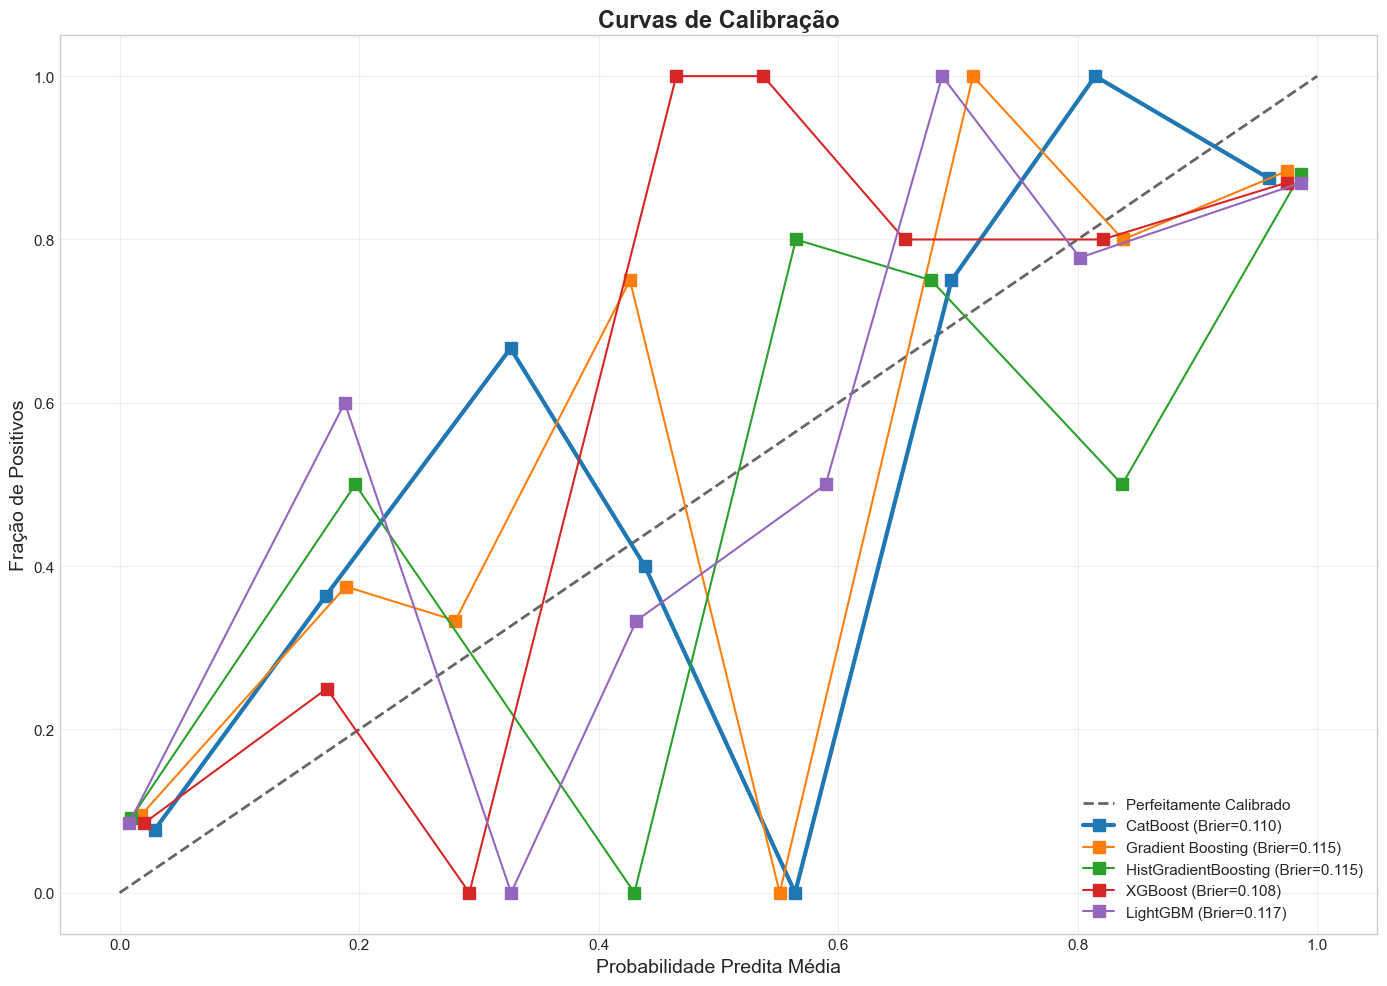

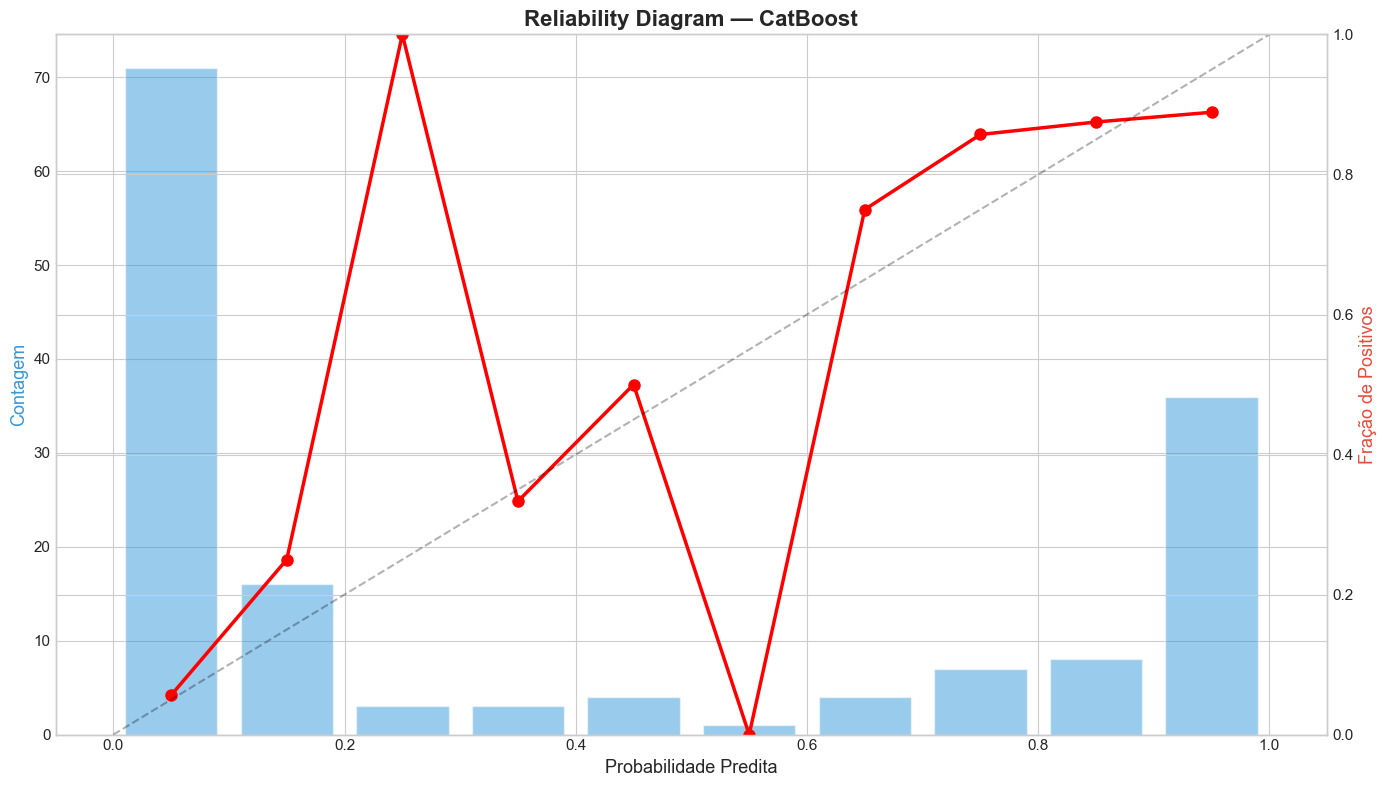

In [30]:
# ===== GRÁFICO 10: Calibration Curves =====
print("=" * 70)
print("📊 CALIBRAÇÃO DOS MODELOS")
print("=" * 70)

# --- Calibration curves ---
fig, ax1 = plt.subplots(figsize=(14, 10))
ax1.plot([0, 1], [0, 1], 'k--', label='Perfeitamente Calibrado', alpha=0.6, linewidth=2)

for idx, name in enumerate(top5):
    proba = probas[name]
    try:
        prob_true, prob_pred = calibration_curve(y_test, proba, n_bins=8, strategy='uniform')
        brier = brier_score_loss(y_test, proba)
        ax1.plot(prob_pred, prob_true, 's-', label=f'{name} (Brier={brier:.3f})',
                linewidth=3 if name == best_model_name else 1.5, 
                markersize=8, color=cmap(idx))
    except:
        pass

ax1.set_xlabel('Probabilidade Predita Média', fontsize=14)
ax1.set_ylabel('Fração de Positivos', fontsize=14)
ax1.set_title('Curvas de Calibração', fontweight='bold', fontsize=17)
ax1.legend(fontsize=11, loc='lower right')
ax1.grid(True, alpha=0.3)
ax1.tick_params(labelsize=11)
plt.tight_layout()
plt.show()

# --- Reliability diagram ---
fig, ax2 = plt.subplots(figsize=(14, 8))
proba = probas[best_model_name]
bins = np.linspace(0, 1, 11)
bin_indices = np.digitize(proba, bins) - 1
bin_indices = np.clip(bin_indices, 0, len(bins) - 2)

bin_counts = []
bin_acc = []
for i in range(len(bins) - 1):
    mask = bin_indices == i
    count = mask.sum()
    bin_counts.append(count)
    if count > 0:
        bin_acc.append(y_test.values[mask].mean())
    else:
        bin_acc.append(0)

bin_centers = (bins[:-1] + bins[1:]) / 2
ax2_twin = ax2.twinx()

ax2.bar(bin_centers, bin_counts, width=0.08, alpha=0.5, color=COLORS['secondary'], 
        label='Amostras por bin', edgecolor='white')
ax2.set_ylabel('Contagem', color=COLORS['secondary'], fontsize=13)
ax2.tick_params(labelsize=11)

ax2_twin.plot(bin_centers, bin_acc, 'ro-', linewidth=2.5, markersize=8, label='Fração Positivos')
ax2_twin.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax2_twin.set_ylabel('Fração de Positivos', color=COLORS['danger'], fontsize=13)
ax2_twin.set_ylim(0, 1)
ax2_twin.tick_params(labelsize=11)

ax2.set_xlabel('Probabilidade Predita', fontsize=13)
ax2.set_title(f'Reliability Diagram — {best_model_name}', fontweight='bold', fontsize=16)

plt.tight_layout()
plt.savefig(ARTIFACTS_PATH / 'calibration_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

🔍 ANÁLISE DE ERROS DO MELHOR MODELO


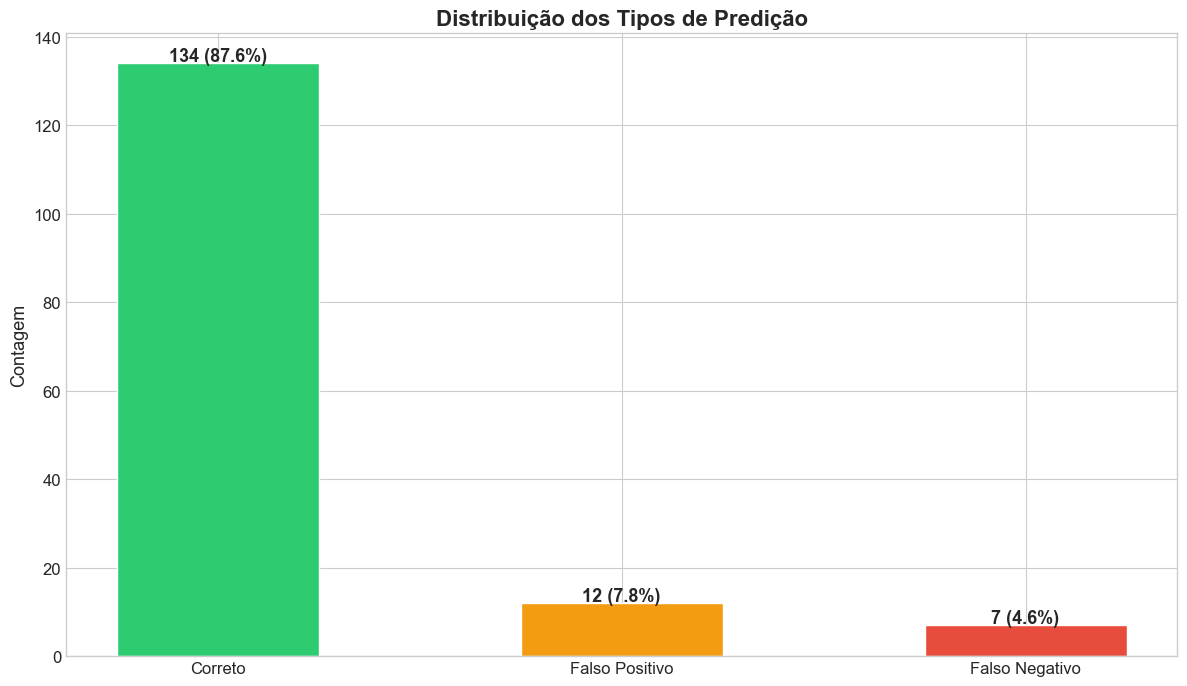

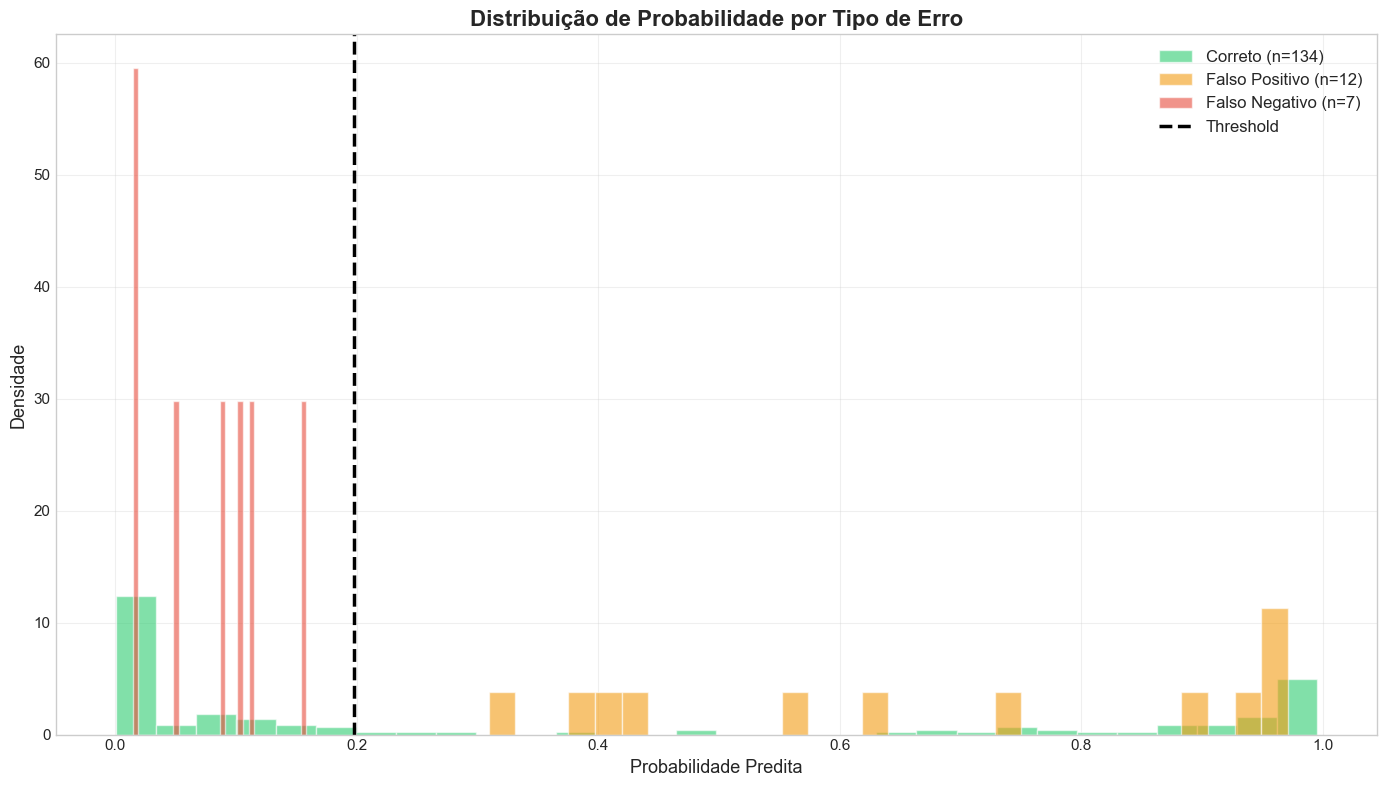

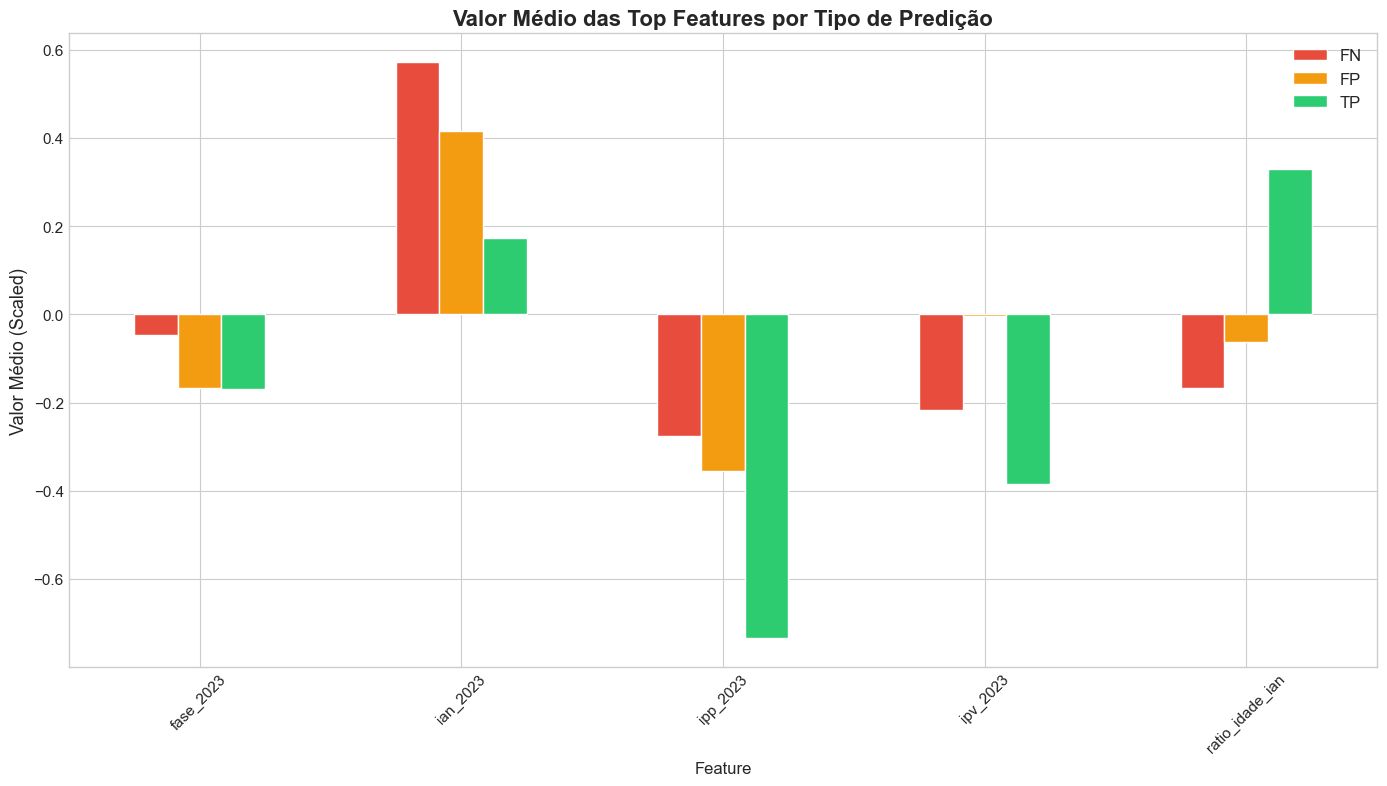

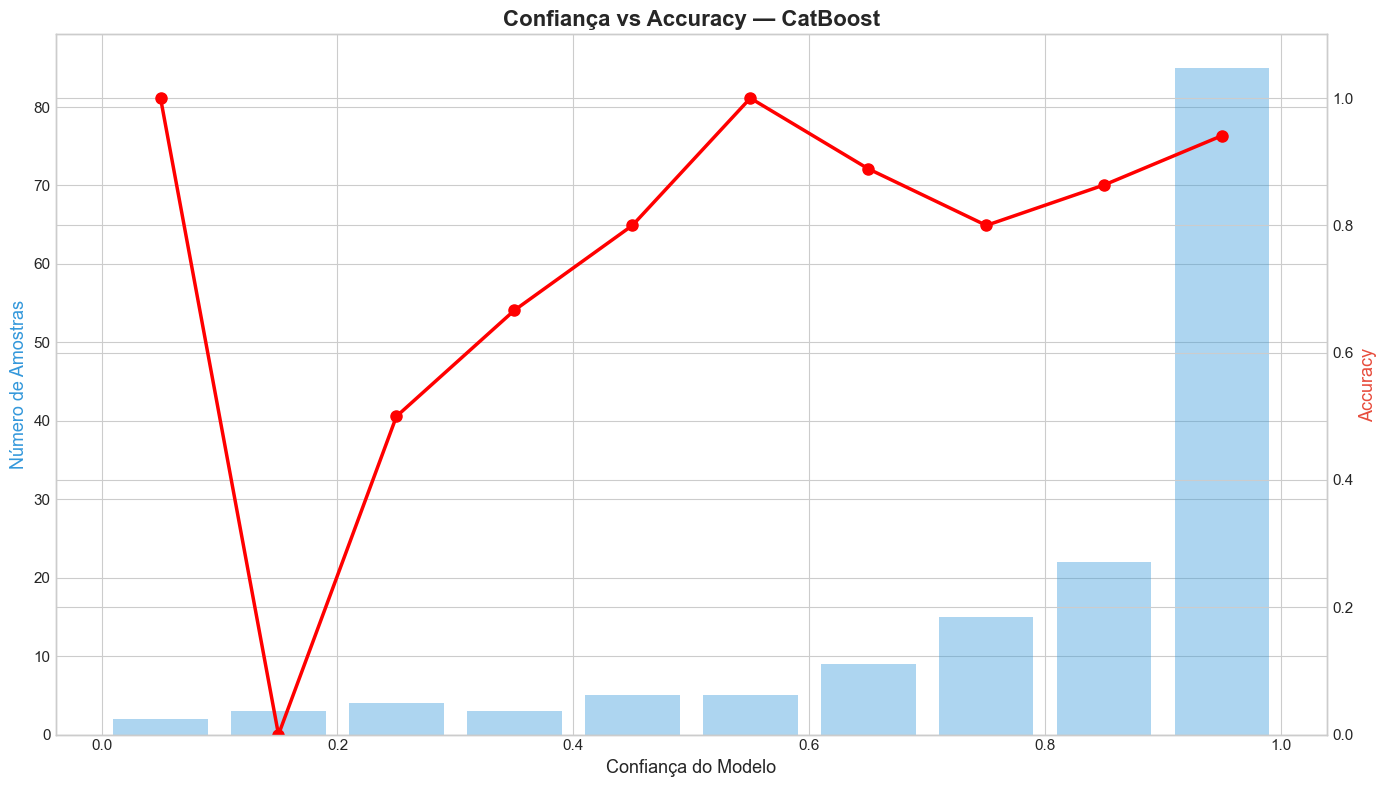

In [31]:
# ===== GRÁFICO 11: Análise de Erros =====
print("=" * 70)
print("🔍 ANÁLISE DE ERROS DO MELHOR MODELO")
print("=" * 70)

y_pred_final = (best_proba >= best_threshold).astype(int)

error_types = pd.Series('Correto', index=y_test.index)
error_types[(y_test == 0) & (y_pred_final == 1)] = 'Falso Positivo'
error_types[(y_test == 1) & (y_pred_final == 0)] = 'Falso Negativo'

colors_err = {'Correto': COLORS['success'], 'Falso Positivo': COLORS['warning'], 
              'Falso Negativo': COLORS['danger']}

# --- 11.1 Distribuição dos tipos de erro ---
fig, ax1 = plt.subplots(figsize=(12, 7))
error_counts = error_types.value_counts()
bars = ax1.bar(error_counts.index, error_counts.values, 
               color=[colors_err.get(x, 'gray') for x in error_counts.index],
               edgecolor='white', width=0.5)
for bar, count in zip(bars, error_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
             f'{count} ({count/len(y_test)*100:.1f}%)', ha='center', fontweight='bold', fontsize=13)
ax1.set_title('Distribuição dos Tipos de Predição', fontweight='bold', fontsize=16)
ax1.set_ylabel('Contagem', fontsize=13)
ax1.tick_params(labelsize=12)
plt.tight_layout()
plt.show()

# --- 11.2 Probabilidade por tipo de erro ---
fig, ax2 = plt.subplots(figsize=(14, 8))
for etype, color in colors_err.items():
    mask = error_types == etype
    if mask.sum() > 0:
        ax2.hist(best_proba[mask], bins=30, alpha=0.6, color=color, 
                label=f'{etype} (n={mask.sum()})', density=True, edgecolor='white')
ax2.axvline(x=best_threshold, color='black', linestyle='--', linewidth=2.5, label='Threshold')
ax2.set_title('Distribuição de Probabilidade por Tipo de Erro', fontweight='bold', fontsize=16)
ax2.set_xlabel('Probabilidade Predita', fontsize=13)
ax2.set_ylabel('Densidade', fontsize=13)
ax2.legend(fontsize=12)
ax2.tick_params(labelsize=11)
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- 11.3 Features dos FN vs FP (top features) ---
fig, ax3 = plt.subplots(figsize=(14, 8))
if hasattr(best_model, 'feature_importances_'):
    top5_feats = pd.Series(best_model.feature_importances_, index=X_train.columns).nlargest(5).index.tolist()
else:
    top5_feats = abs_corr.head(5).index.tolist()

fn_mask = (y_test == 1) & (y_pred_final == 0)
fp_mask = (y_test == 0) & (y_pred_final == 1)
tp_mask = (y_test == 1) & (y_pred_final == 1)

comparison_data = []
for feat in top5_feats[:5]:
    if feat in X_test.columns:
        for label, mask in [('TP', tp_mask), ('FN', fn_mask), ('FP', fp_mask)]:
            if mask.sum() > 0:
                comparison_data.append({
                    'Feature': feat, 'Type': label,
                    'Mean': X_test.loc[mask, feat].mean()
                })

if comparison_data:
    comp_df = pd.DataFrame(comparison_data)
    comp_pivot = comp_df.pivot(index='Feature', columns='Type', values='Mean')
    comp_pivot.plot(kind='bar', ax=ax3, color=[COLORS['danger'], COLORS['warning'], COLORS['success']],
                   edgecolor='white')
    ax3.set_title('Valor Médio das Top Features por Tipo de Predição', fontweight='bold', fontsize=16)
    ax3.set_ylabel('Valor Médio (Scaled)', fontsize=13)
    ax3.tick_params(axis='x', rotation=45, labelsize=11)
    ax3.tick_params(axis='y', labelsize=11)
    ax3.legend(fontsize=12)
plt.tight_layout()
plt.show()

# --- 11.4 Confidence vs Accuracy ---
fig, ax4 = plt.subplots(figsize=(14, 8))
confidence = np.abs(best_proba - 0.5) * 2
n_bins_conf = 10
bins_conf = np.linspace(0, 1, n_bins_conf + 1)
bin_idx = np.digitize(confidence, bins_conf) - 1
bin_idx = np.clip(bin_idx, 0, n_bins_conf - 1)

correct = (y_pred_final == y_test).astype(int)
conf_acc = []
conf_count = []
for i in range(n_bins_conf):
    mask = bin_idx == i
    if mask.sum() > 0:
        conf_acc.append(correct[mask].mean())
        conf_count.append(mask.sum())
    else:
        conf_acc.append(0)
        conf_count.append(0)

bin_centers = (bins_conf[:-1] + bins_conf[1:]) / 2
ax4.bar(bin_centers, conf_count, width=0.08, alpha=0.4, color=COLORS['secondary'], label='Amostras')
ax4_twin = ax4.twinx()
ax4_twin.plot(bin_centers, conf_acc, 'ro-', linewidth=2.5, markersize=8, label='Accuracy')
ax4.set_xlabel('Confiança do Modelo', fontsize=13)
ax4.set_ylabel('Número de Amostras', color=COLORS['secondary'], fontsize=13)
ax4_twin.set_ylabel('Accuracy', color=COLORS['danger'], fontsize=13)
ax4_twin.set_ylim(0, 1.1)
ax4.set_title(f'Confiança vs Accuracy — {best_model_name}', fontweight='bold', fontsize=16)
ax4.tick_params(labelsize=11)
ax4_twin.tick_params(labelsize=11)

plt.tight_layout()
plt.savefig(ARTIFACTS_PATH / 'error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

📊 CUMULATIVE GAINS E LIFT CHART


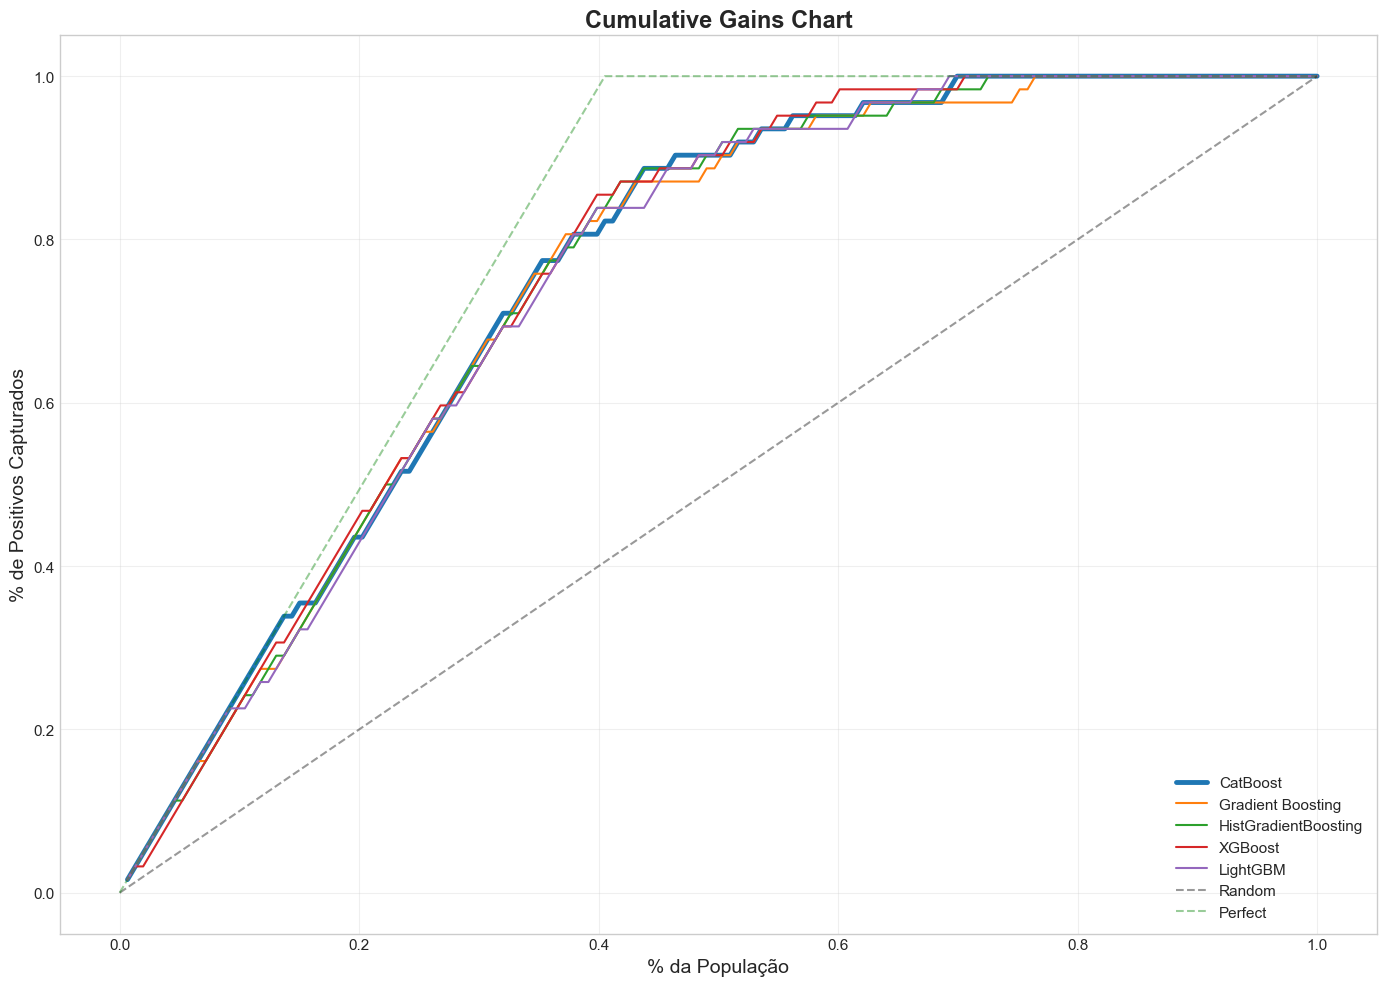

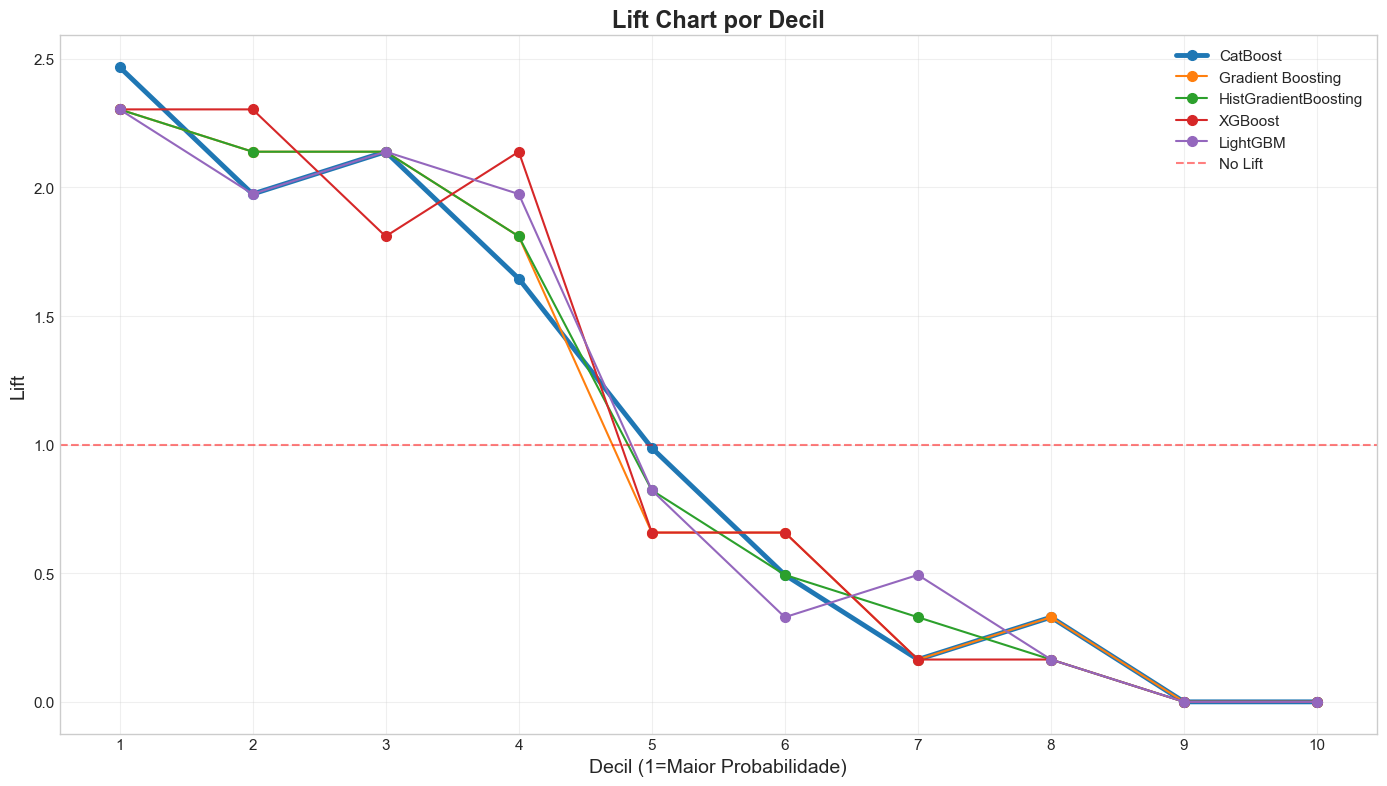

In [32]:
# ===== GRÁFICO 12: Cumulative Gains e Lift Charts =====
print("=" * 70)
print("📊 CUMULATIVE GAINS E LIFT CHART")
print("=" * 70)

# --- Cumulative Gains ---
fig, ax1 = plt.subplots(figsize=(14, 10))
for idx, name in enumerate(top5):
    proba = probas[name]
    sorted_indices = np.argsort(-proba)
    y_sorted = y_test.values[sorted_indices]
    
    cum_gains = np.cumsum(y_sorted) / y_sorted.sum()
    pct_population = np.arange(1, len(y_sorted) + 1) / len(y_sorted)
    
    lw = 3.5 if name == best_model_name else 1.5
    ax1.plot(pct_population, cum_gains, label=name, linewidth=lw, color=cmap(idx))

ax1.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random')
ax1.plot([0, y_test.mean(), 1], [0, 1, 1], 'g--', alpha=0.4, label='Perfect')
ax1.set_xlabel('% da População', fontsize=14)
ax1.set_ylabel('% de Positivos Capturados', fontsize=14)
ax1.set_title('Cumulative Gains Chart', fontweight='bold', fontsize=17)
ax1.legend(fontsize=11, loc='lower right')
ax1.grid(True, alpha=0.3)
ax1.tick_params(labelsize=11)
plt.tight_layout()
plt.show()

# --- Lift Chart ---
fig, ax2 = plt.subplots(figsize=(14, 8))
for idx, name in enumerate(top5):
    proba = probas[name]
    sorted_indices = np.argsort(-proba)
    y_sorted = y_test.values[sorted_indices]
    
    n = len(y_sorted)
    decile_size = n // 10
    lifts = []
    baseline_rate = y_test.mean()
    
    for d in range(10):
        start = d * decile_size
        end = start + decile_size if d < 9 else n
        decile_rate = y_sorted[start:end].mean()
        lifts.append(decile_rate / baseline_rate if baseline_rate > 0 else 0)
    
    lw = 3.5 if name == best_model_name else 1.5
    ax2.plot(range(1, 11), lifts, 'o-', label=name, linewidth=lw, color=cmap(idx), markersize=7)

ax2.axhline(y=1, color='red', linestyle='--', alpha=0.5, label='No Lift')
ax2.set_xlabel('Decil (1=Maior Probabilidade)', fontsize=14)
ax2.set_ylabel('Lift', fontsize=14)
ax2.set_title('Lift Chart por Decil', fontweight='bold', fontsize=17)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.set_xticks(range(1, 11))
ax2.tick_params(labelsize=11)

plt.tight_layout()
plt.savefig(ARTIFACTS_PATH / 'gains_lift_charts.png', dpi=150, bbox_inches='tight')
plt.show()

📊 ESTABILIDADE VIA CROSS-VALIDATION
   ⚠️ CatBoost: The following error was raised: 'CatBoostClassifier' object has no attribute '__sklearn_tags__'. It seems that there are no classes that implement `__sklearn_tags__` in the MRO and/or all classes in the MRO call `super().__sklearn_tags__()`. Make sure to inherit from `BaseEstimator` which implements `__sklearn_tags__` (or alternatively define `__sklearn_tags__` but we don't recommend this approach). Note that `BaseEstimator` needs to be on the right side of other Mixins in the inheritance order.


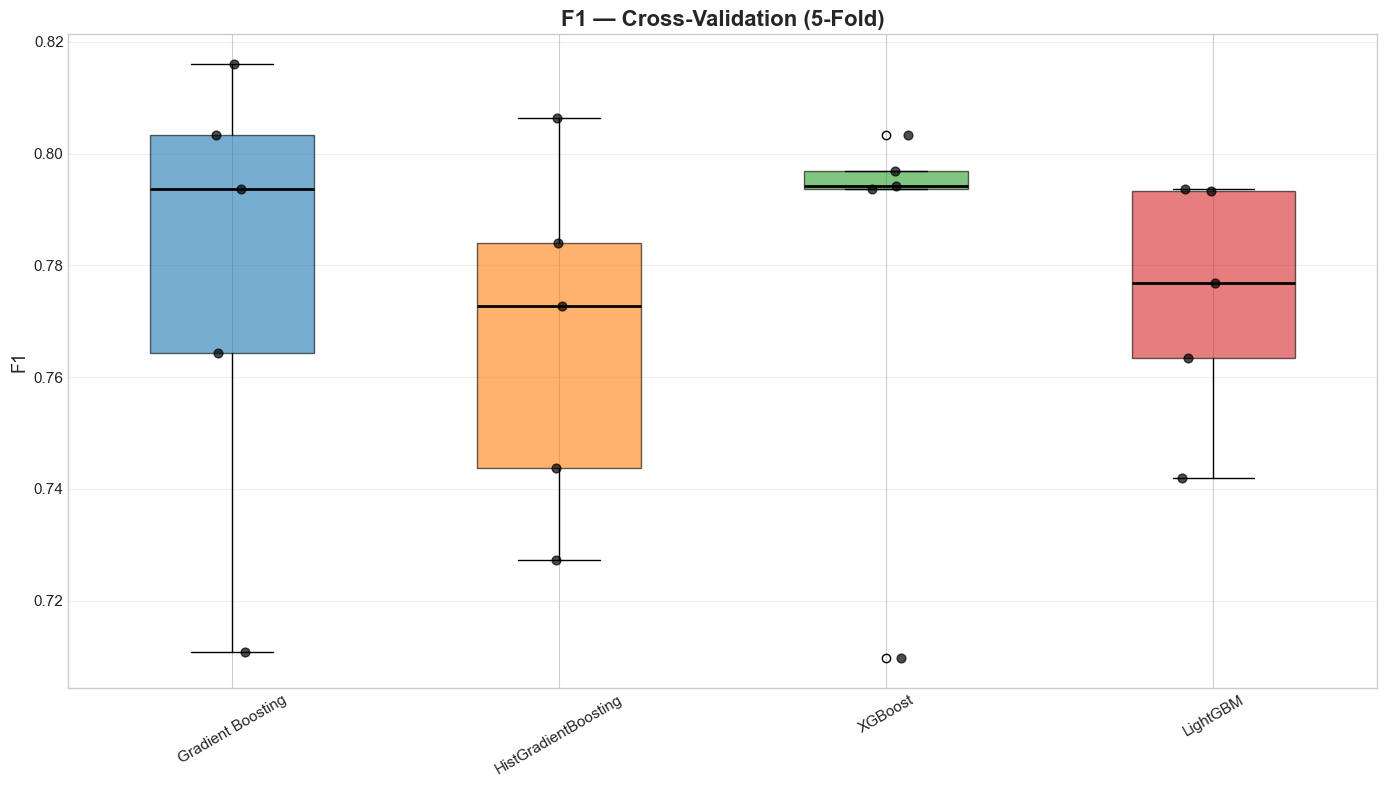

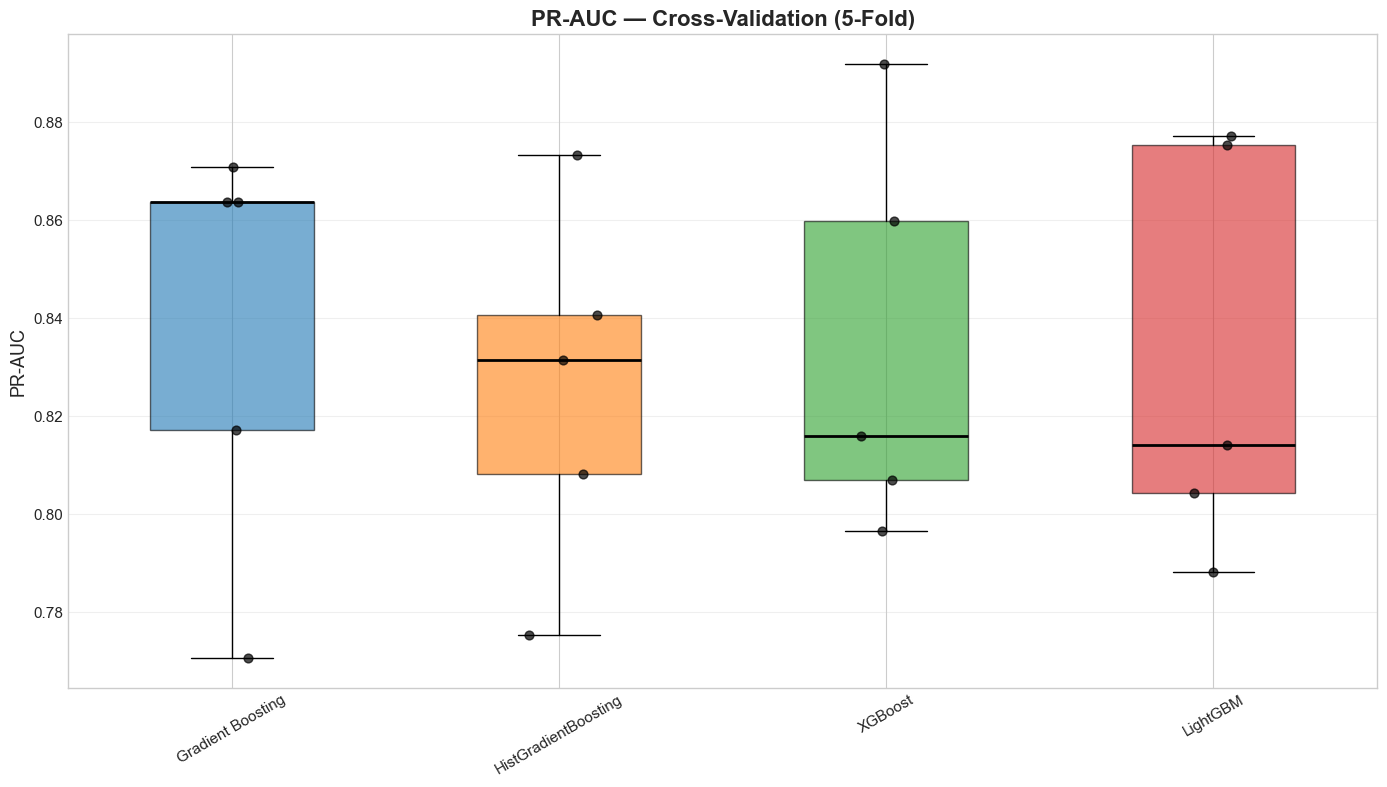

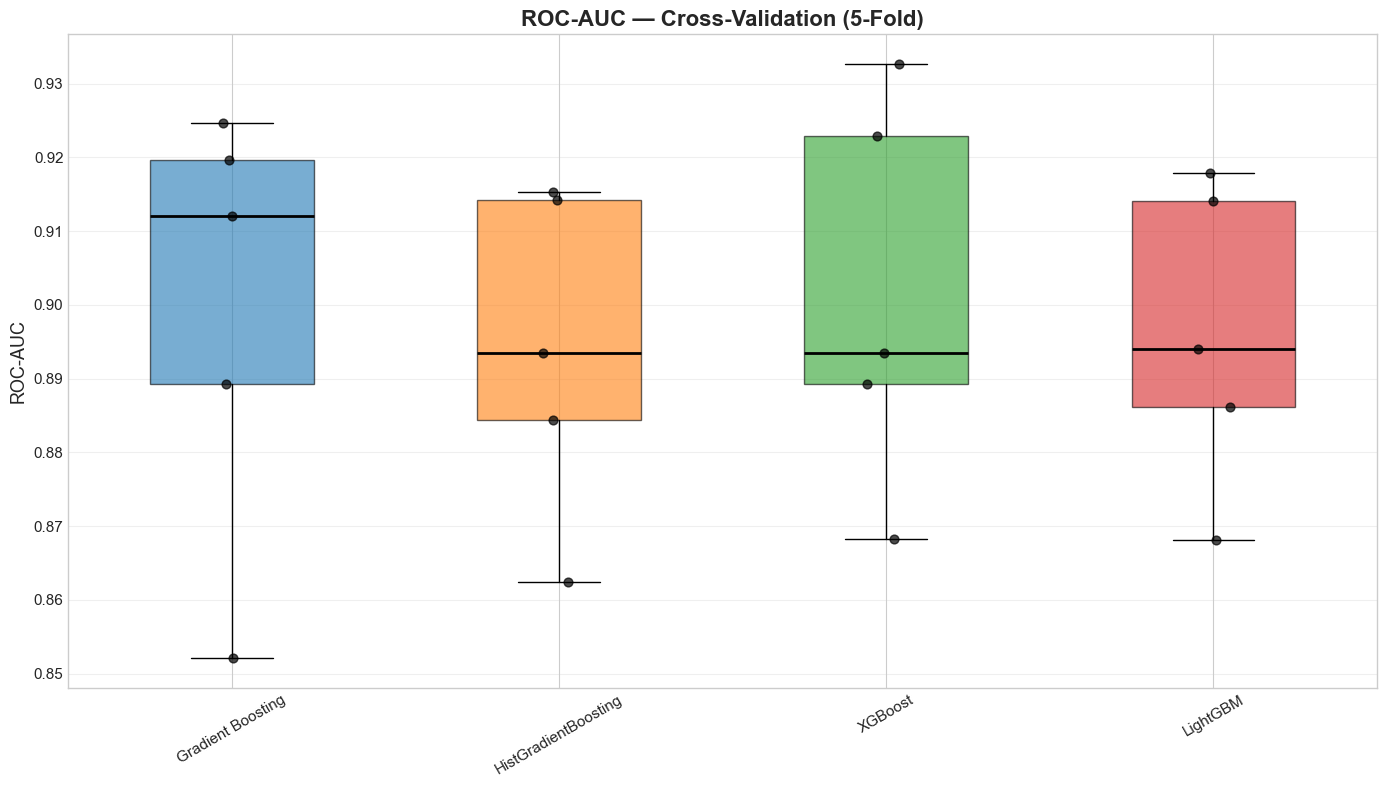

In [33]:
# ===== GRÁFICO 13: Análise de Estabilidade (CV Boxplots) =====
print("=" * 70)
print("📊 ESTABILIDADE VIA CROSS-VALIDATION")
print("=" * 70)

from sklearn.base import clone

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_detailed = {}

for name in top5:
    model = trained_models[name]
    try:
        model_fresh = clone(model)
        scores = cross_validate(
            model_fresh, X_scaled, y, cv=cv,
            scoring=['f1', 'average_precision', 'roc_auc'],
            n_jobs=-1
        )
        cv_detailed[name] = {
            'F1': scores['test_f1'],
            'PR-AUC': scores['test_average_precision'],
            'ROC-AUC': scores['test_roc_auc'],
        }
    except Exception as e:
        print(f"   ⚠️ {name}: {e}")

if cv_detailed:
    for metric in ['F1', 'PR-AUC', 'ROC-AUC']:
        fig, ax = plt.subplots(figsize=(14, 8))
        data_boxes = []
        labels_boxes = []
        for name in cv_detailed:
            if metric in cv_detailed[name]:
                data_boxes.append(cv_detailed[name][metric])
                labels_boxes.append(name)
        
        bp = ax.boxplot(data_boxes, labels=labels_boxes, patch_artist=True,
                       medianprops=dict(color='black', linewidth=2),
                       widths=0.5)
        
        colors_box = [cmap(i) for i in range(len(data_boxes))]
        for patch, color in zip(bp['boxes'], colors_box):
            patch.set_facecolor(color)
            patch.set_alpha(0.6)
        
        # Add individual fold points
        for i, data in enumerate(data_boxes):
            x_jitter = np.random.normal(i + 1, 0.04, size=len(data))
            ax.scatter(x_jitter, data, alpha=0.7, s=40, color='black', zorder=5)
        
        ax.set_title(f'{metric} — Cross-Validation (5-Fold)', fontweight='bold', fontsize=16)
        ax.set_ylabel(metric, fontsize=13)
        ax.tick_params(axis='x', rotation=30, labelsize=11)
        ax.tick_params(axis='y', labelsize=11)
        ax.grid(True, alpha=0.3, axis='y')
        plt.tight_layout()
        plt.savefig(ARTIFACTS_PATH / 'cv_stability.png', dpi=150, bbox_inches='tight')
        plt.show()

## 11. Conclusões e Recomendações <a id="11-conclusao"></a>

In [34]:
# ===== RESUMO FINAL =====
print("=" * 70)
print("📋 RESUMO FINAL E RECOMENDAÇÕES")
print("=" * 70)

print(f"""
╔══════════════════════════════════════════════════════════════════════╗
║                    RESULTADOS DO EXPERIMENTO                        ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  Dataset:           {df.shape[0]} amostras × {df.shape[1]} colunas {' '*25}║
║  Features originais: {len(FEATURE_COLS):<5}                                         ║
║  Features engenharia: {len(new_features):<5}                                        ║
║  Features totais:    {X.shape[1]:<5}                                         ║
║  Modelos treinados:  {len(results):<5}                                         ║
║                                                                      ║
║  🥇 MELHOR MODELO: {best_model_name:<40}       ║
║     PR-AUC:     {best['pr_auc']:.4f}                                        ║
║     ROC-AUC:    {best['roc_auc']:.4f}                                        ║
║     Best F1:    {best['best_f1']:.4f}                                        ║
║     Best F2:    {best['best_f2']:.4f}                                        ║
║     Precision:  {best['best_precision']:.4f}                                        ║
║     Recall:     {best['best_recall']:.4f}                                        ║
║     Threshold:  {best['best_threshold']:.4f}                                        ║
║     Brier:      {best['brier']:.4f}                                        ║
║                                                                      ║
╚══════════════════════════════════════════════════════════════════════╝
""")

# Ranking final
print("\n🏆 RANKING FINAL (Top 5):")
print("-" * 70)
for idx, row in results_df.head(5).iterrows():
    medal = ['🥇', '🥈', '🥉', '4️⃣', '5️⃣'][idx]
    print(f"{medal} {row['model']:<30} PR-AUC={row['pr_auc']:.4f}  F1*={row['best_f1']:.4f}  Recall*={row['best_recall']:.4f}")

print(f"""
\n📋 RECOMENDAÇÕES:

1. MODELO: Adotar {best_model_name} como modelo principal
2. THRESHOLD: Usar {best['best_threshold']:.4f} (otimizado para F1)
3. MONITORAMENTO: Acompanhar PR-AUC e recall em produção
4. RETREINO: Reavaliar trimestralmente com novos dados
5. FEATURES: As features de indicadores são as mais discriminativas
6. BALANCEAMENTO: Se recall precisa ser > {best['best_recall']:.2f}, considerar
   ajustar threshold ou aplicar SMOTE no treino
""")

📋 RESUMO FINAL E RECOMENDAÇÕES

╔══════════════════════════════════════════════════════════════════════╗
║                    RESULTADOS DO EXPERIMENTO                        ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  Dataset:           765 amostras × 21 colunas                          ║
║  Features originais: 19                                            ║
║  Features engenharia: 50                                           ║
║  Features totais:    69                                            ║
║  Modelos treinados:  11                                            ║
║                                                                      ║
║  🥇 MELHOR MODELO: CatBoost                                       ║
║     PR-AUC:     0.8949                                        ║
║     ROC-AUC:    0.9277                                        ║
║     Best F1:    0.8527                    

In [35]:
# Salvar artefatos finais
output = {
    'experiment_date': datetime.now().isoformat(),
    'notebook': '03_end_to_end_analysis',
    'dataset_shape': list(df.shape),
    'n_features_original': len(FEATURE_COLS),
    'n_features_engineered': len(new_features),
    'n_features_total': X.shape[1],
    'n_models_trained': len(results),
    'train_size': len(X_train),
    'test_size': len(X_test),
    'best_model': best['model'],
    'best_metrics': {
        'pr_auc': float(best['pr_auc']),
        'roc_auc': float(best['roc_auc']),
        'best_f1': float(best['best_f1']),
        'best_f2': float(best['best_f2']),
        'best_precision': float(best['best_precision']),
        'best_recall': float(best['best_recall']),
        'best_threshold': float(best['best_threshold']),
        'brier': float(best['brier']),
        'log_loss': float(best['log_loss']),
    },
    'all_results': results_df.to_dict('records'),
    'cross_validation': {k: {m: f"{v.mean():.4f}±{v.std():.4f}" 
                              for m, v in vals.items() if isinstance(v, np.ndarray)} 
                         for k, vals in cv_detailed.items()} if cv_detailed else {},
    'plots_generated': [
        'performance_dashboard.png',
        'pr_roc_curves.png',
        'confusion_matrices.png',
        'probability_distributions.png',
        'detailed_metrics_comparison.png',
        'learning_curves.png',
        'det_threshold_analysis.png',
        'feature_importance.png',
        'calibration_analysis.png',
        'error_analysis.png',
        'gains_lift_charts.png',
        'cv_stability.png',
    ]
}

output_path = ARTIFACTS_PATH / 'end_to_end_results.json'
with open(output_path, 'w') as f:
    json.dump(output, f, indent=2, default=str)

print(f"✅ Resultados salvos em: {output_path}")
print(f"\n📁 Gráficos gerados em: {ARTIFACTS_PATH}/")
for plot in output['plots_generated']:
    print(f"   📊 {plot}")

✅ Resultados salvos em: c:\Users\argus\workspace\datathonfiap\artifacts\end_to_end_results.json

📁 Gráficos gerados em: c:\Users\argus\workspace\datathonfiap\artifacts/
   📊 performance_dashboard.png
   📊 pr_roc_curves.png
   📊 confusion_matrices.png
   📊 probability_distributions.png
   📊 detailed_metrics_comparison.png
   📊 learning_curves.png
   📊 det_threshold_analysis.png
   📊 feature_importance.png
   📊 calibration_analysis.png
   📊 error_analysis.png
   📊 gains_lift_charts.png
   📊 cv_stability.png


In [36]:
print("\n" + "=" * 70)
print("🎉 NOTEBOOK END-TO-END CONCLUÍDO COM SUCESSO!")
print("=" * 70)
print(f"""
📊 Seções completadas:
   ✅ Análise do dataset e visão geral
   ✅ Análise exploratória completa (EDA)
   ✅ Análise de correlações e multicolinearidade
   ✅ Feature engineering avançada
   ✅ Treinamento de {len(results)} modelos
   ✅ Cross-validation e métricas detalhadas
   ✅ 12+ gráficos de performance
   ✅ Análise de feature importance + SHAP
   ✅ Análise de erros e calibração
   ✅ Cumulative gains e lift charts
   ✅ Análise de estabilidade (CV)
   ✅ Artefatos salvos em JSON
""")


🎉 NOTEBOOK END-TO-END CONCLUÍDO COM SUCESSO!

📊 Seções completadas:
   ✅ Análise do dataset e visão geral
   ✅ Análise exploratória completa (EDA)
   ✅ Análise de correlações e multicolinearidade
   ✅ Feature engineering avançada
   ✅ Treinamento de 11 modelos
   ✅ Cross-validation e métricas detalhadas
   ✅ 12+ gráficos de performance
   ✅ Análise de feature importance + SHAP
   ✅ Análise de erros e calibração
   ✅ Cumulative gains e lift charts
   ✅ Análise de estabilidade (CV)
   ✅ Artefatos salvos em JSON

